In [1]:
import os
import glob
import torch
torch.set_default_dtype(torch.double)

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision  
import matplotlib.pyplot as plt
from tqdm import tqdm

# diffeomorphisms
from src.diffeomorphisms.composition.image import ImageCompositionDiffeomorphism
from src.diffeomorphisms.image.product_starflow import ProductStarFlowImageDiffeomorphism
from src.diffeomorphisms.image.to_vec import ToVecImageDiffeomorphism 
from src.diffeomorphisms.image.transform import TransformImageDiffeomorphism
from src.diffeomorphisms.vector.to_img import ToImgVectorDiffeomorphism

# dimension reduction
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver  

# distributions
from src.distributions.star_gaussians.multi_inverse_linear_norm_gaussian import MultiInverseLinearStarNormGaussianDistribution
from src.distributions.starflows.products.diagonal import StarDiagonalFlowDistribution

# embeddings
from src.embedding.hyperbolic_gromov_monge import HyperbolicGromovMongeEmbedding

# manifolds
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.manifolds.isometrized_euclidean.image import l2IsometrizedImageEuclidean

# training
from src.training.diffeomorphic_decoder import DiffeomorphicDecoderTraining
from src.training.hyperbolic_gromov_monge_embedding import HyperbolicGromovMongeEmbeddingTraining
from src.training.latent_star_gaussian import LatentStarGaussianTraining
from src.training.product_starflow import ProductStarFlowTraining

# transforms
from nflows import transforms
from nflows.transforms.normalization import ActNorm
from src.transforms.image.parity_conv.linear_2d import Linear2DParityConvImageTransform
from src.transforms.image.parity_conv.simple_tanh_2d import SimpleTanh2DParityConvImageTransform
from src.transforms.image.to_vec import ToVecImageTransform
from src.transforms.vector.linear.structured_block_lower_triangular import StructuredBlockLowerTriangularVectorTransform

from config_loader import load_experiment_config 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# fix seed
torch.manual_seed(31)

# ---- load YAML config ----
CONFIG_PATH = "configs/mnist/four_phases.yaml"
EXPERIMENT_NAME = "mnist_16"       # change this to 'mnist_16', etc.

cfg = load_experiment_config(CONFIG_PATH, EXPERIMENT_NAME)

data_cfg = cfg["data"]
model_cfg = cfg["model"]
phase_1_cfg = cfg["phase_1"]
phase_2_cfg = cfg["phase_2"]
phase_3_cfg = cfg["phase_3"]
phase_4_cfg = cfg["phase_4"]

latent_dim = model_cfg["latent_dim"]
size = data_cfg["size"]
batch_size = data_cfg["batch_size"]

phase_1_training = phase_1_cfg["enabled"]
phase_2_training = phase_2_cfg["enabled"]
phase_3_training = phase_3_cfg["enabled"]
phase_4_training = phase_4_cfg["enabled"]

results_folder = os.path.join(
    cfg["base_results_dir"],
    f"{size}x{size}",
    f"latent_{latent_dim}",
)

os.makedirs(results_folder, exist_ok=True)

### Construct data set ###

In [2]:
H = W = size
mnist_mean = cfg["data"]["mnist_mean"]
mnist_var = cfg["data"]["mnist_var"]
train_val_split = cfg["data"]["train_val_split"]
sigma = cfg["data"]["sigma"]

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

full_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)

train_size = int(train_val_split * len(full_dataset))
val_size = len(full_dataset) - train_size
data_train, data_val = random_split(full_dataset, [train_size, val_size])


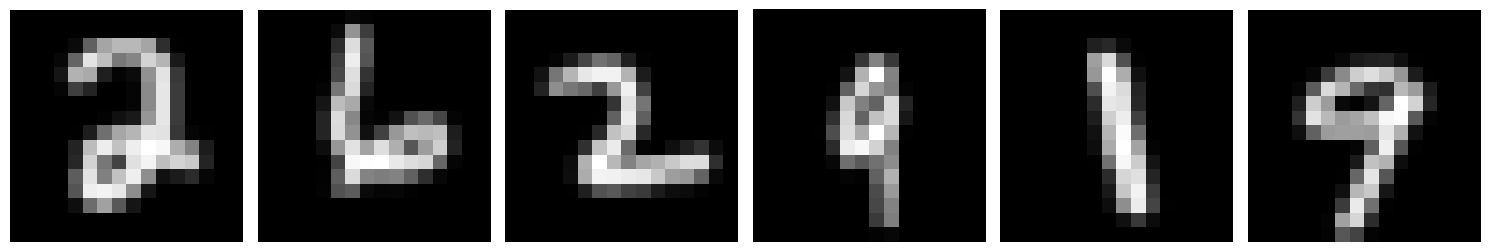

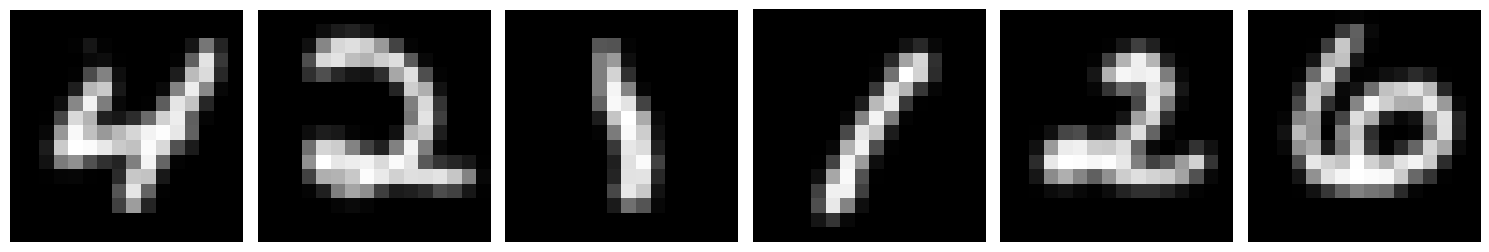

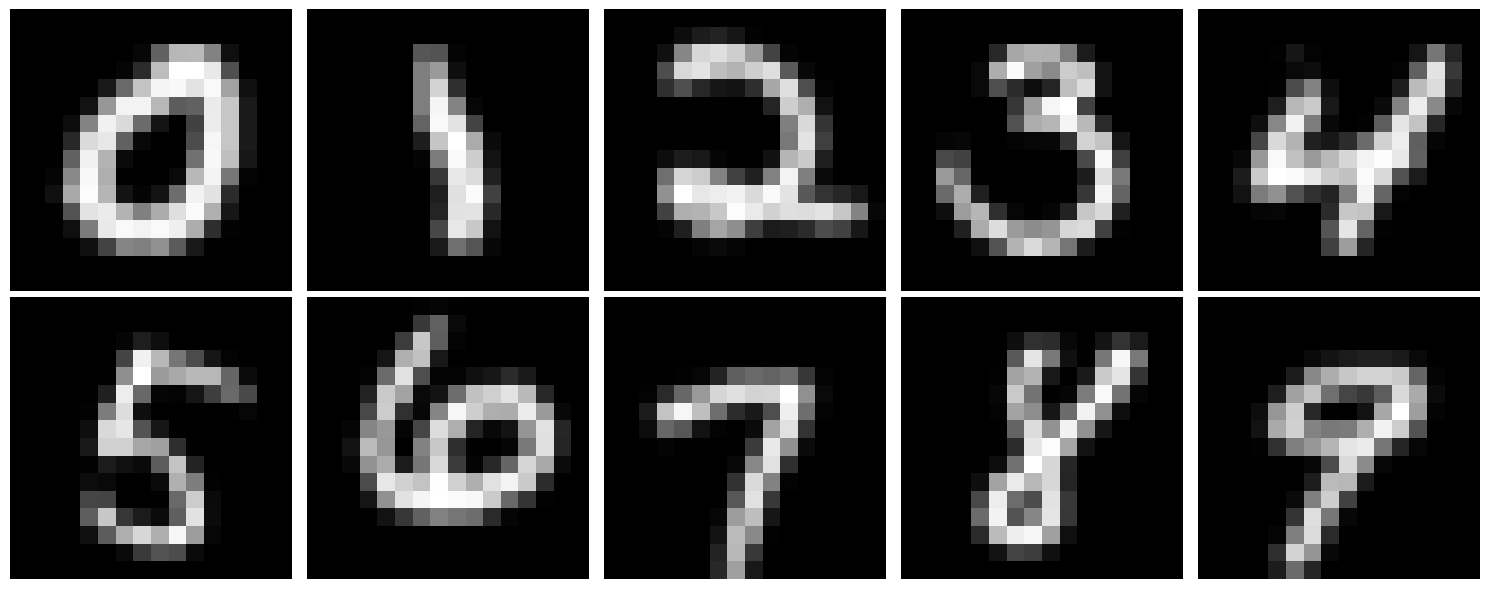

In [3]:
class RandomPairDataset(Dataset):
    def __init__(self, data):
        self.data = data            # shape: N x d
        self.N = data.__len__()

    def __len__(self):
        return self.N  # you can pick another value if you wish

    def __getitem__(self, idx):
        # x: deterministic sample (makes training deterministic per epoch)
        x, y = self.data[idx]
        # x_prime: random sample, different from idx
        idx2 = torch.randint(0, self.N - 1, (1,)).item()
        if idx2 >= idx:
            idx2 += 1
        x_prime, y_prime = self.data[idx2]
        return (x, y), (x_prime, y_prime)
    
# create dataset and dataloader
train_pair_dataset = RandomPairDataset(data_train)
train_loader = DataLoader(train_pair_dataset, batch_size=batch_size, shuffle=True)
val_pair_dataset = RandomPairDataset(data_val)
val_loader = DataLoader(val_pair_dataset, batch_size=batch_size, shuffle=False)

# Get a batch of examples from the training set
train_examples, train_examples_prime = next(iter(train_loader))
train_images, train_labels = train_examples
train_images_prime, train_labels_prime = train_examples_prime
val_examples, val_examples_prime = next(iter(val_loader))
val_images, val_labels = val_examples
val_images_prime, val_labels_prime = val_examples_prime

# construct data clusters as one digit per class
val_clusters = []
for digit in range(10):
    digit_indices = (val_labels == digit).nonzero(as_tuple=True)[0]
    digit_images = val_images[digit_indices][0]
    val_clusters.append(digit_images.unsqueeze(0))

cluster_images = torch.cat(val_clusters, dim=0)
cluster_labels = torch.arange(10)

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(15, 6))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(train_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(15, 6))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(val_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# plot cluster images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(cluster_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Stage 1: Learn an Embedding ###

In [4]:
# construct Gromov-Monge Embedding in Hyperbolic Space
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.block(x))

class ResidualCNN(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # size/2
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            ResidualBlock(64),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # size/4
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            ResidualBlock(128),
        )
        self.fc1 = nn.Linear(128, 512)
        self.fc2 = nn.Linear(512, latent_dim)

    def forward(self, x):
        # x: [B, 1, H, W] with arbitrary H=W=size
        x = self.conv(x)              # [B, 128, H', W']
        x = x.mean(dim=(2, 3))        # global average pooling -> [B, 128]
        x = F.relu(self.fc1(x))       # [B, 512]
        z = self.fc2(x)               # [B, latent_dim]
        return z
        
class ResidualCNNHyperbolicGromovMongeEmbedding(HyperbolicGromovMongeEmbedding):
    def __init__(self, output_dim):
        nn_model = ResidualCNN(output_dim)
        super().__init__(nn_model, output_dim=output_dim)

# instantiate the neural network
input_dim = size
hidden_dim = phase_1_cfg["hidden_dim"]          

hgme_trainer = HyperbolicGromovMongeEmbeddingTraining(
    ResidualCNNHyperbolicGromovMongeEmbedding(latent_dim).to(device),
    reg_param=phase_1_cfg["reg_param"],
    lr=phase_1_cfg["learning_rate"],
)

In [5]:
# construct train loop
def phase_1_train(trainer, train_loader, save_dir, n_epochs, start_epoch=0, best_loss=float('inf')):
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        for (x, _), (x_prime, _) in tqdm(train_loader):
            x = x.to(device, non_blocking=True)
            x_prime = x_prime.to(device, non_blocking=True)
            loss = trainer.train_step(x, x_prime)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(train_pair_dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': trainer.emb.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_loss,
        }
        
        
        torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [6]:
# train or load model for phase 1
phase_1_extension = f"lr_{phase_1_cfg['learning_rate']}_reg_{phase_1_cfg['reg_param']}_hidden_{phase_1_cfg['hidden_dim']}"
checkpoint_dir = os.path.join(results_folder, phase_1_cfg["checkpoint_subdir"], phase_1_extension)
os.makedirs(checkpoint_dir, exist_ok=True)

if phase_1_training:
    start_epoch = 0
    best_loss = float('inf')
    latest_checkpoint = max(
        glob.glob(os.path.join(checkpoint_dir, "epoch_*_model.pth")),
        default=None,
        key=os.path.getctime,
    )

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        hgme_trainer.emb.load_state_dict(checkpoint["model_state_dict"])
        hgme_trainer.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        best_loss = checkpoint["best_loss"]

    phase_1_train(
        hgme_trainer,
        train_loader,
        save_dir=checkpoint_dir,
        n_epochs=phase_1_cfg["num_epochs"],
        start_epoch=start_epoch,
        best_loss=best_loss,
    )
else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    checkpoint = torch.load(best_model_path, map_location=device)
    hgme_trainer.emb.load_state_dict(checkpoint["model_state_dict"])

emb = hgme_trainer.emb


Resuming training from results/mnist/four_phases/16x16/latent_20/checkpoints_phase_1/lr_0.001_reg_0.01_hidden_20/epoch_10_model.pth
Training completed. Best model saved with loss: 0.03756640722279373


/tmp/ipykernel_61314/2911290201.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(latest_checkpoint)


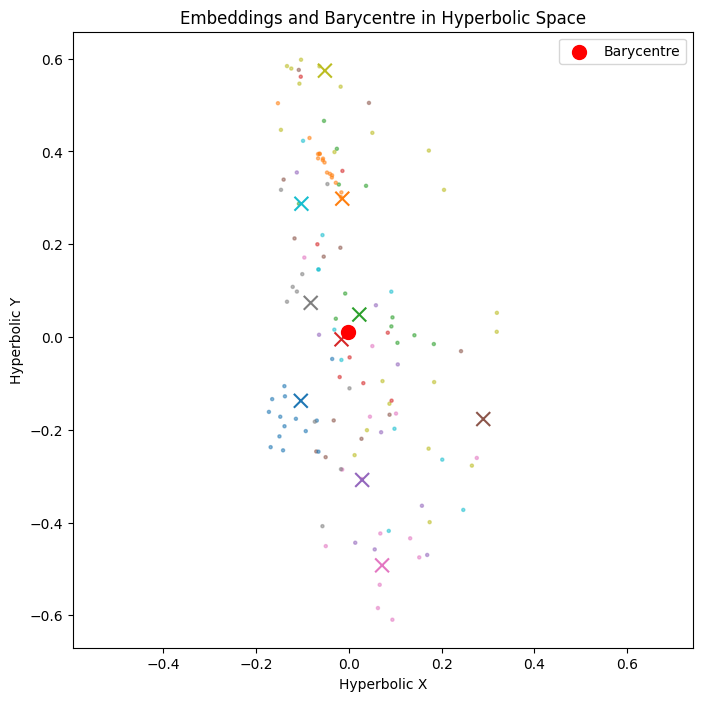

In [7]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    train_embeddings = emb(train_images.to(device)).cpu()
    cluster_embeddings = emb(cluster_images.to(device)).cpu()
    barycentre = emb.barycentre(train_images.to(device), max_iter=500, step_size=0.1).cpu()

plt.figure(figsize=(8, 8))
plt.scatter(train_embeddings[:, 0], train_embeddings[:, 1], c=train_labels, s=5, alpha=0.5, cmap='tab10')
plt.scatter(cluster_embeddings[:, 0], cluster_embeddings[:, 1], c=cluster_labels, marker='x', s=100, cmap='tab10')
plt.scatter(barycentre[0].item(), barycentre[1].item(), color='red', marker='o', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.savefig(os.path.join(results_folder,"stage_1_emb_final.png"))
plt.show()  

In [8]:
# translate origin with isometr
# check that distances are preserved I: compute old distances
with torch.no_grad():
    dist_emb = emb.distance(cluster_images[1:].to(device), cluster_images[:-1].to(device))

# update origin
emb.set_origin(barycentre.to(device))
# emb.origin = None  # reset origin to default (0,0) - should give same distances as before since we are using isometries
# check that distances are preserved II: compute new distances
with torch.no_grad():
    dist_emb_centered = emb.distance(cluster_images[1:].to(device), cluster_images[:-1].to(device))

print("Pairwise distance matrix in embedding space between cluster centers:")
print((dist_emb - dist_emb_centered).abs().max())  # should be close to zero
assert torch.allclose(dist_emb, dist_emb_centered, atol=1e-6), "Distances are not preserved after centering!"

Pairwise distance matrix in embedding space between cluster centers:
tensor(2.3075e-12, device='cuda:0')


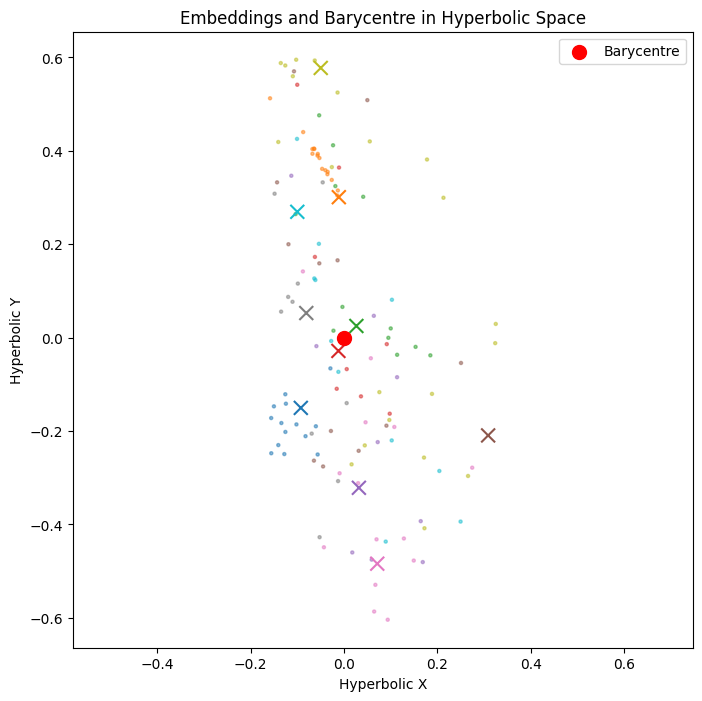

Distance between barycentres before and after centering:
8.735158612497724e-08


In [9]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    train_embeddings_centered = emb(train_images.to(device)).cpu()
    cluster_embeddings_centered = emb(cluster_images.to(device)).cpu()
    barycentre_centered = emb.barycentre(train_images.to(device), max_iter=500, step_size=0.1).cpu()

plt.figure(figsize=(8, 8))
plt.scatter(train_embeddings_centered[:, 0], train_embeddings_centered[:, 1], c=train_labels, s=5, alpha=0.5, cmap='tab10')
plt.scatter(cluster_embeddings_centered[:, 0], cluster_embeddings_centered[:, 1], c=cluster_labels, marker='x', s=100, cmap='tab10')
plt.scatter(barycentre_centered[0].item(), barycentre_centered[1].item(), color='red', marker='o', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.savefig(os.path.join(results_folder,"stage_1_emb_final_centered.png"))
plt.show()  

# check difference between barycentres
print("Distance between barycentres before and after centering:")
translated_barycentre = emb.translate(barycentre.to(device), barycentre.to(device)).cpu()
print((translated_barycentre - barycentre_centered).norm().item())  # should be close to zero

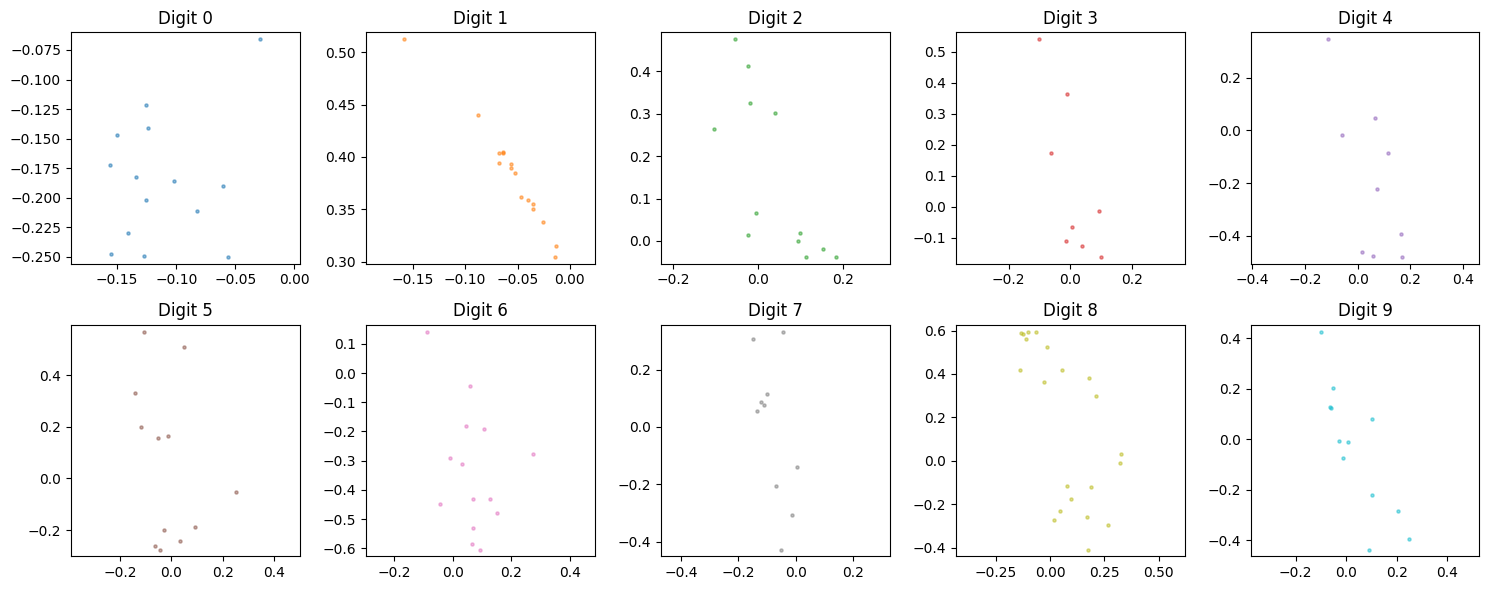

In [10]:
# make 10 plots for embeddings of each digit class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for digit in range(10):
    digit_indices = (train_labels == digit).nonzero(as_tuple=True)[0]
    digit_embeddings = train_embeddings_centered[digit_indices]
    axes[digit].scatter(digit_embeddings[:, 0], digit_embeddings[:, 1], s=5, alpha=0.5, color=f'C{digit}')
    axes[digit].set_title(f"Digit {digit}")
    axes[digit].axis('equal')
    # axes[digit].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_1_emb_final_centered_digits.png"))
plt.show()

### Stage 2: Learn an Embedding-informed Diffeomorphic Decoder ###

In [11]:
# construct normalizing flow model
class SimpleTransformImageDiffeomorphism(TransformImageDiffeomorphism):
    def __init__(self, in_channels, height, width, squeeze_factor, kernel_size, hidden_channels, latent_dim, n_flows):
        super(SimpleTransformImageDiffeomorphism, self).__init__(in_channels, height, width, self.create_transform(in_channels, height, width, squeeze_factor, kernel_size, hidden_channels, latent_dim, n_flows), vector_output=True)

    def create_transform(self, in_channels, height, width, squeeze_factor, kernel_size, hidden_channels, latent_dim, n_flows):
        transforms_list = []
        
        # optional squeeze transform to reduce spatial dimensions and increase channels
        if squeeze_factor > 1:
            squeeze = transforms.SqueezeTransform(factor=squeeze_factor)
            c_s, h_s, w_s = squeeze.get_output_shape(in_channels, height, width)
            transforms_list.append(squeeze)
        else: 
            c_s, h_s, w_s = in_channels, height, width

        # stack n_flows coupling layers with ActNorm in between, using parity to alternate which pixels are transformed
        for i in range(n_flows):
            transforms_list.append(ActNorm(features=c_s)) # OneByOneConvolution
            transforms_list.append(transforms.OneByOneConvolution(c_s))
            transforms_list.append(Linear2DParityConvImageTransform(c_s, h_s, w_s, kernel_size, parity=i))
            transforms_list.append(Linear2DParityConvImageTransform(c_s, h_s, w_s, kernel_size, parity=i+1))
            transforms_list.append(SimpleTanh2DParityConvImageTransform(c_s, h_s, w_s, hidden_channels=hidden_channels, kernel_size=kernel_size, parity=i))
        transforms_list.append(ActNorm(features=c_s))
        transforms_list.append(transforms.OneByOneConvolution(c_s))
        transforms_list.append(Linear2DParityConvImageTransform(c_s, h_s, w_s, kernel_size, parity=n_flows))
        transforms_list.append(Linear2DParityConvImageTransform(c_s, h_s, w_s, kernel_size, parity=n_flows+1))
        transforms_list.append(ToVecImageTransform(c_s, h_s, w_s))
        transforms_list.append(StructuredBlockLowerTriangularVectorTransform(c_s*h_s*w_s, latent_dim, bias=True, random_init=True, efficient_inverse=True))
        transform = transforms.CompositeTransform(transforms_list)
        return transform
    
# instantiate flow model
in_channels = phase_2_cfg["in_channels"]
height = size
width = size
squeeze_factor = phase_2_cfg["squeeze_factor"]
kernel_size = phase_2_cfg["kernel_size"]
hidden_channels = phase_2_cfg["hidden_channels"]
n_flows = phase_2_cfg["n_flows"]

diffeo_decoder_trainer = DiffeomorphicDecoderTraining(
    emb,
    SimpleTransformImageDiffeomorphism(
        in_channels,
        height,
        width,
        squeeze_factor,
        kernel_size,
        hidden_channels,
        latent_dim,
        n_flows,
    ).to(device),
    reg_param=phase_2_cfg["reg_param"],
    sigma=sigma,
    lr=phase_2_cfg["learning_rate"],
)

In [12]:
# construct train loop
def phase_2_train(trainer, train_loader, save_dir, n_epochs, start_epoch=0, best_loss=float('inf')):
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        for (x, _), _ in tqdm(train_loader):
            x = x.to(device, non_blocking=True)
            loss = trainer.train_step(x)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(train_pair_dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

        # TODO compute and plot reconstruction of the cluster images vs the originals in a 2 x 10 grid (one row for reconstructions, one row for originals, 10 columns for each digit class)
        rec_cluster_images = trainer.reconstruct(cluster_images.to(device)).cpu()
        fig, axes = plt.subplots(2, 10, figsize=(20, 4))
        axes = axes.flatten()
        for i in range(10):
            axes[i].imshow(cluster_images[i].squeeze(), cmap='gray')
            axes[i].axis('off')
            axes[i+10].imshow(rec_cluster_images[i].squeeze(), cmap='gray')
            axes[i+10].axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f'epoch_{epoch+1}_recon.png'))
        plt.show()

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': trainer.phi.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_loss,
        }
        
        torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

  0%|          | 0/375 [00:00<?, ?it/s]/home/wdiepeveen/projects/Lyme-Geometry/.venv/lib/python3.8/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at ../aten/src/ATen/native/BatchLinearAlgebra.cpp:2184.)
  outputs, _ = torch.triangular_solve(
100%|██████████| 375/375 [01:55<00:00,  3.26it/s]


Epoch 1/50, Loss: 0.286038


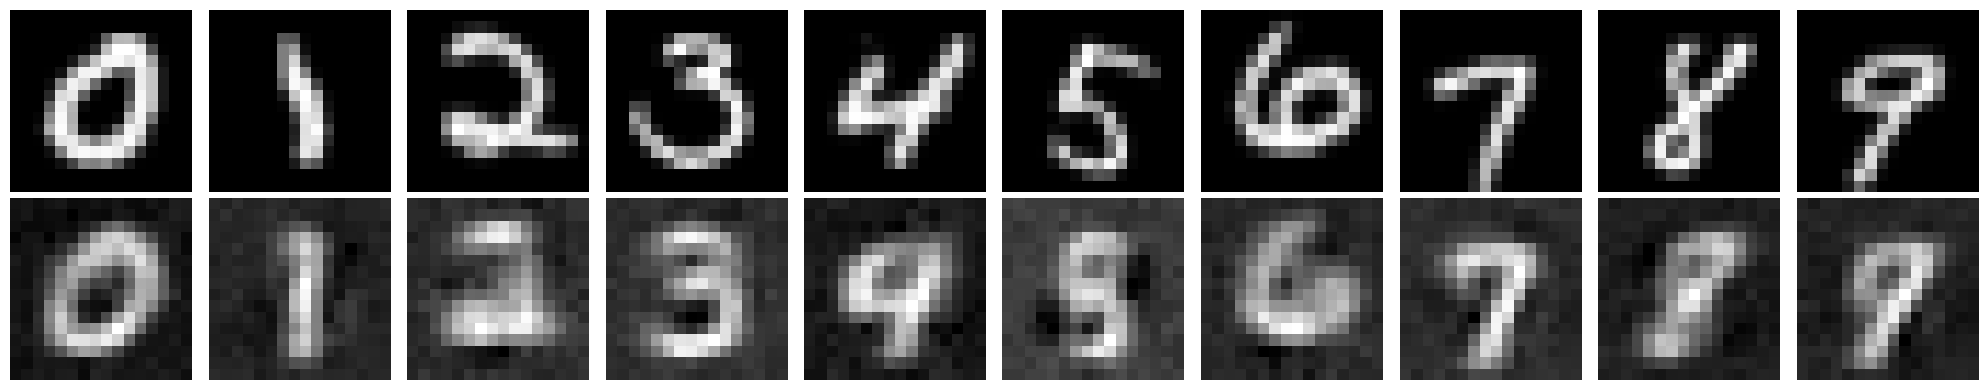

100%|██████████| 375/375 [01:52<00:00,  3.32it/s]


Epoch 2/50, Loss: 0.213341


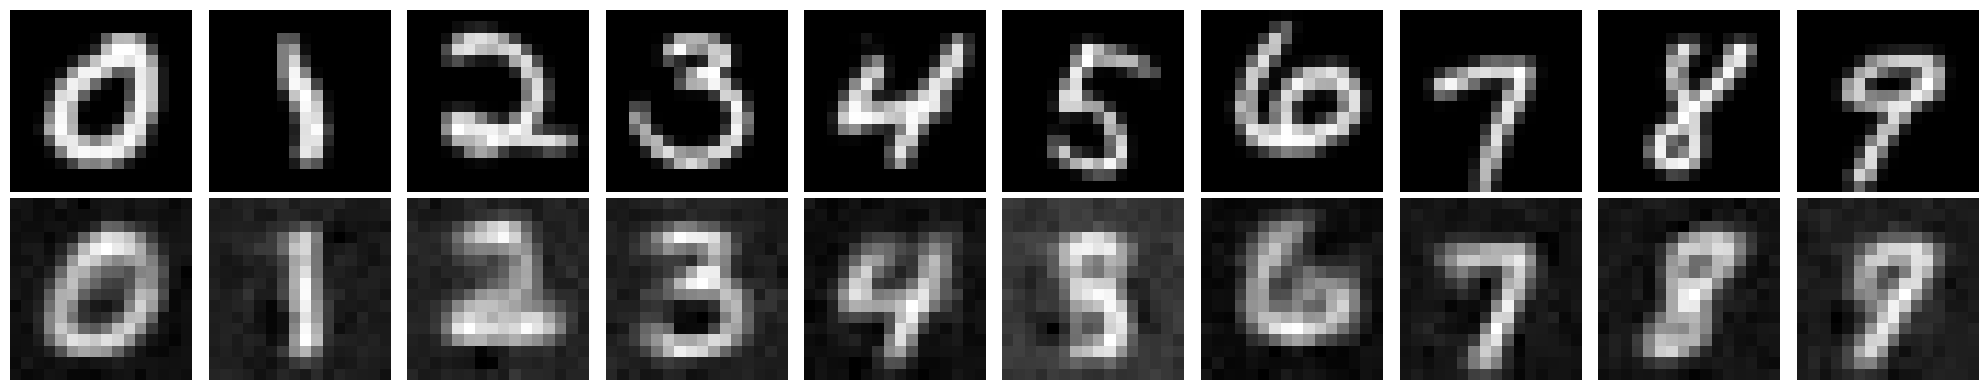

100%|██████████| 375/375 [01:54<00:00,  3.26it/s]


Epoch 3/50, Loss: 0.195302


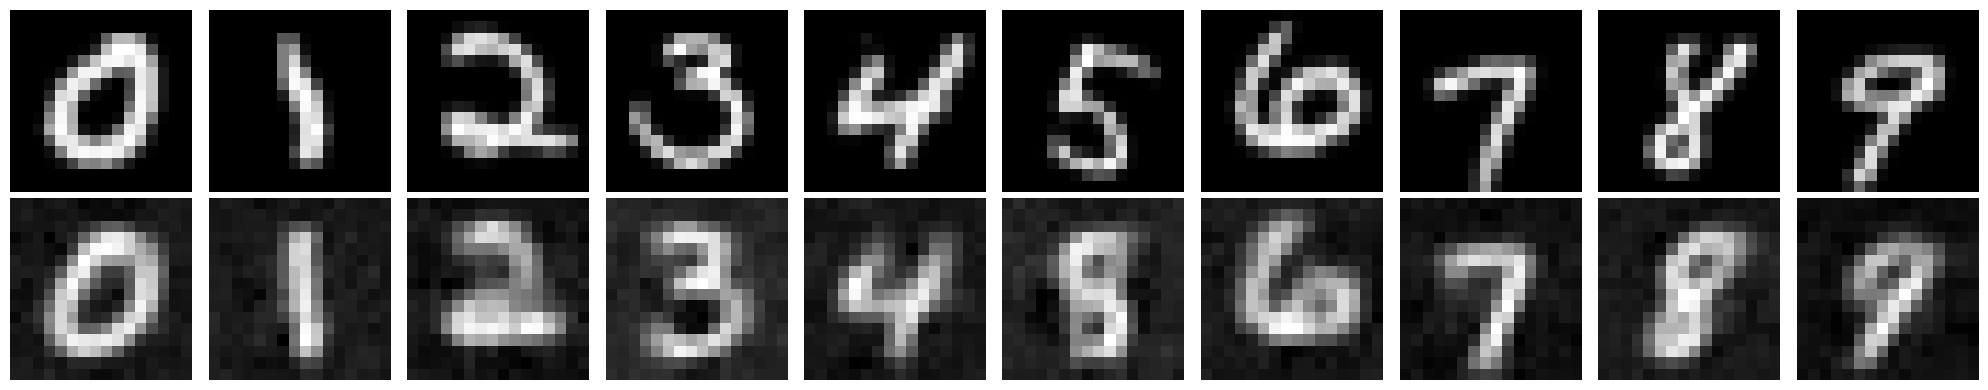

100%|██████████| 375/375 [01:54<00:00,  3.27it/s]


Epoch 4/50, Loss: 0.186427


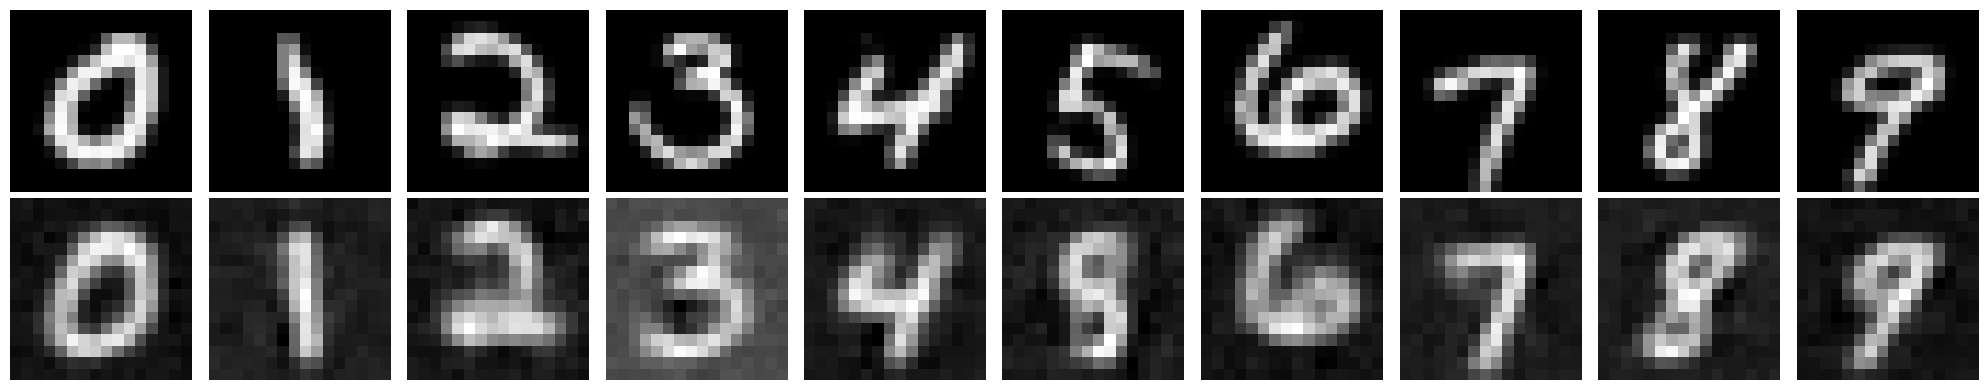

100%|██████████| 375/375 [01:54<00:00,  3.27it/s]


Epoch 5/50, Loss: 0.179479


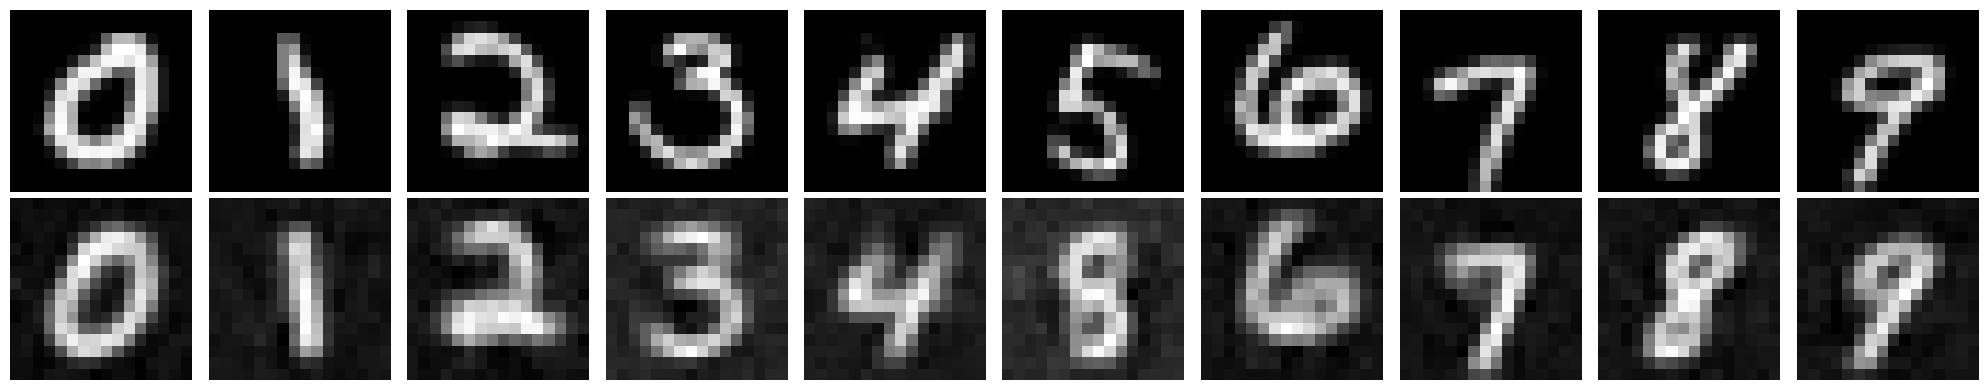

100%|██████████| 375/375 [01:53<00:00,  3.29it/s]


Epoch 6/50, Loss: 0.176223


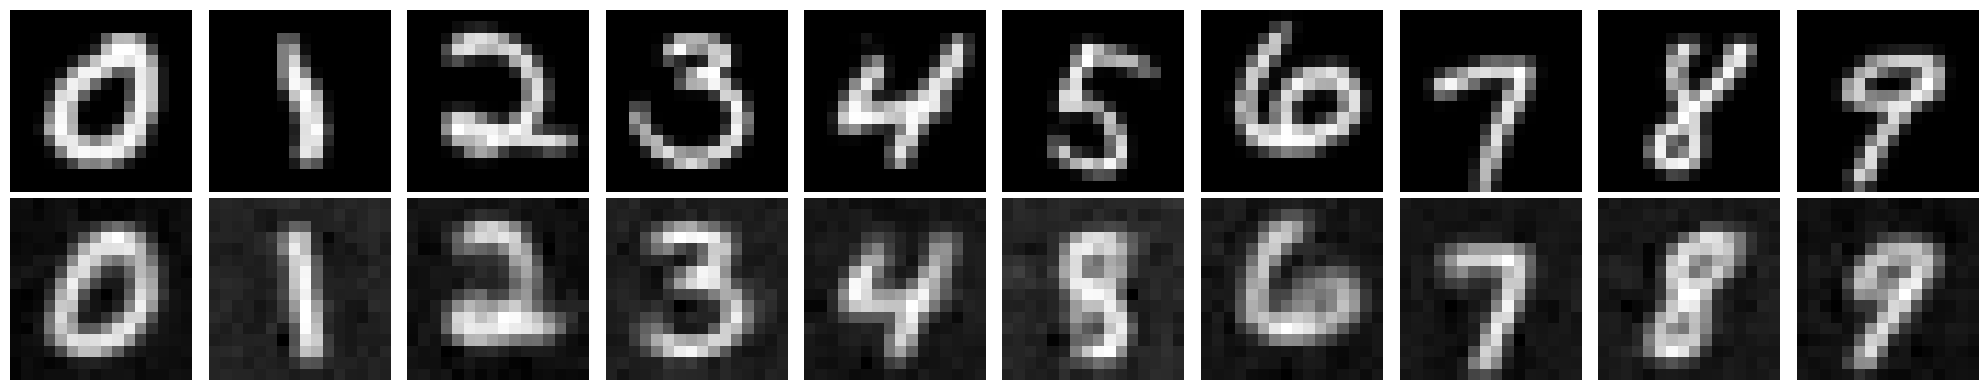

100%|██████████| 375/375 [01:54<00:00,  3.27it/s]


Epoch 7/50, Loss: 0.172775


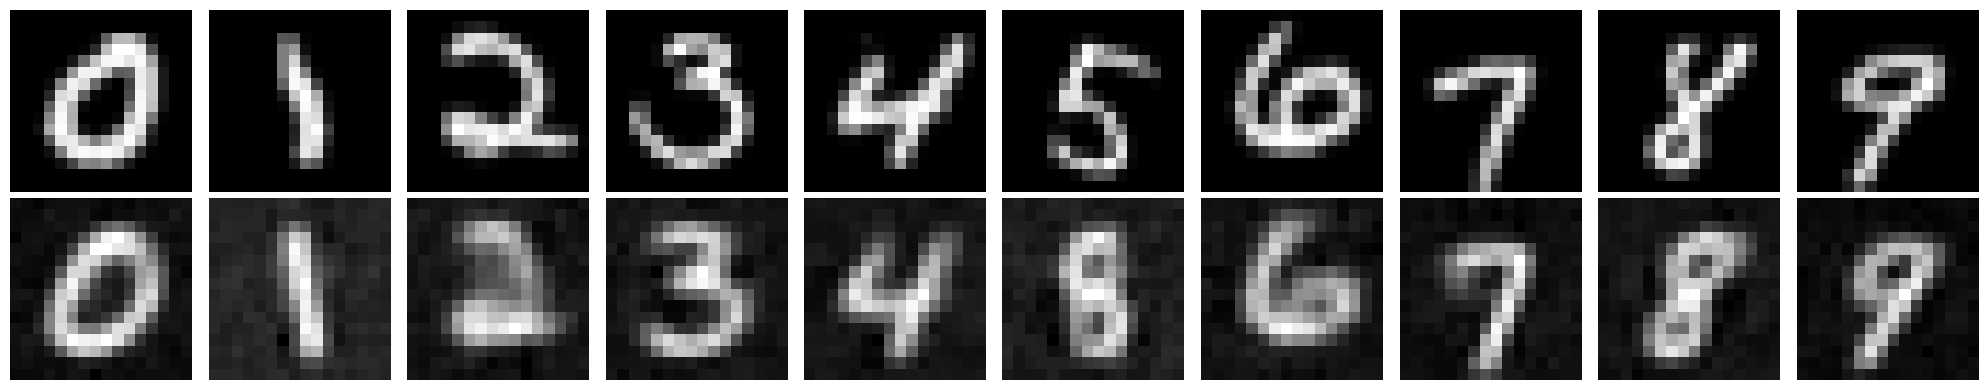

100%|██████████| 375/375 [01:51<00:00,  3.36it/s]


Epoch 8/50, Loss: 0.170867


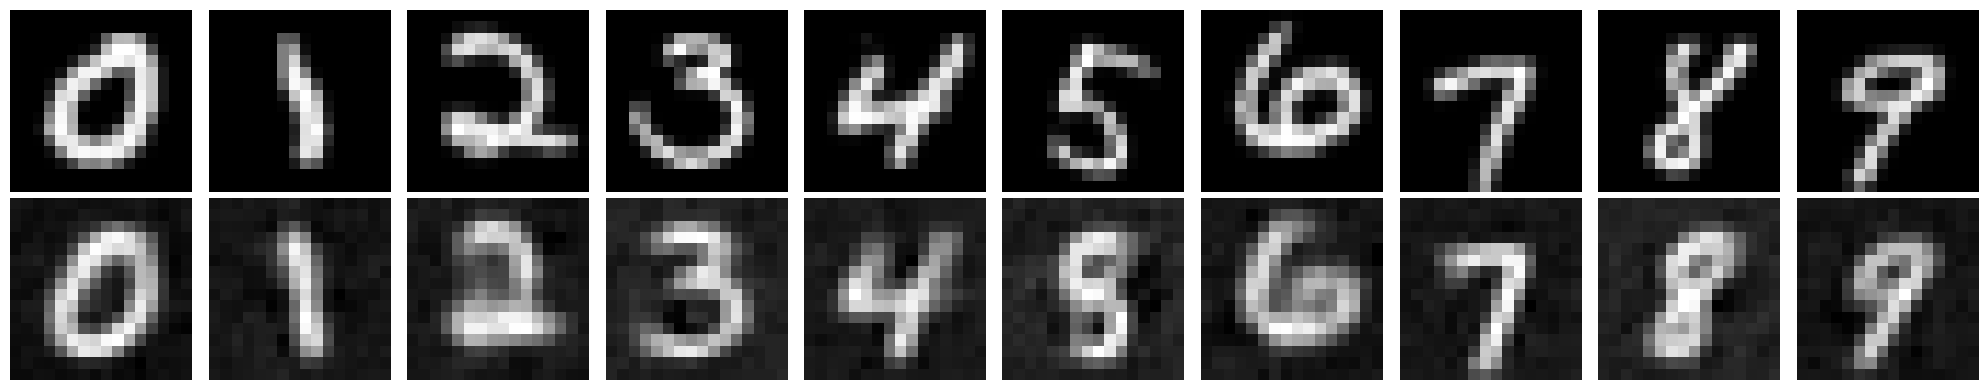

100%|██████████| 375/375 [01:54<00:00,  3.27it/s]


Epoch 9/50, Loss: 0.168457


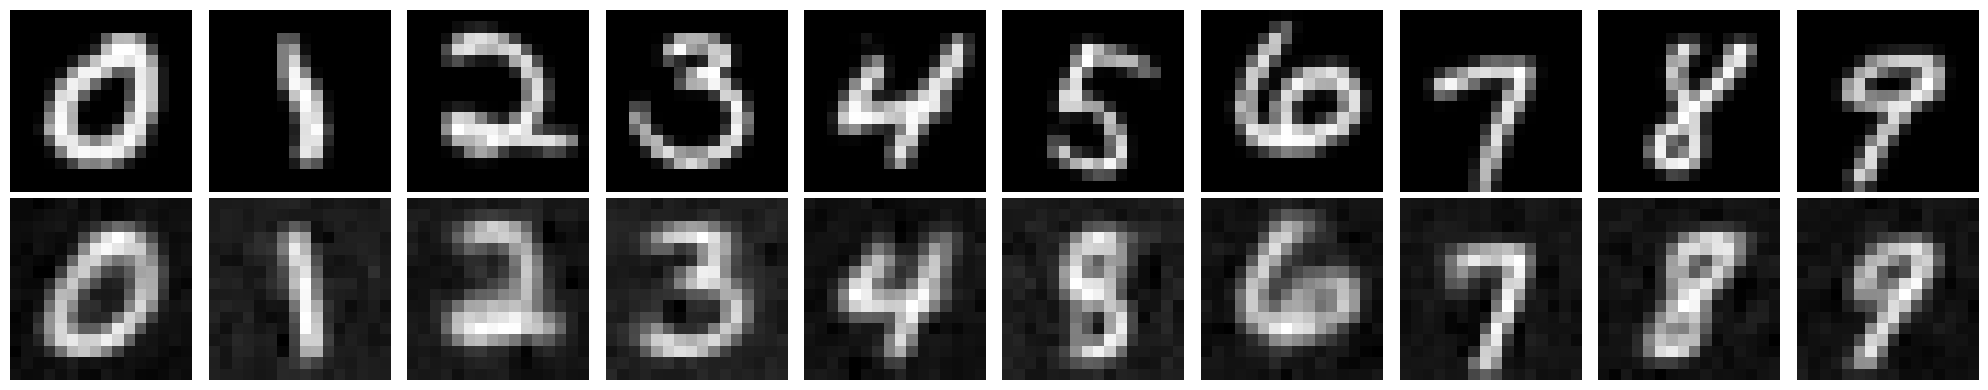

100%|██████████| 375/375 [01:55<00:00,  3.26it/s]


Epoch 10/50, Loss: 0.166155


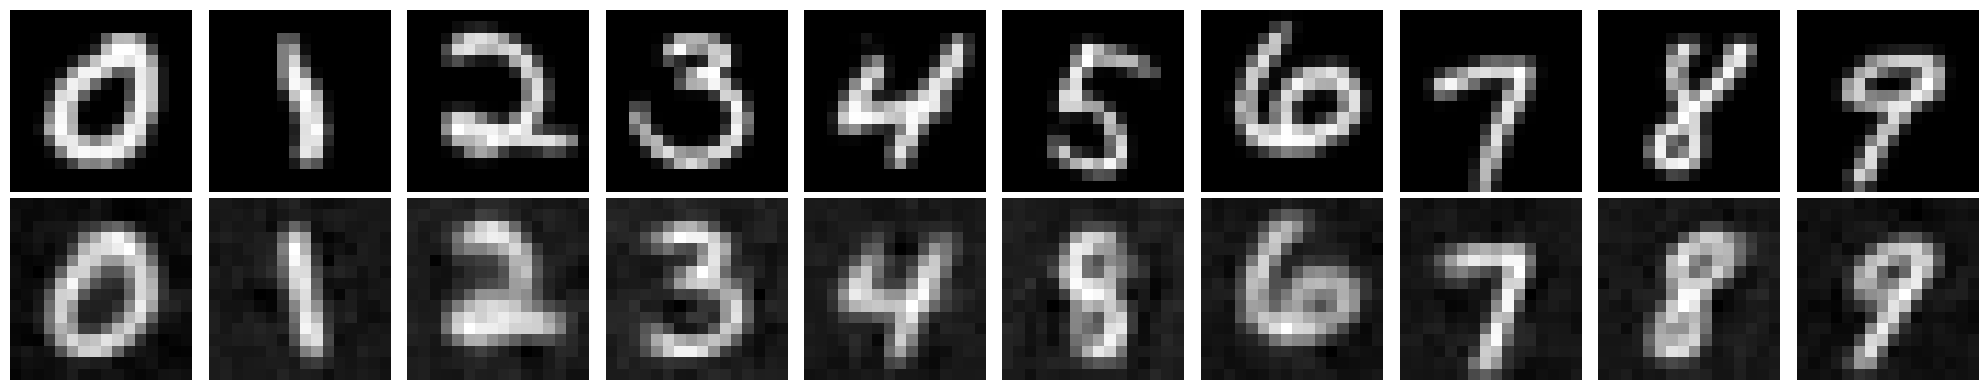

100%|██████████| 375/375 [01:54<00:00,  3.27it/s]


Epoch 11/50, Loss: 0.164413


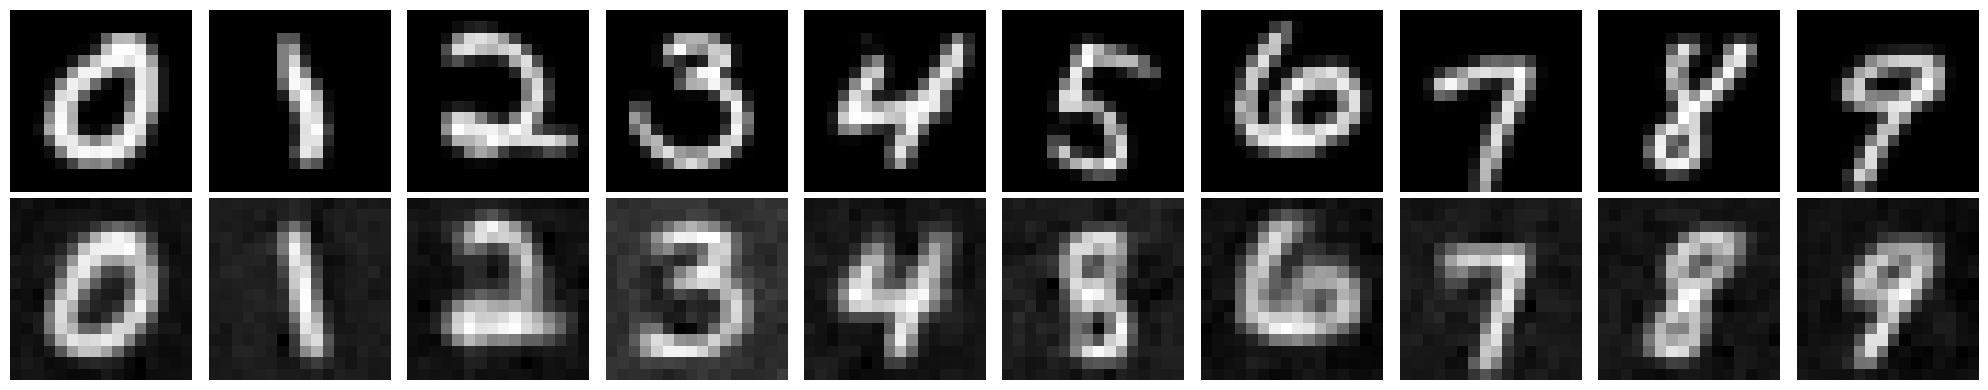

100%|██████████| 375/375 [01:55<00:00,  3.26it/s]


Epoch 12/50, Loss: 0.162111


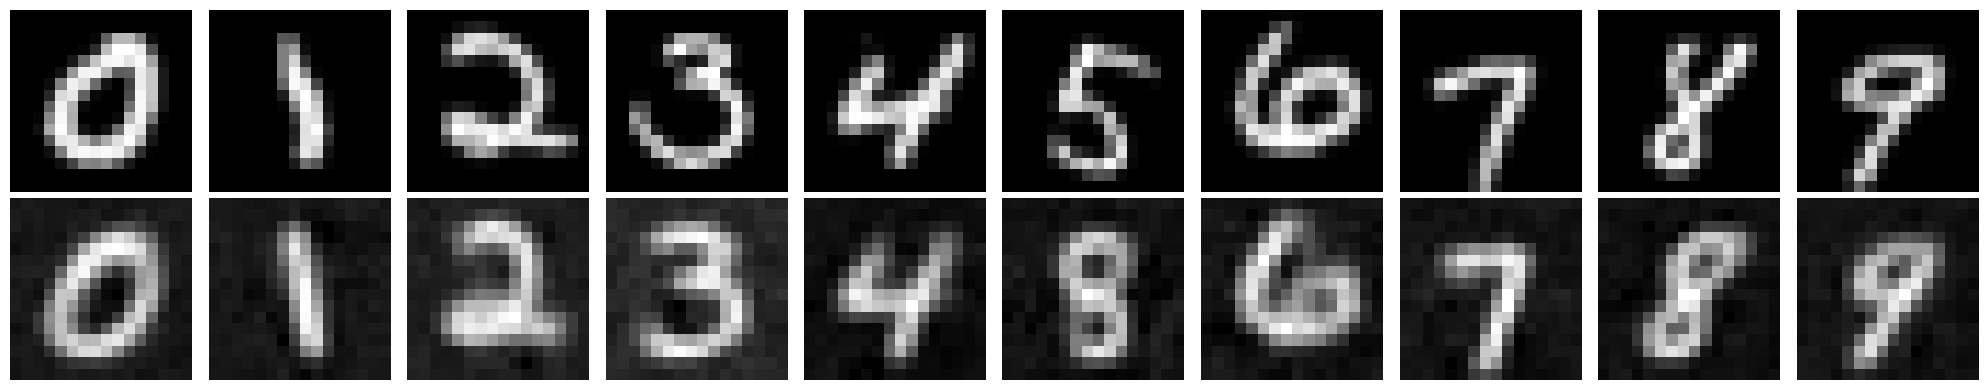

100%|██████████| 375/375 [01:54<00:00,  3.28it/s]


Epoch 13/50, Loss: 0.161051


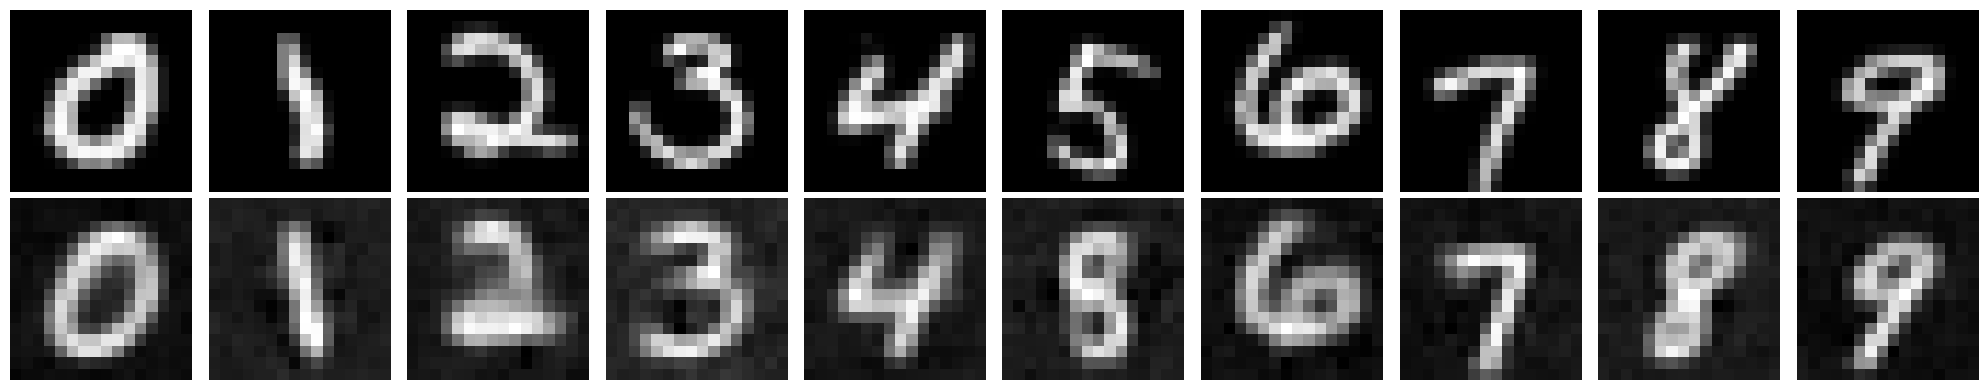

100%|██████████| 375/375 [01:53<00:00,  3.30it/s]


Epoch 14/50, Loss: 0.159150


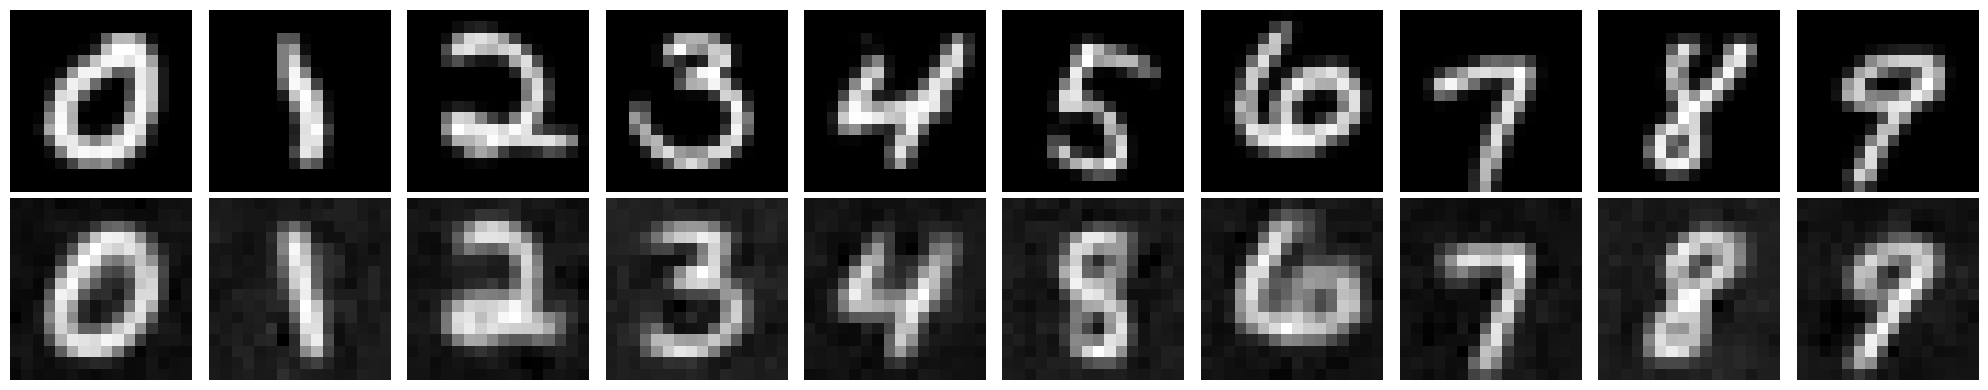

100%|██████████| 375/375 [01:52<00:00,  3.33it/s]


Epoch 15/50, Loss: 0.157550


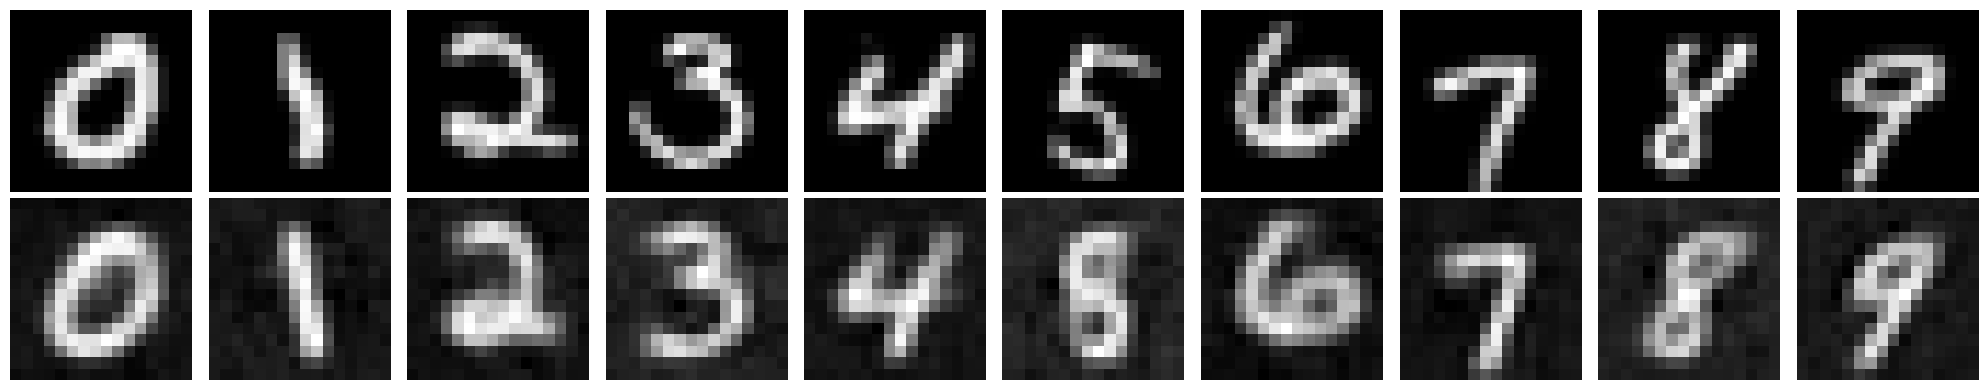

100%|██████████| 375/375 [01:54<00:00,  3.27it/s]


Epoch 16/50, Loss: 0.157298


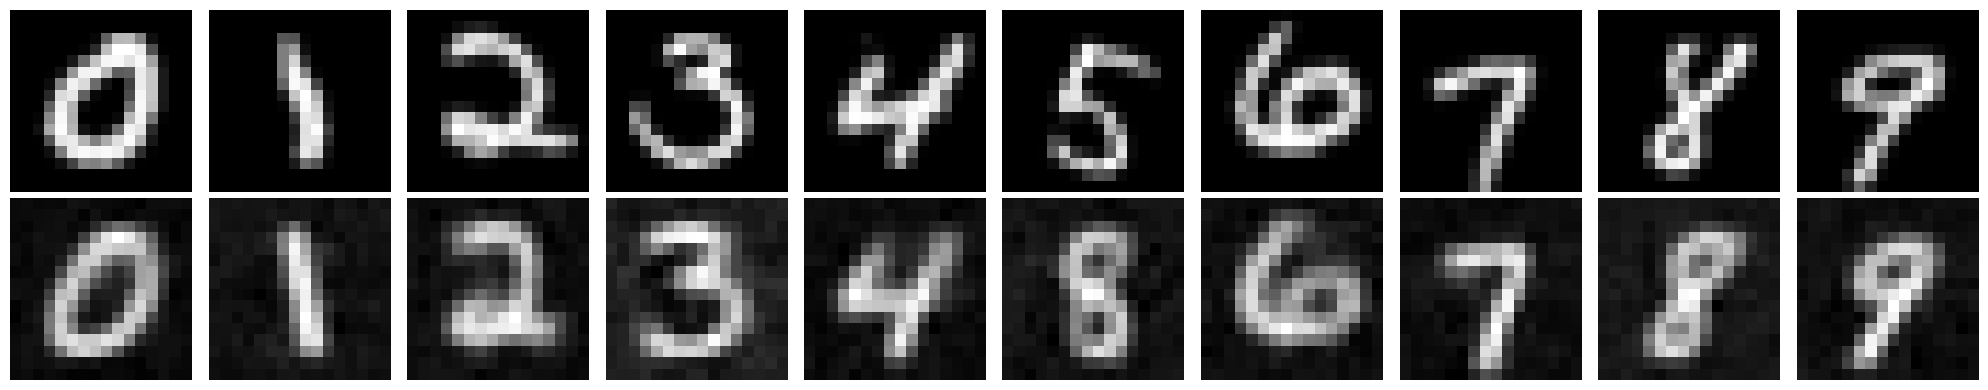

100%|██████████| 375/375 [01:54<00:00,  3.28it/s]


Epoch 17/50, Loss: 0.155547


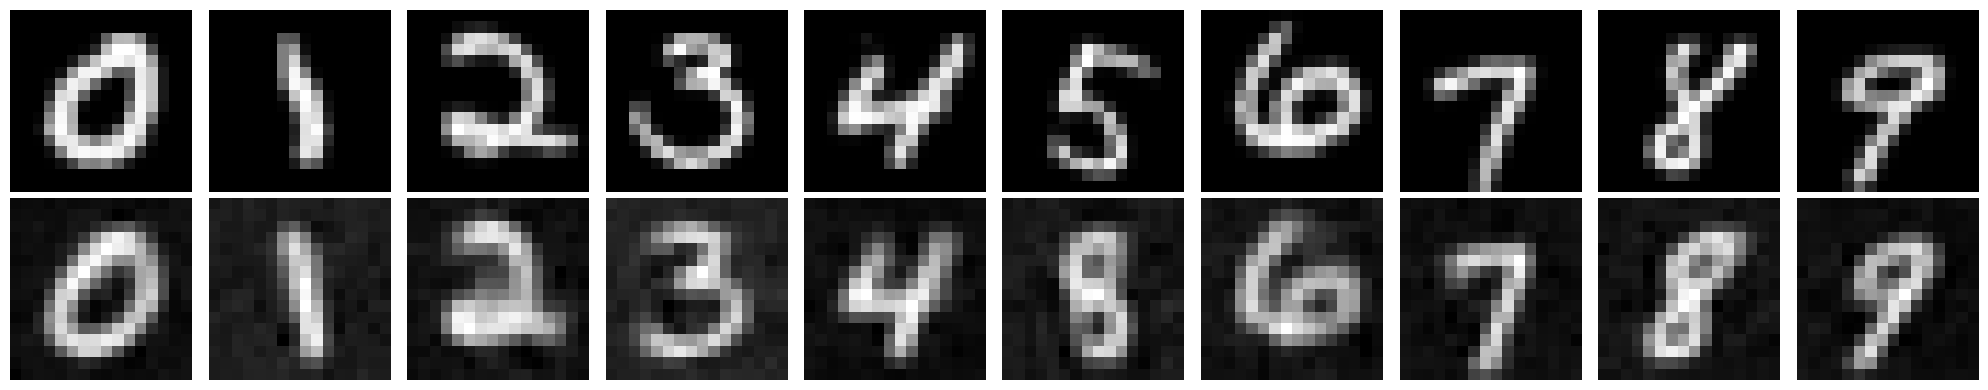

100%|██████████| 375/375 [01:55<00:00,  3.26it/s]


Epoch 18/50, Loss: 0.154117


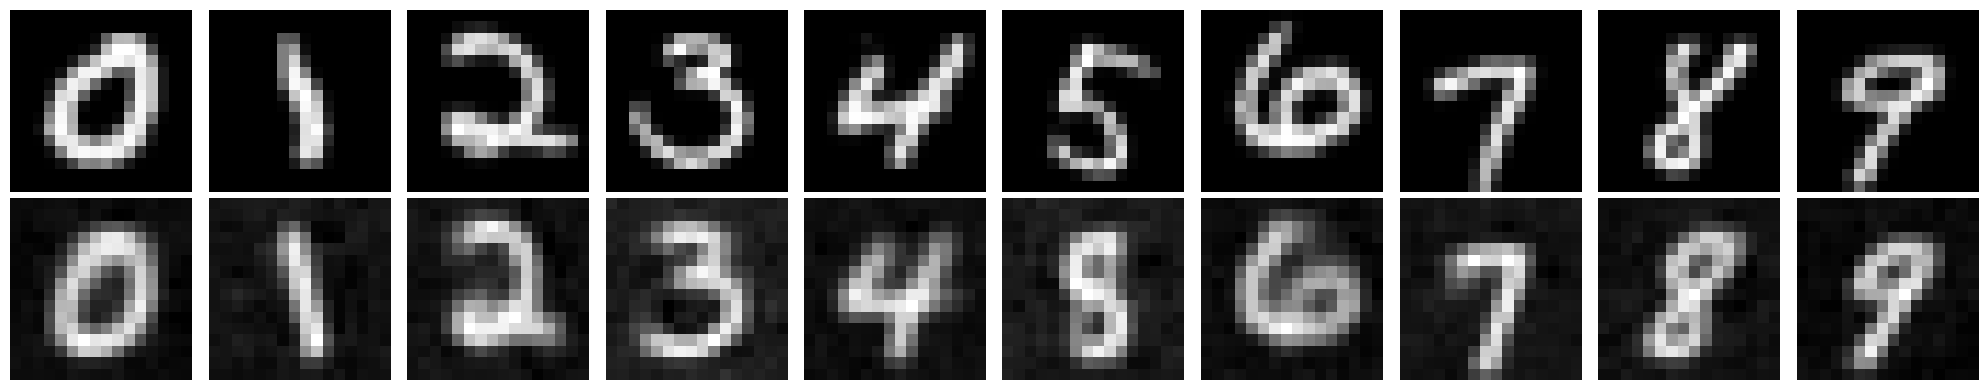

100%|██████████| 375/375 [01:54<00:00,  3.29it/s]


Epoch 19/50, Loss: 0.153452


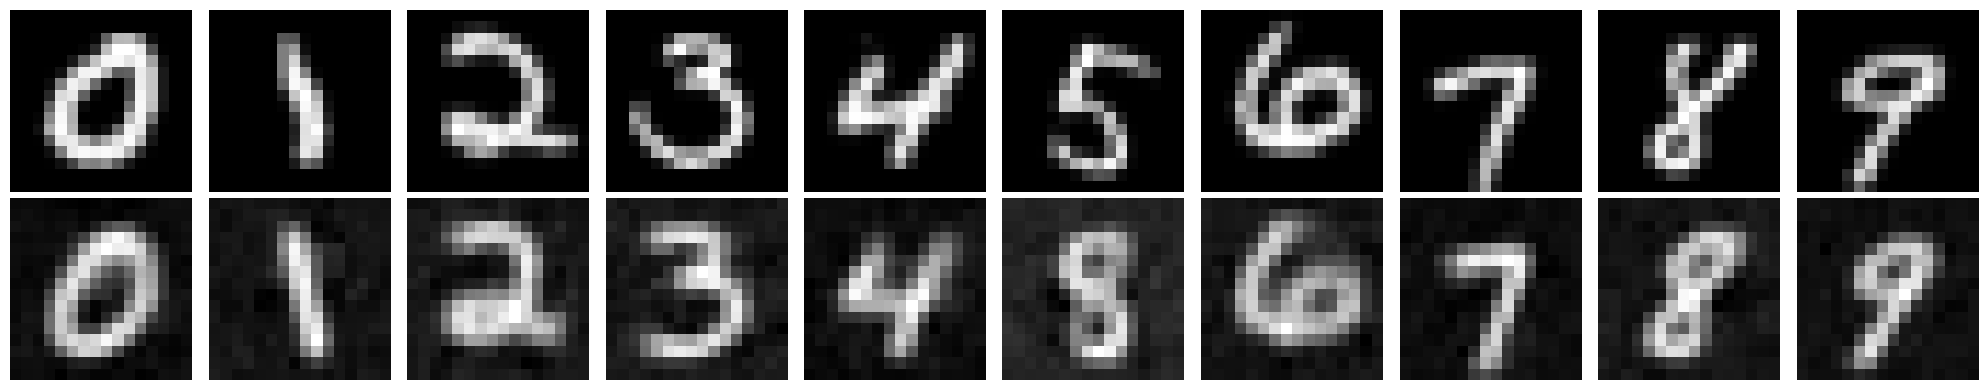

100%|██████████| 375/375 [01:54<00:00,  3.27it/s]


Epoch 20/50, Loss: 0.152089


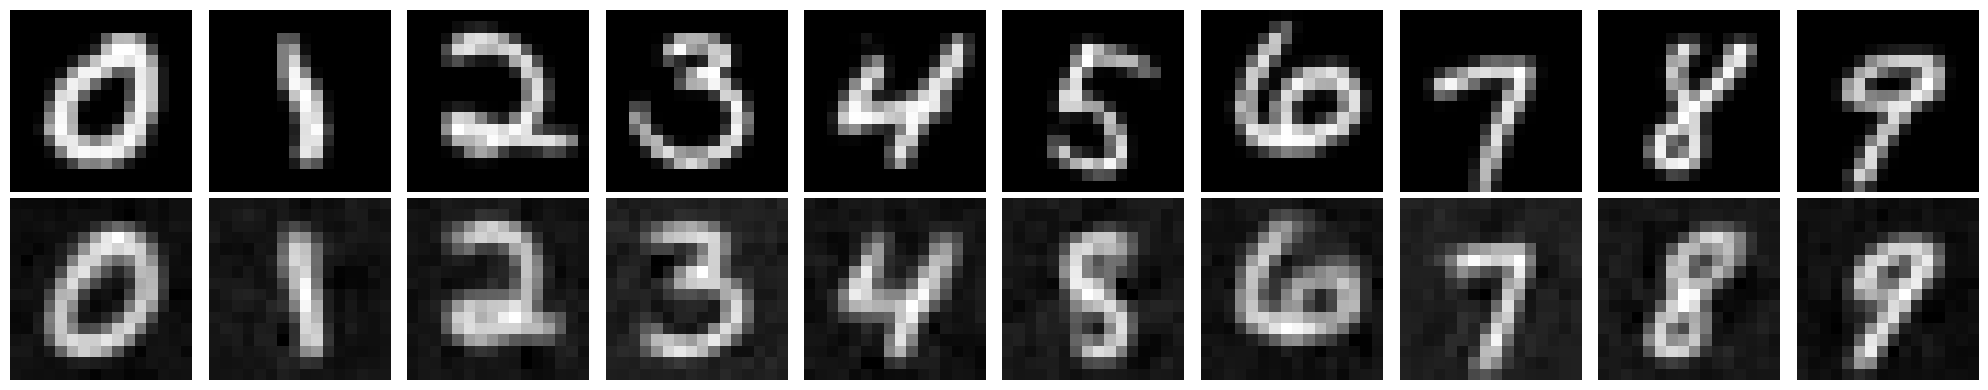

100%|██████████| 375/375 [01:54<00:00,  3.26it/s]


Epoch 21/50, Loss: 0.150132


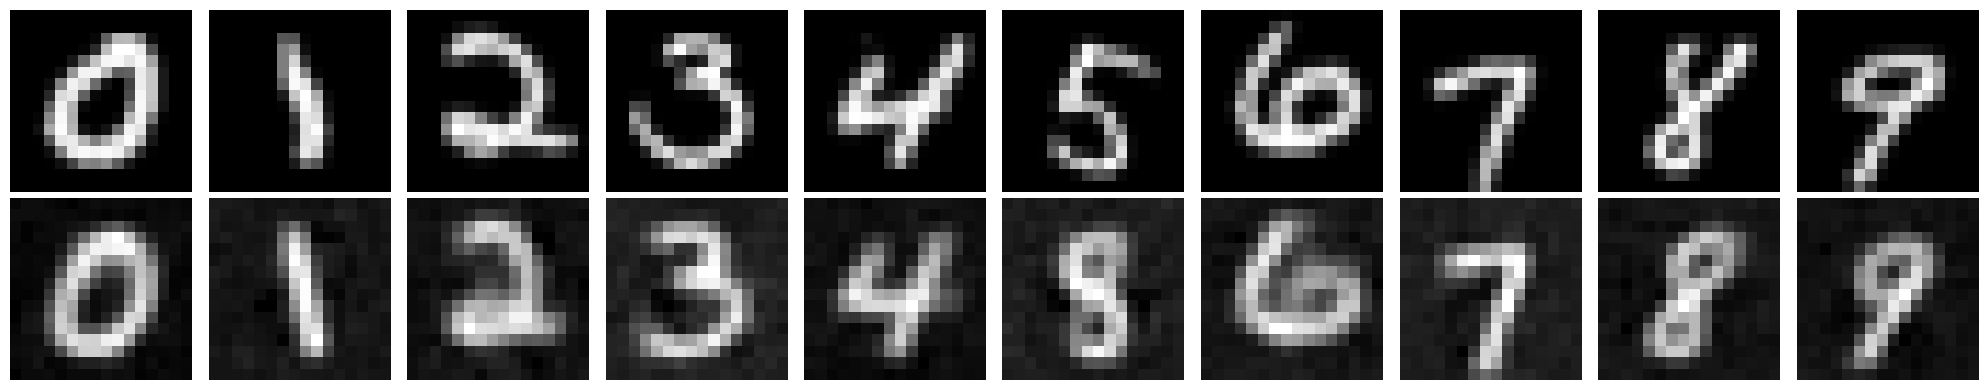

100%|██████████| 375/375 [01:52<00:00,  3.32it/s]


Epoch 22/50, Loss: 0.150615


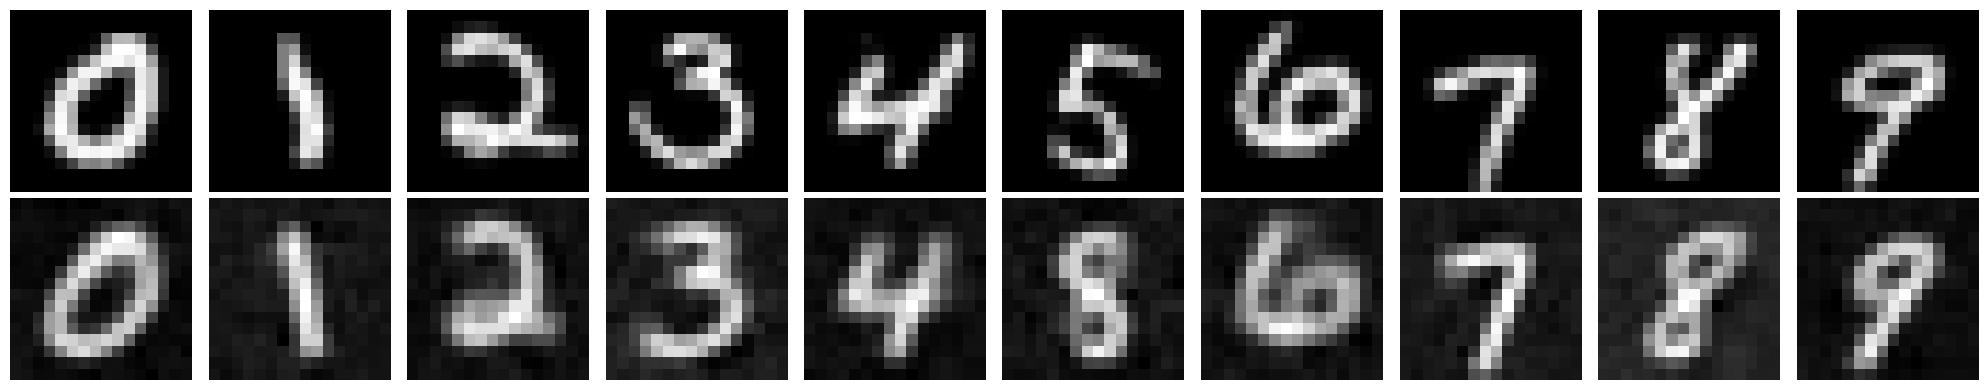

100%|██████████| 375/375 [01:52<00:00,  3.32it/s]


Epoch 23/50, Loss: 0.148161


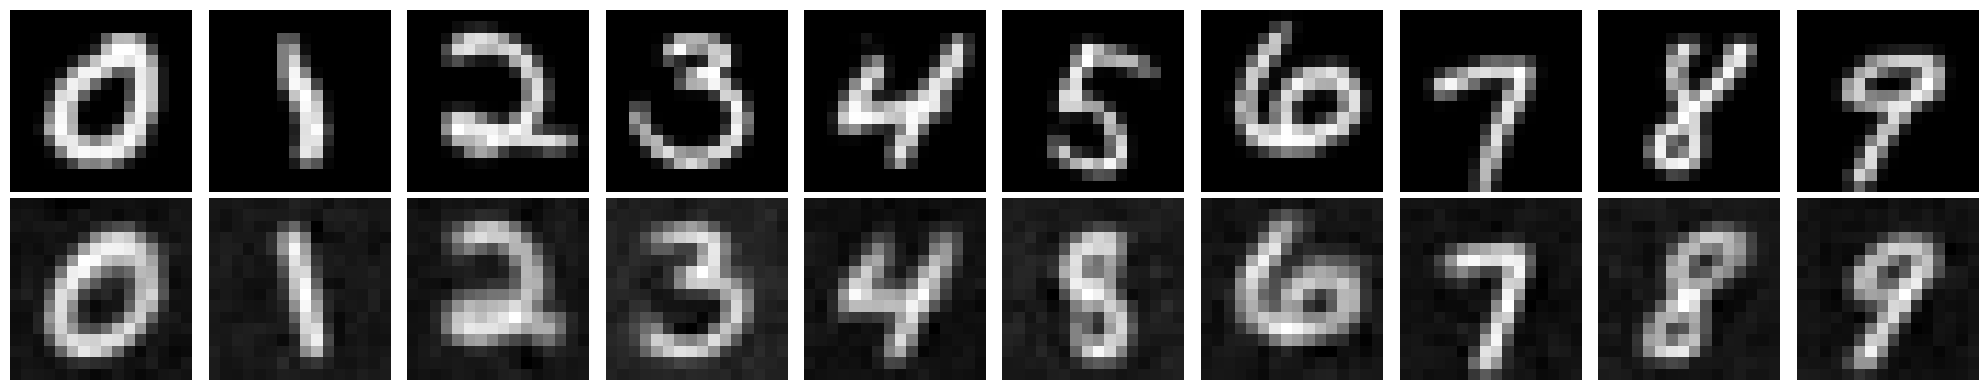

100%|██████████| 375/375 [01:54<00:00,  3.28it/s]


Epoch 24/50, Loss: 0.147484


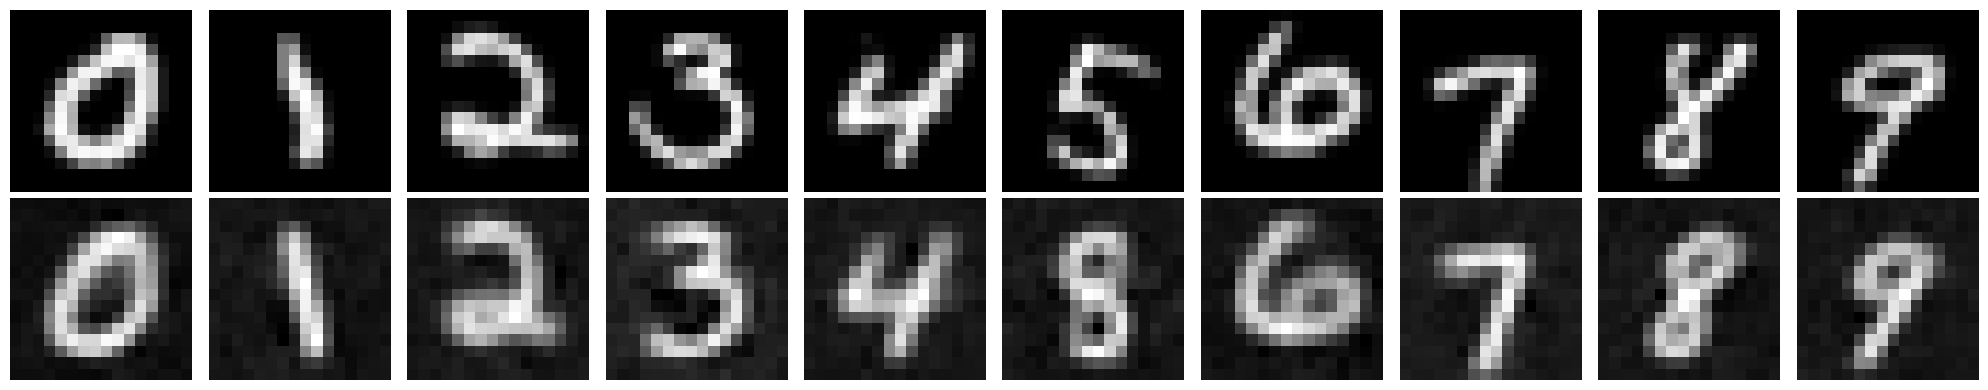

100%|██████████| 375/375 [01:55<00:00,  3.24it/s]


Epoch 25/50, Loss: 0.147140


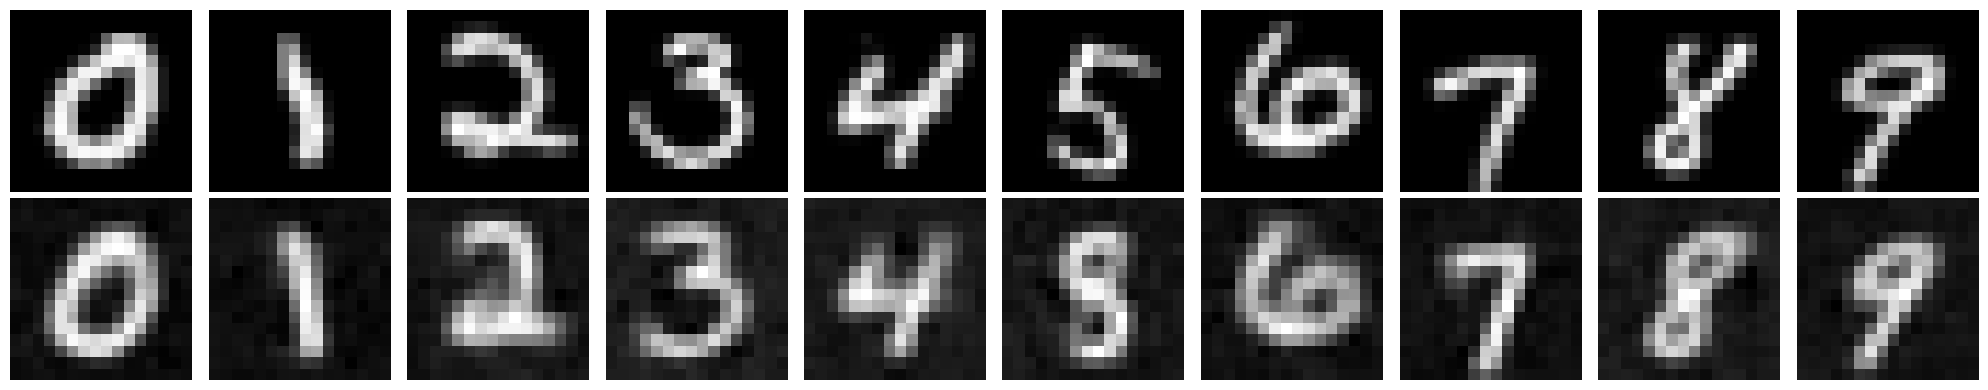

100%|██████████| 375/375 [01:55<00:00,  3.26it/s]


Epoch 26/50, Loss: 0.145968


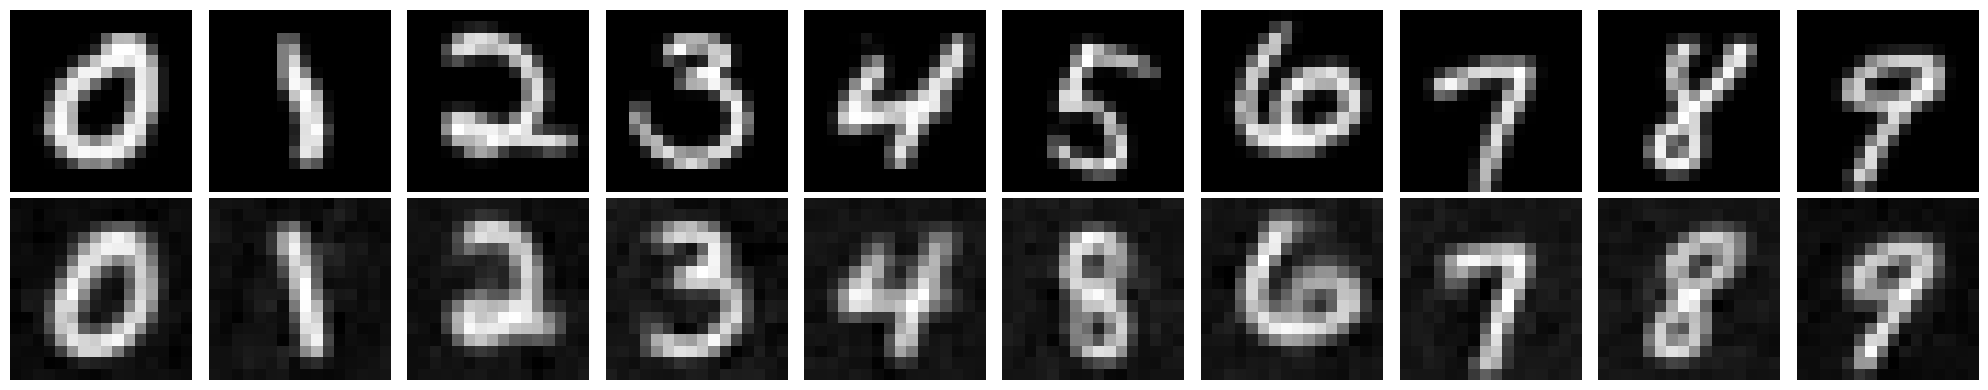

100%|██████████| 375/375 [01:56<00:00,  3.21it/s]


Epoch 27/50, Loss: 0.145331


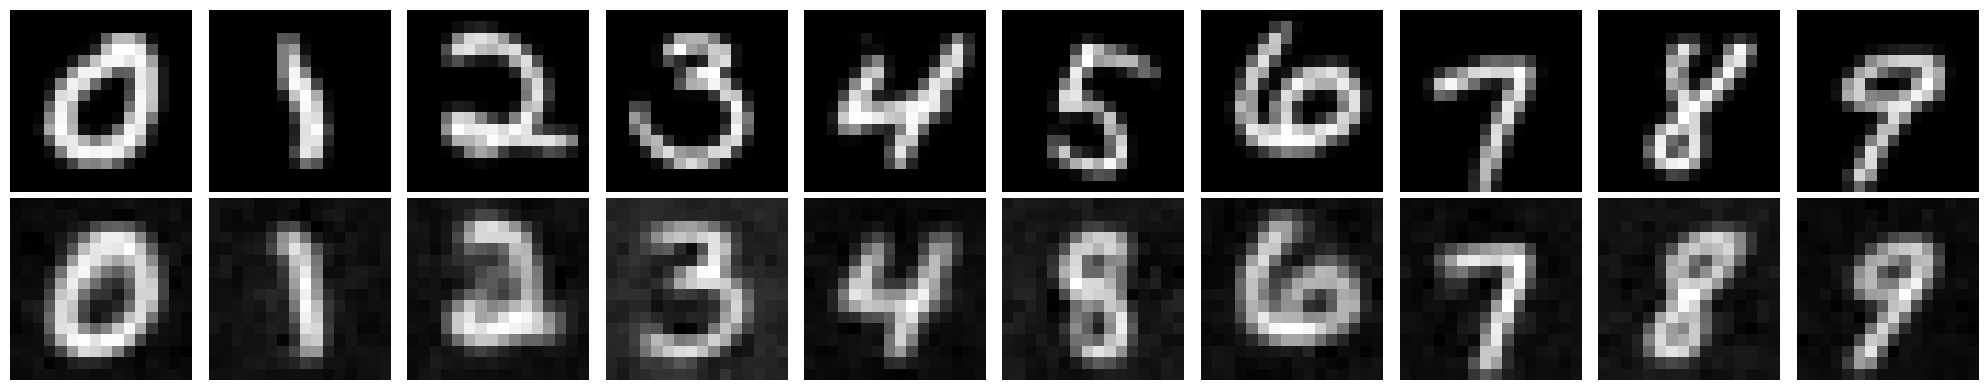

100%|██████████| 375/375 [01:53<00:00,  3.30it/s]


Epoch 28/50, Loss: 0.144550


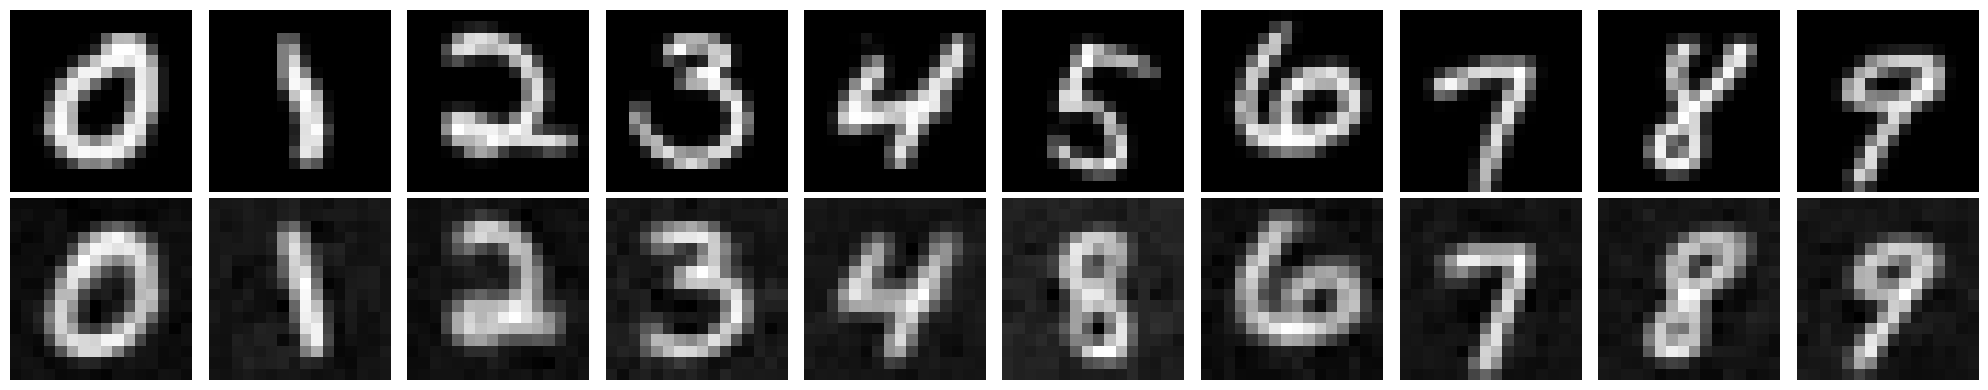

100%|██████████| 375/375 [01:54<00:00,  3.29it/s]


Epoch 29/50, Loss: 0.143908


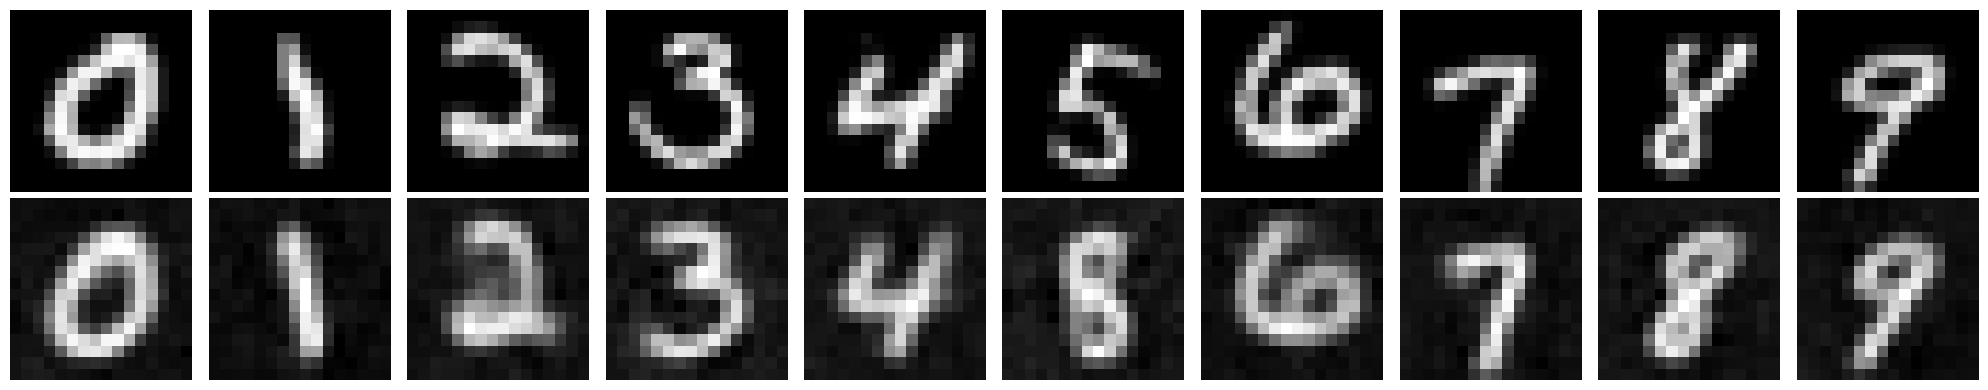

100%|██████████| 375/375 [01:56<00:00,  3.22it/s]


Epoch 30/50, Loss: 0.142800


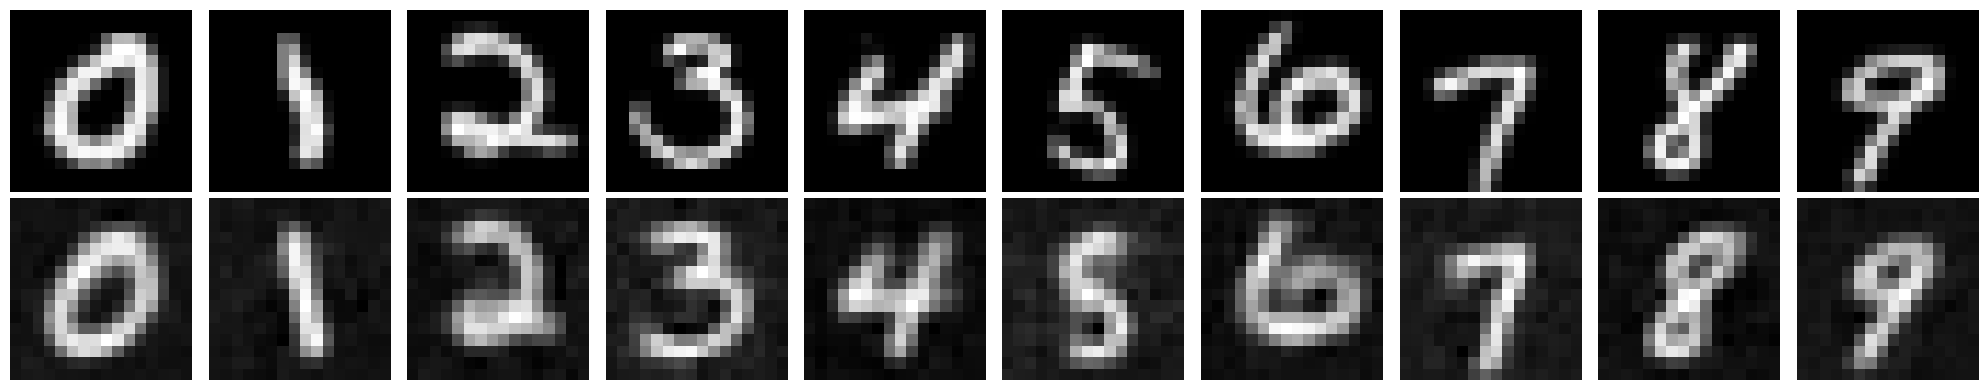

100%|██████████| 375/375 [01:54<00:00,  3.26it/s]


Epoch 31/50, Loss: 0.141152


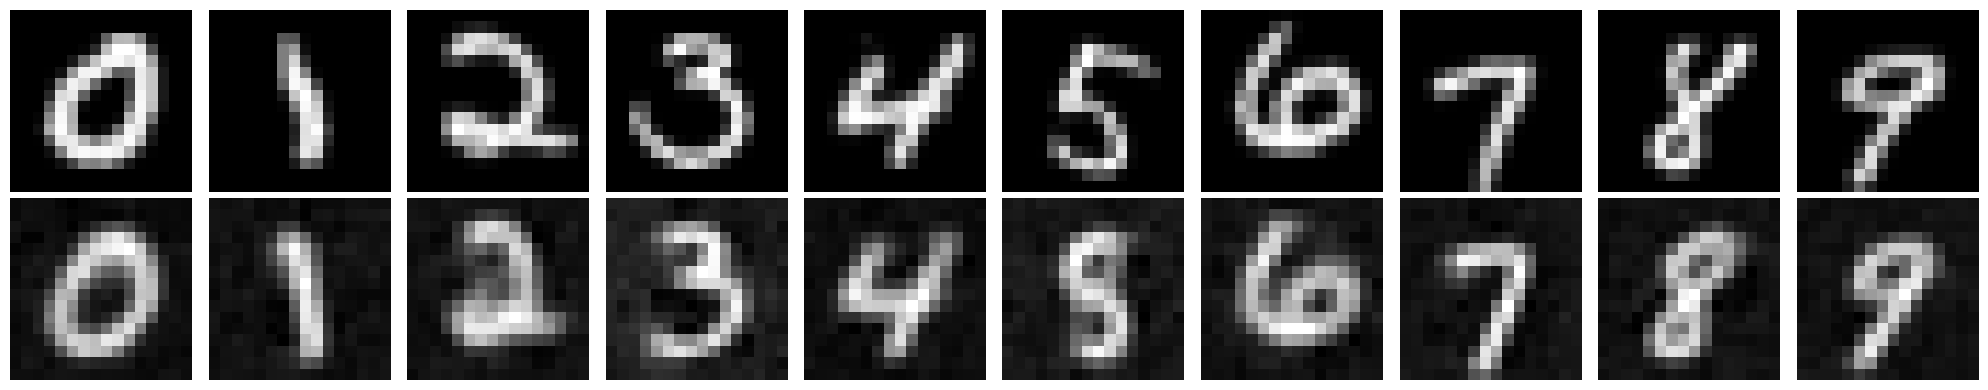

100%|██████████| 375/375 [01:56<00:00,  3.21it/s]


Epoch 32/50, Loss: 0.141468


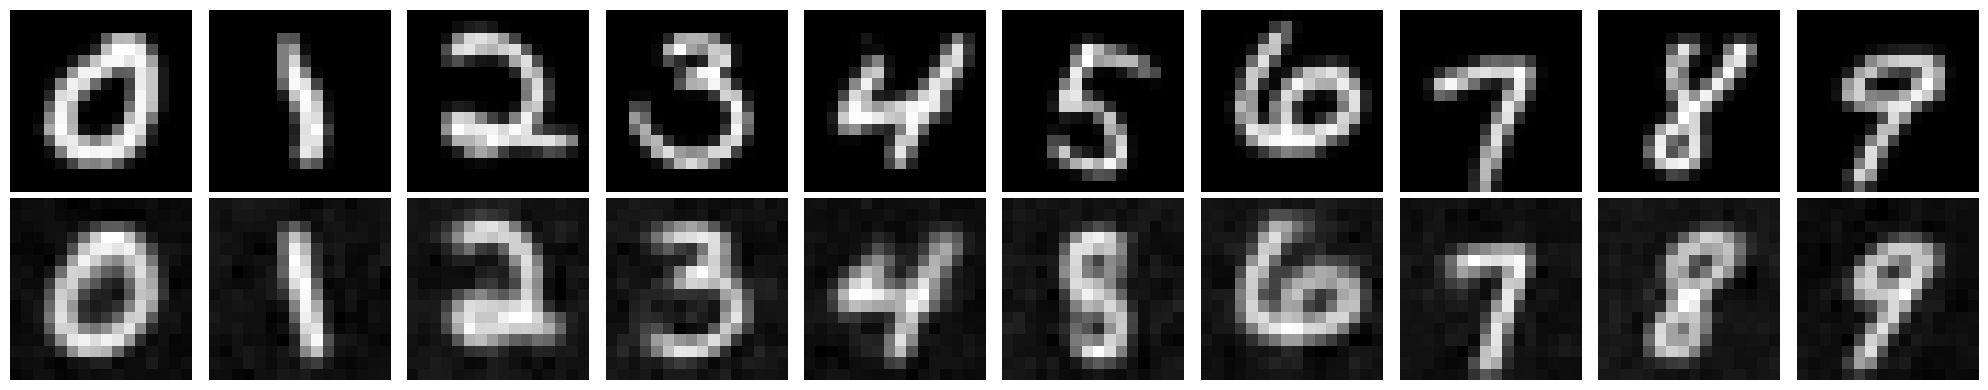

100%|██████████| 375/375 [01:54<00:00,  3.27it/s]


Epoch 33/50, Loss: 0.139636


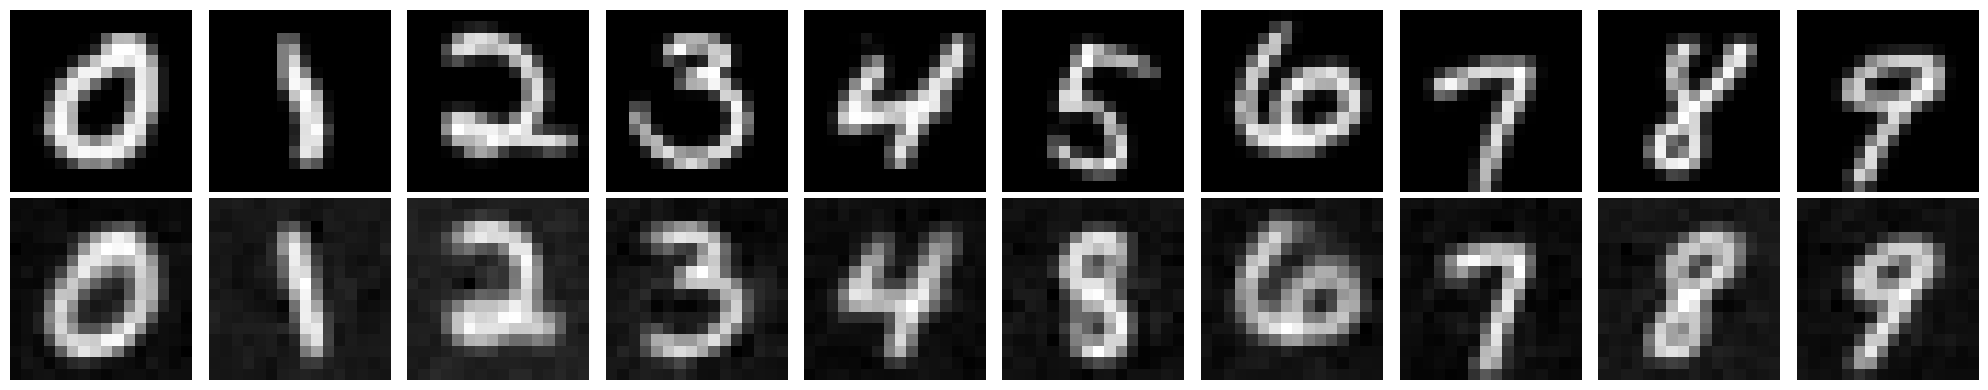

100%|██████████| 375/375 [01:55<00:00,  3.26it/s]


Epoch 34/50, Loss: 0.139926


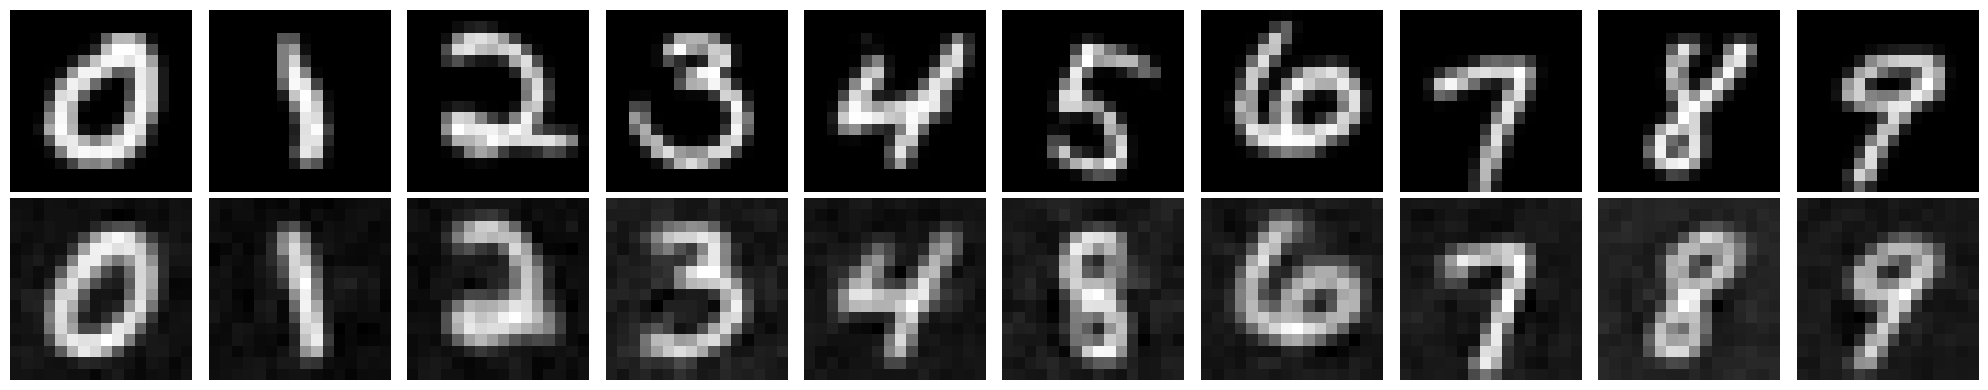

100%|██████████| 375/375 [01:56<00:00,  3.23it/s]


Epoch 35/50, Loss: 0.138953


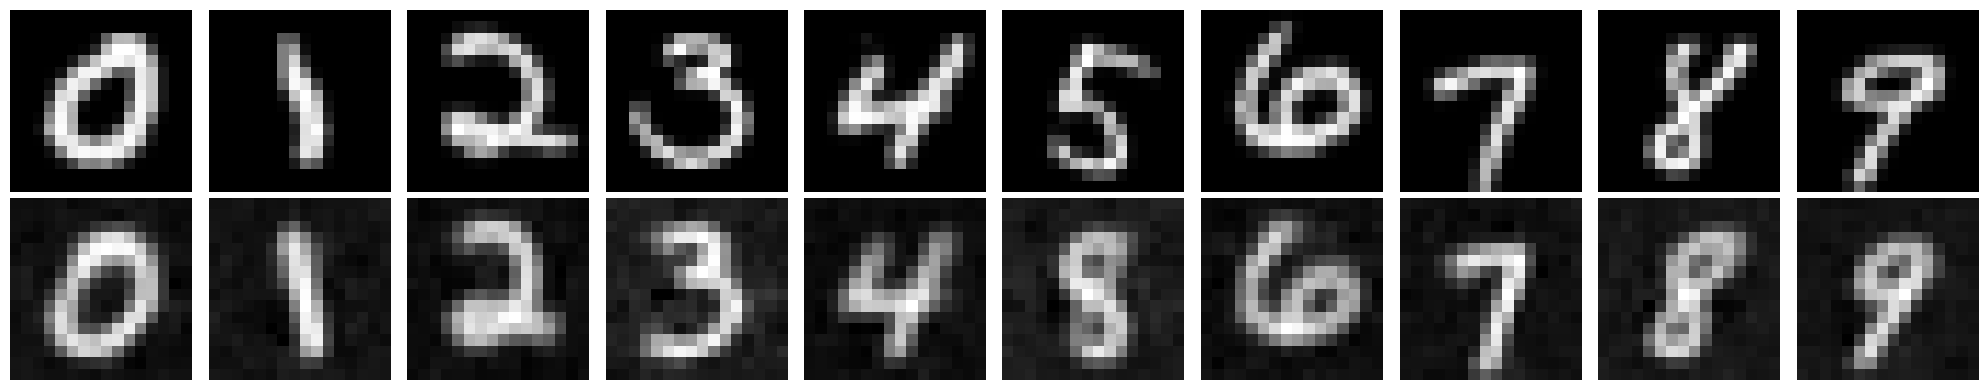

100%|██████████| 375/375 [01:55<00:00,  3.24it/s]


Epoch 36/50, Loss: 0.137716


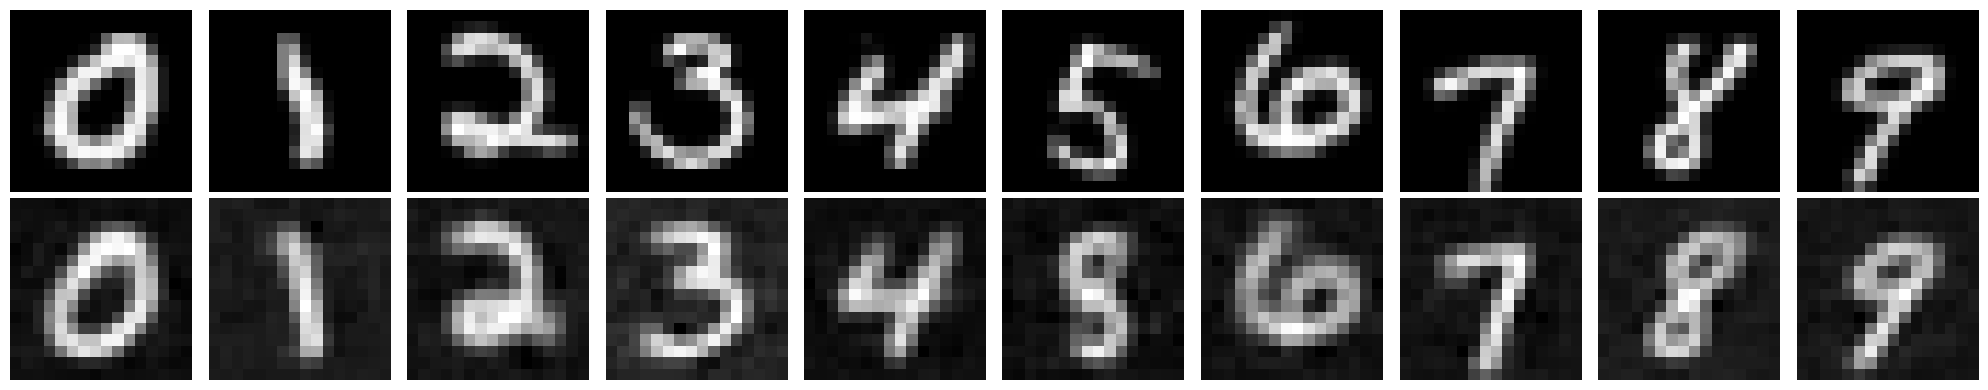

100%|██████████| 375/375 [01:57<00:00,  3.20it/s]


Epoch 37/50, Loss: 0.137983


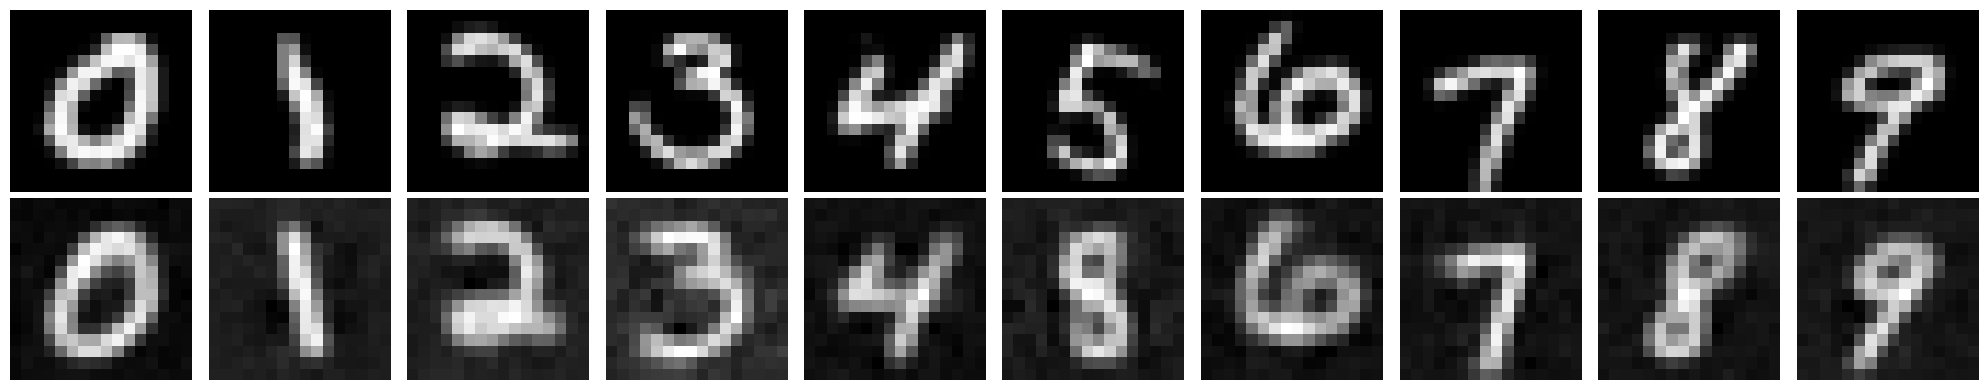

100%|██████████| 375/375 [01:56<00:00,  3.21it/s]


Epoch 38/50, Loss: 0.136634


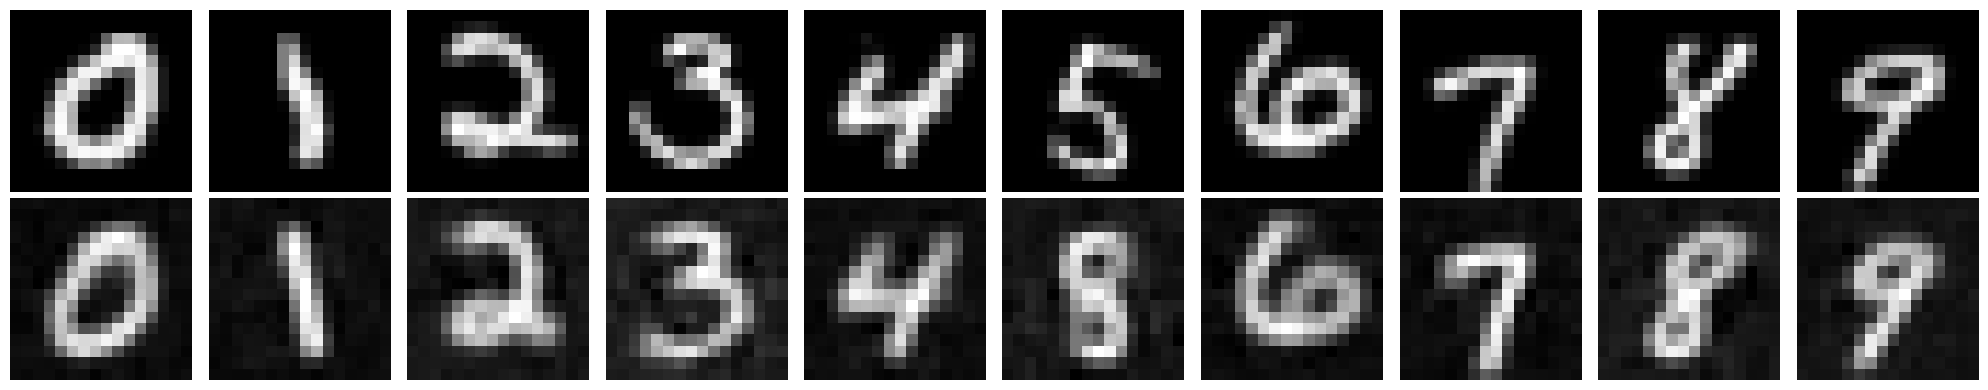

100%|██████████| 375/375 [01:55<00:00,  3.24it/s]


Epoch 39/50, Loss: 0.136868


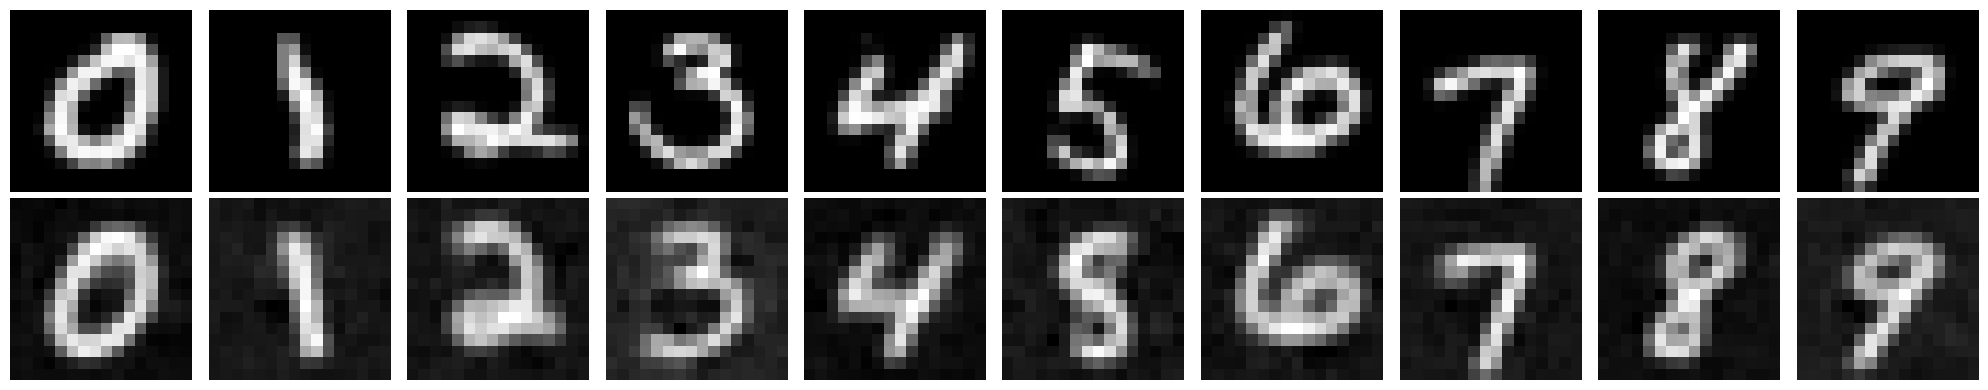

100%|██████████| 375/375 [01:56<00:00,  3.22it/s]


Epoch 40/50, Loss: 0.135588


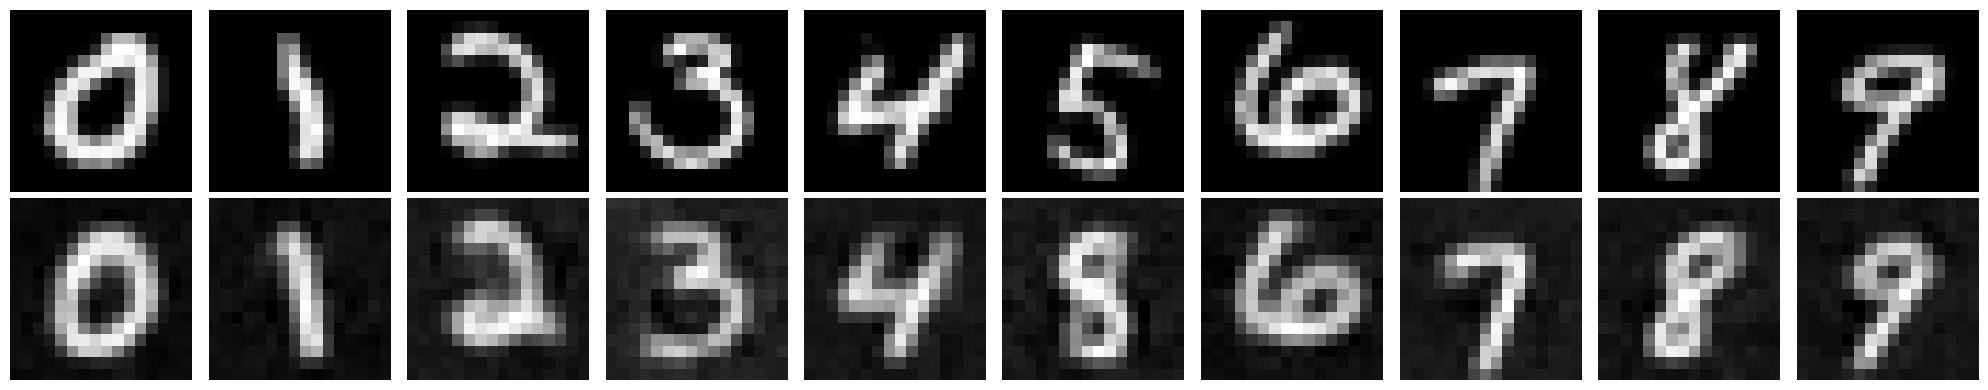

100%|██████████| 375/375 [01:56<00:00,  3.21it/s]


Epoch 41/50, Loss: 0.135233


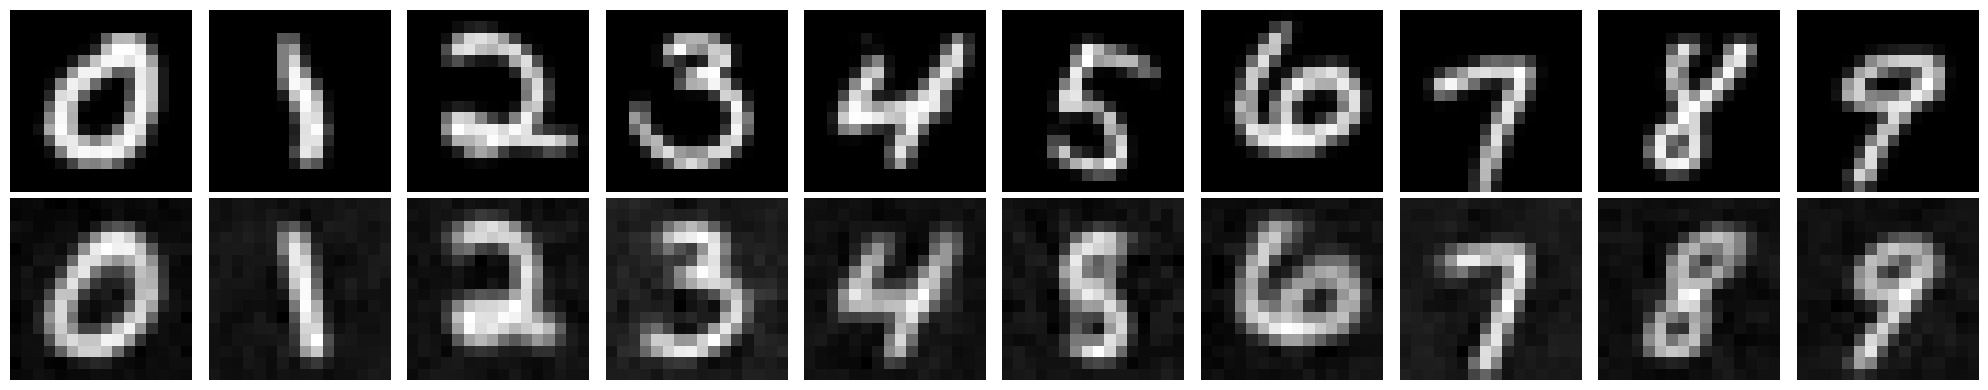

100%|██████████| 375/375 [01:54<00:00,  3.28it/s]


Epoch 42/50, Loss: 0.134463


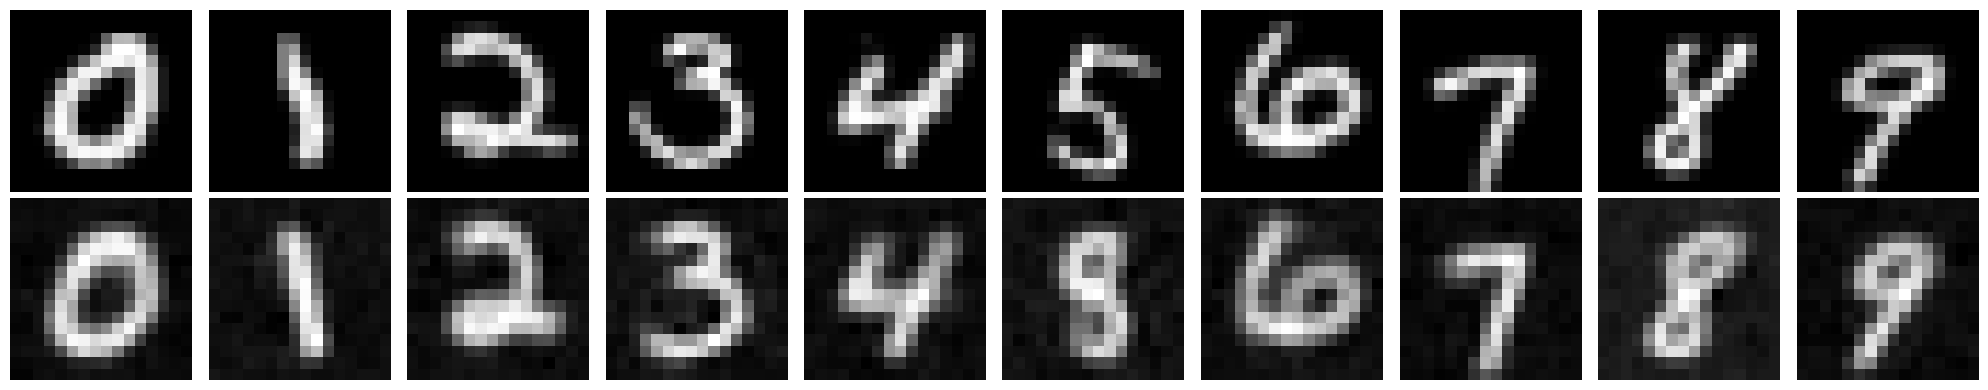

100%|██████████| 375/375 [01:56<00:00,  3.22it/s]


Epoch 43/50, Loss: 0.133676


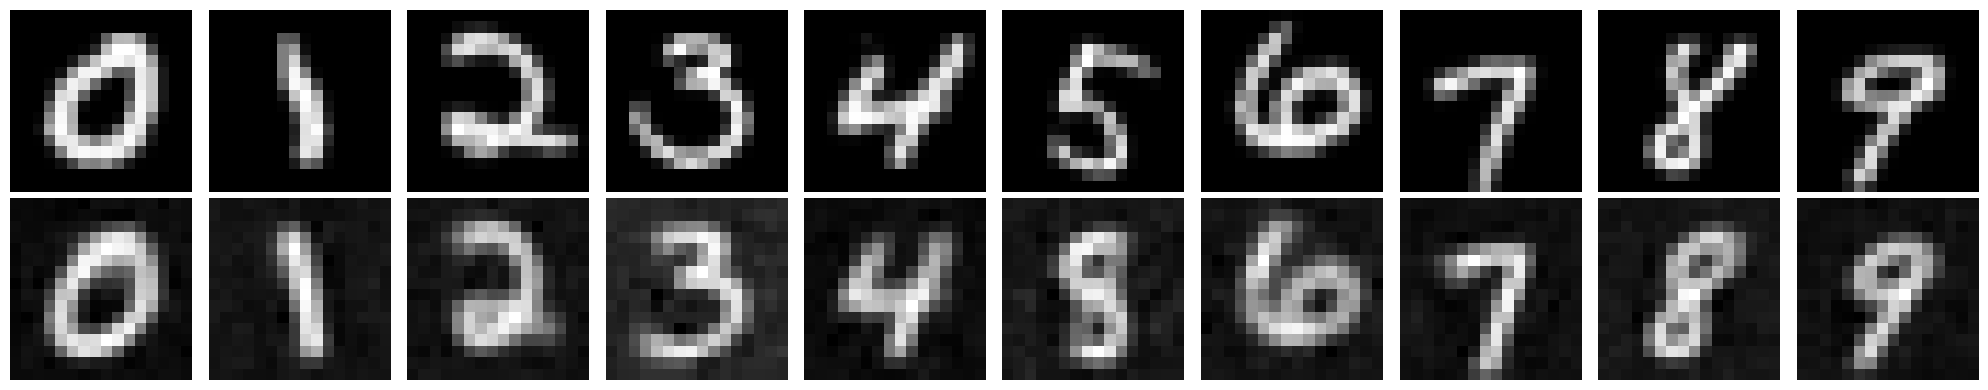

100%|██████████| 375/375 [01:53<00:00,  3.31it/s]


Epoch 44/50, Loss: 0.132660


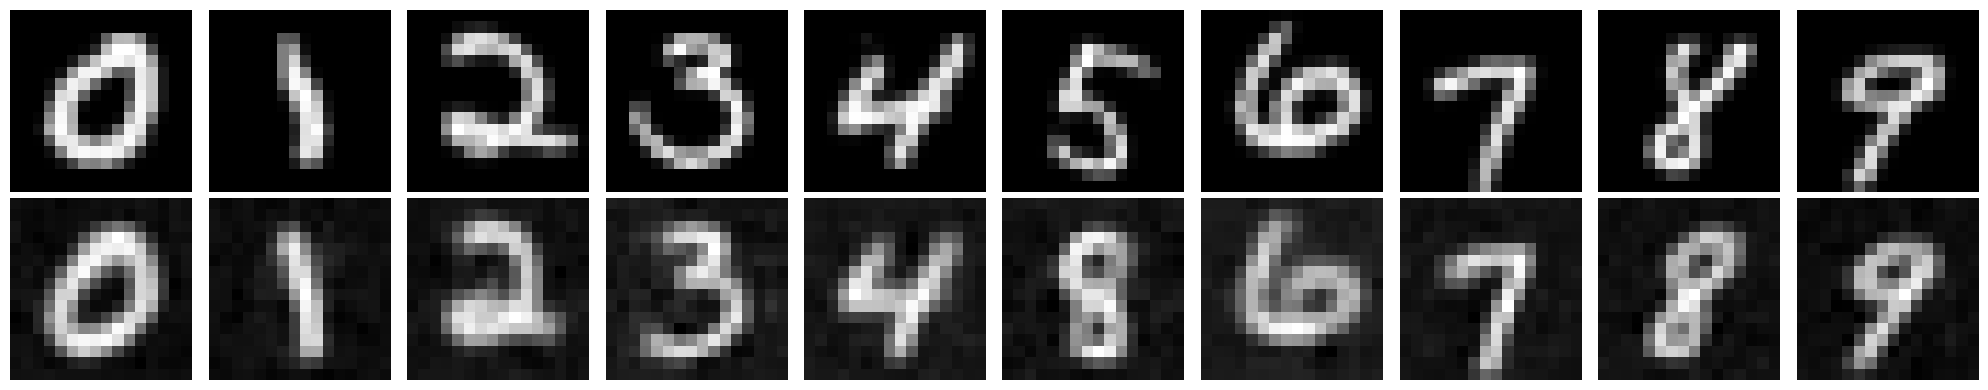

100%|██████████| 375/375 [01:51<00:00,  3.36it/s]


Epoch 45/50, Loss: 0.133446


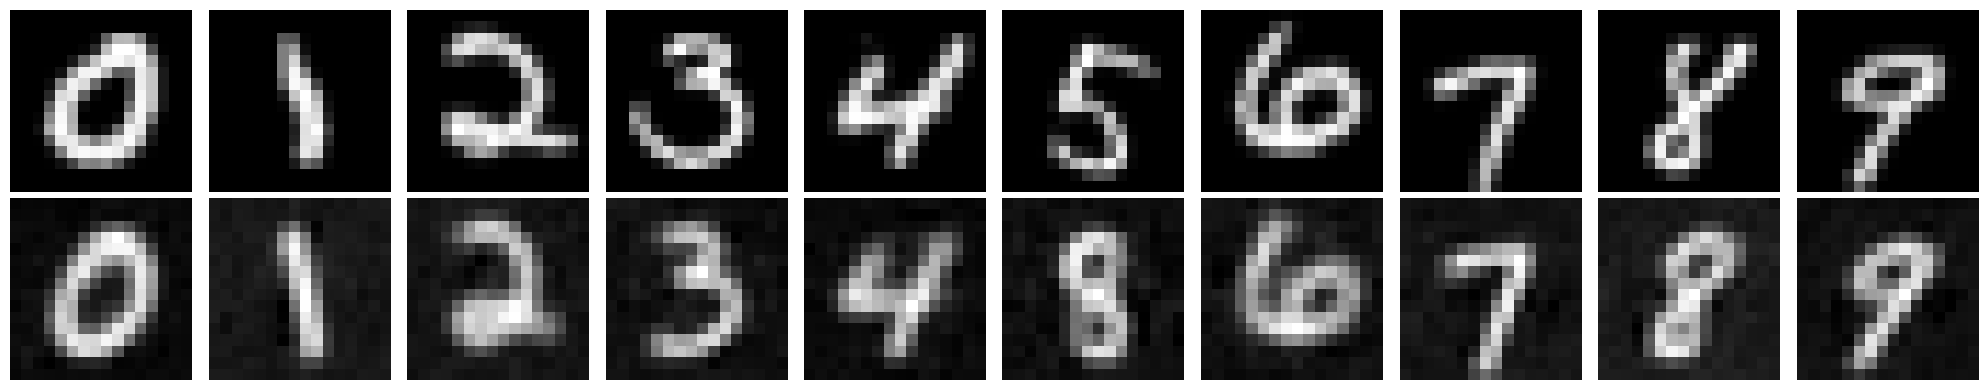

100%|██████████| 375/375 [01:53<00:00,  3.29it/s]


Epoch 46/50, Loss: 0.133050


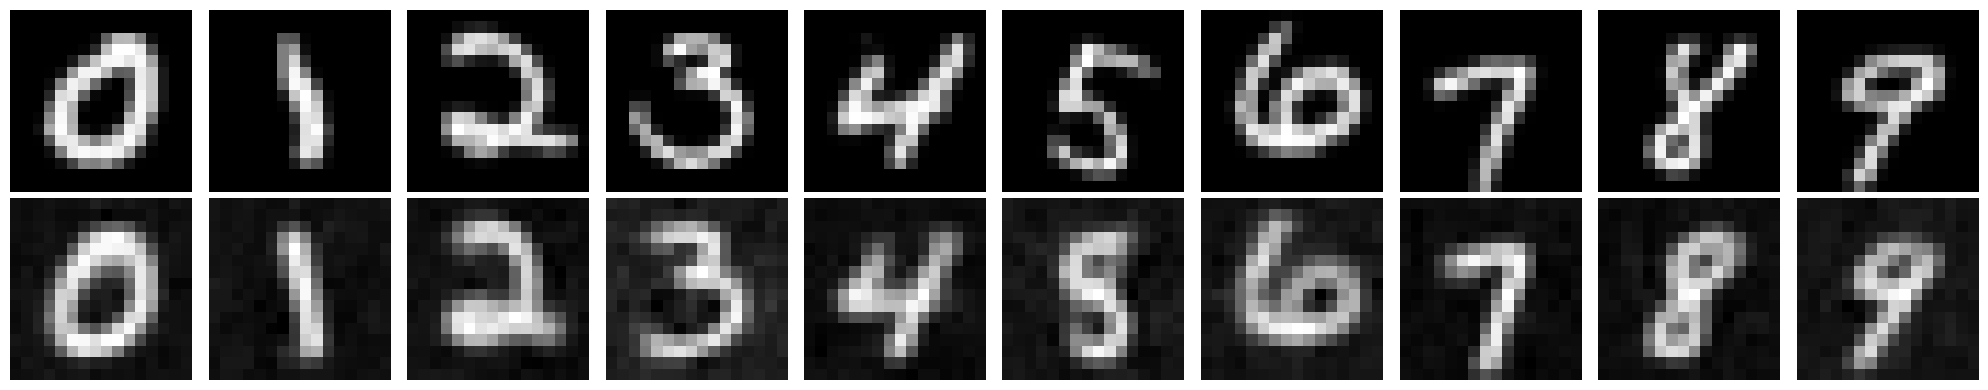

100%|██████████| 375/375 [01:54<00:00,  3.29it/s]


Epoch 47/50, Loss: 0.132116


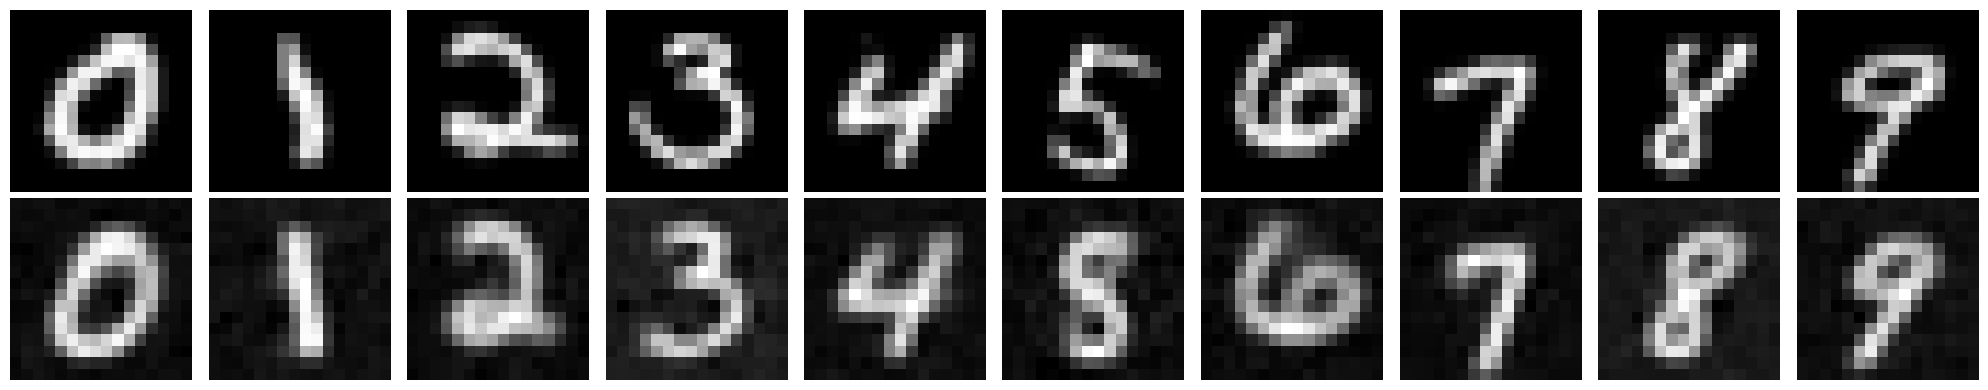

100%|██████████| 375/375 [01:55<00:00,  3.25it/s]


Epoch 48/50, Loss: 0.131411


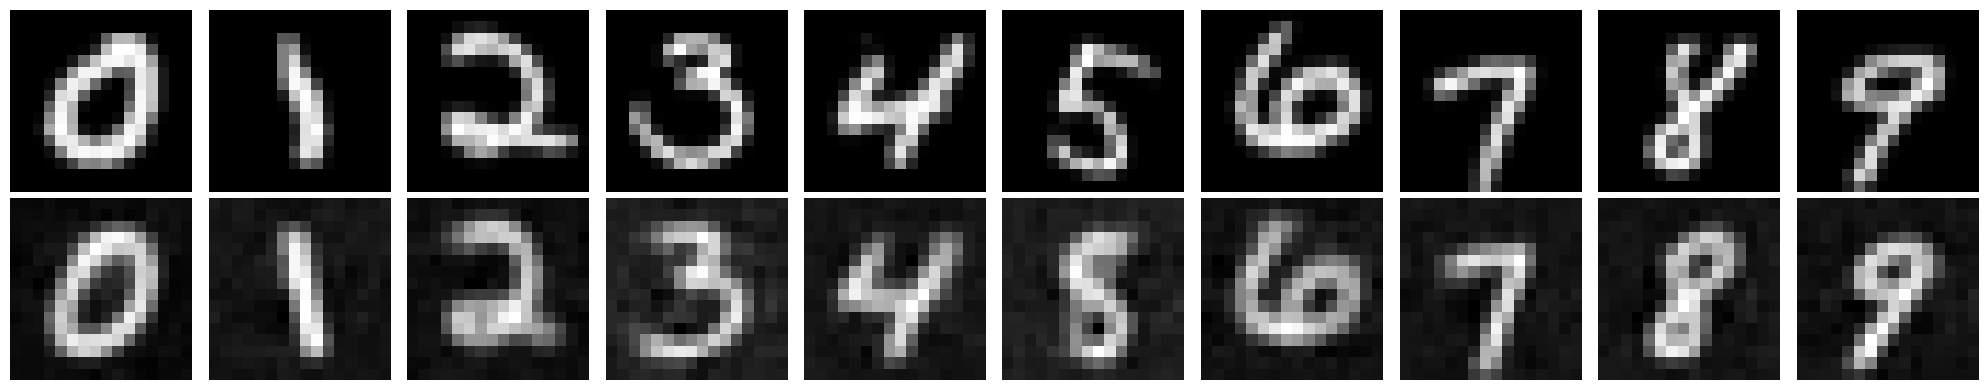

100%|██████████| 375/375 [01:54<00:00,  3.28it/s]


Epoch 49/50, Loss: 0.130526


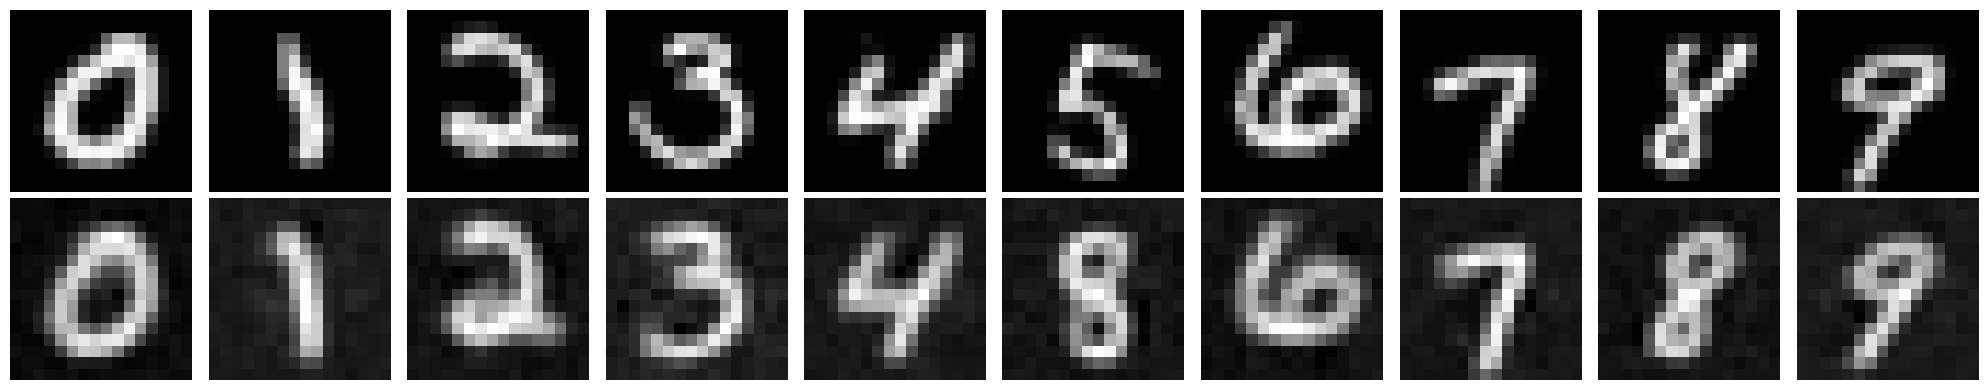

100%|██████████| 375/375 [01:56<00:00,  3.21it/s]


Epoch 50/50, Loss: 0.129826


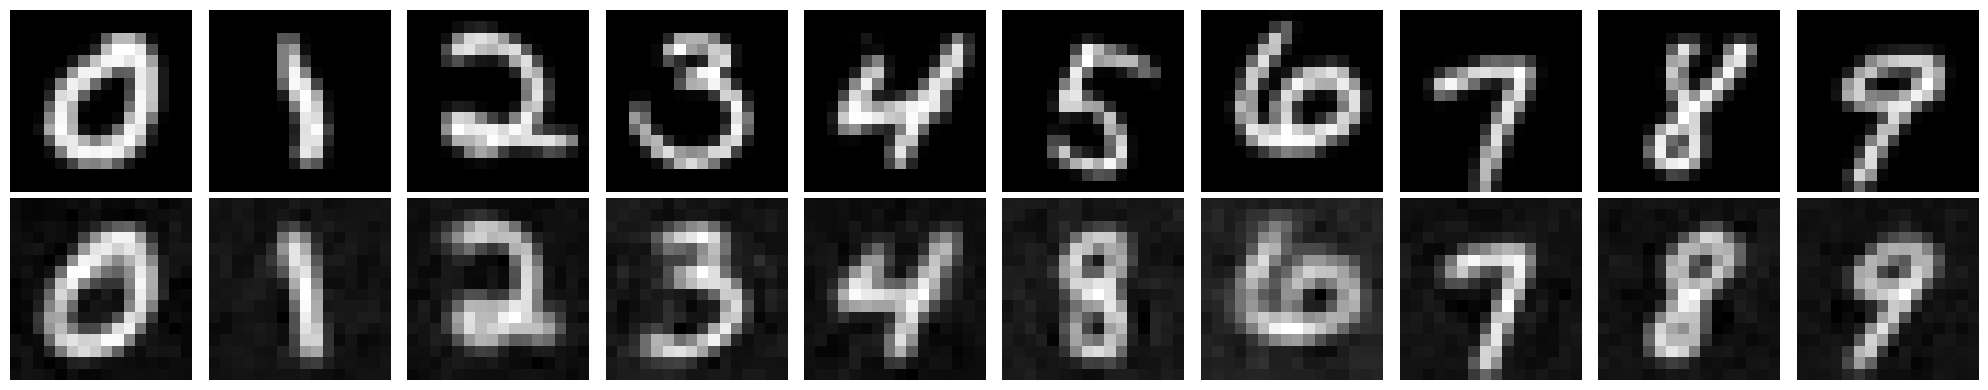

Training completed. Best model saved with loss: 0.1298264688668923


In [13]:
# train or load model for phase 2
phase_2_extension = f"lr_{phase_2_cfg['learning_rate']}_reg_{phase_2_cfg['reg_param']}_hidden_{phase_2_cfg['hidden_channels']}_kernel_{phase_2_cfg['kernel_size']}_flows_{phase_2_cfg['n_flows']}"
checkpoint_dir = os.path.join(results_folder, phase_2_cfg["checkpoint_subdir"], phase_2_extension)
os.makedirs(checkpoint_dir, exist_ok=True)

if phase_2_training:
    start_epoch = 0
    best_loss = float('inf')
    latest_checkpoint = max(
        glob.glob(os.path.join(checkpoint_dir, "epoch_*_model.pth")),
        default=None,
        key=os.path.getctime,
    )

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        diffeo_decoder_trainer.phi.load_state_dict(checkpoint["model_state_dict"])
        diffeo_decoder_trainer.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        best_loss = checkpoint["best_loss"]

    phase_2_train(
        diffeo_decoder_trainer,
        train_loader,
        save_dir=checkpoint_dir,
        n_epochs=phase_2_cfg["num_epochs"],
        start_epoch=start_epoch,
        best_loss=best_loss,
    )
else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    checkpoint = torch.load(best_model_path, map_location=device)
    diffeo_decoder_trainer.phi.load_state_dict(checkpoint["model_state_dict"])

phi = diffeo_decoder_trainer.phi

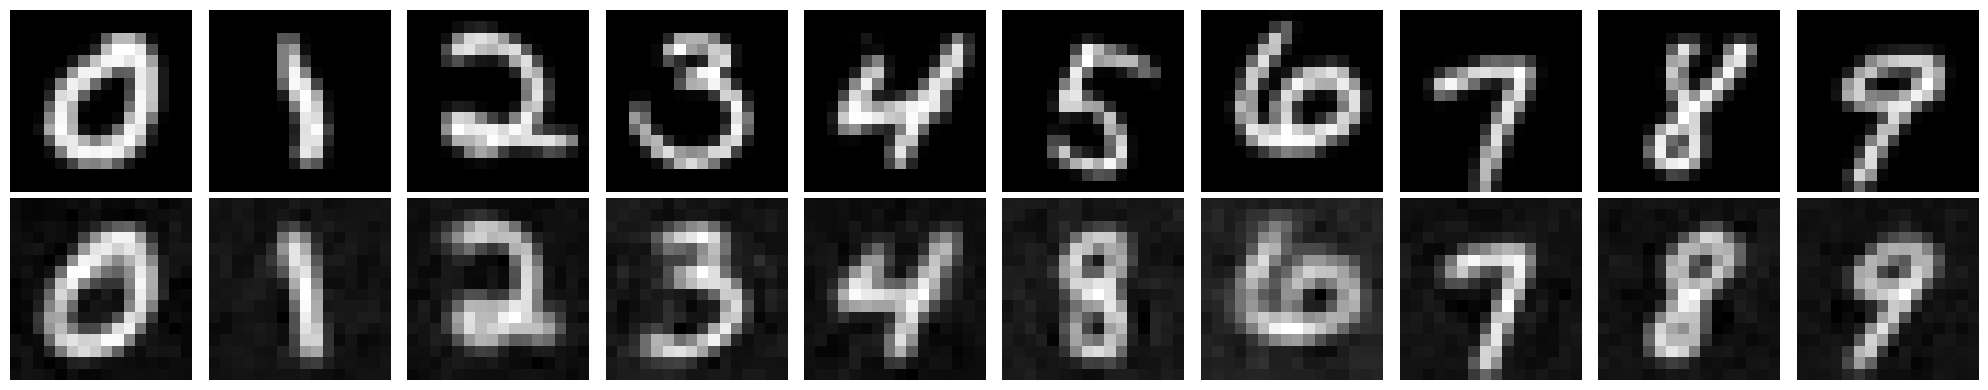

In [14]:
with torch.no_grad():
    emb_x = emb(cluster_images.to(device))  # N x emb.d
    log_0_emb_x = emb.poincare_map.inverse(emb_x)  # N x emb.d
    p_x = torch.zeros((cluster_images.shape[0], phi.d), device=device, dtype=cluster_images.dtype)  # N x d
    p_x[:, :emb.d] = log_0_emb_x
    rec_cluster_images = phi.inverse(p_x.reshape(cluster_images.shape)).cpu().reshape(cluster_images.shape)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(cluster_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')
    axes[i+10].imshow(rec_cluster_images[i].squeeze(), cmap='gray')
    axes[i+10].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,f"stage_2_recon_post_training.png"))
plt.show()
    

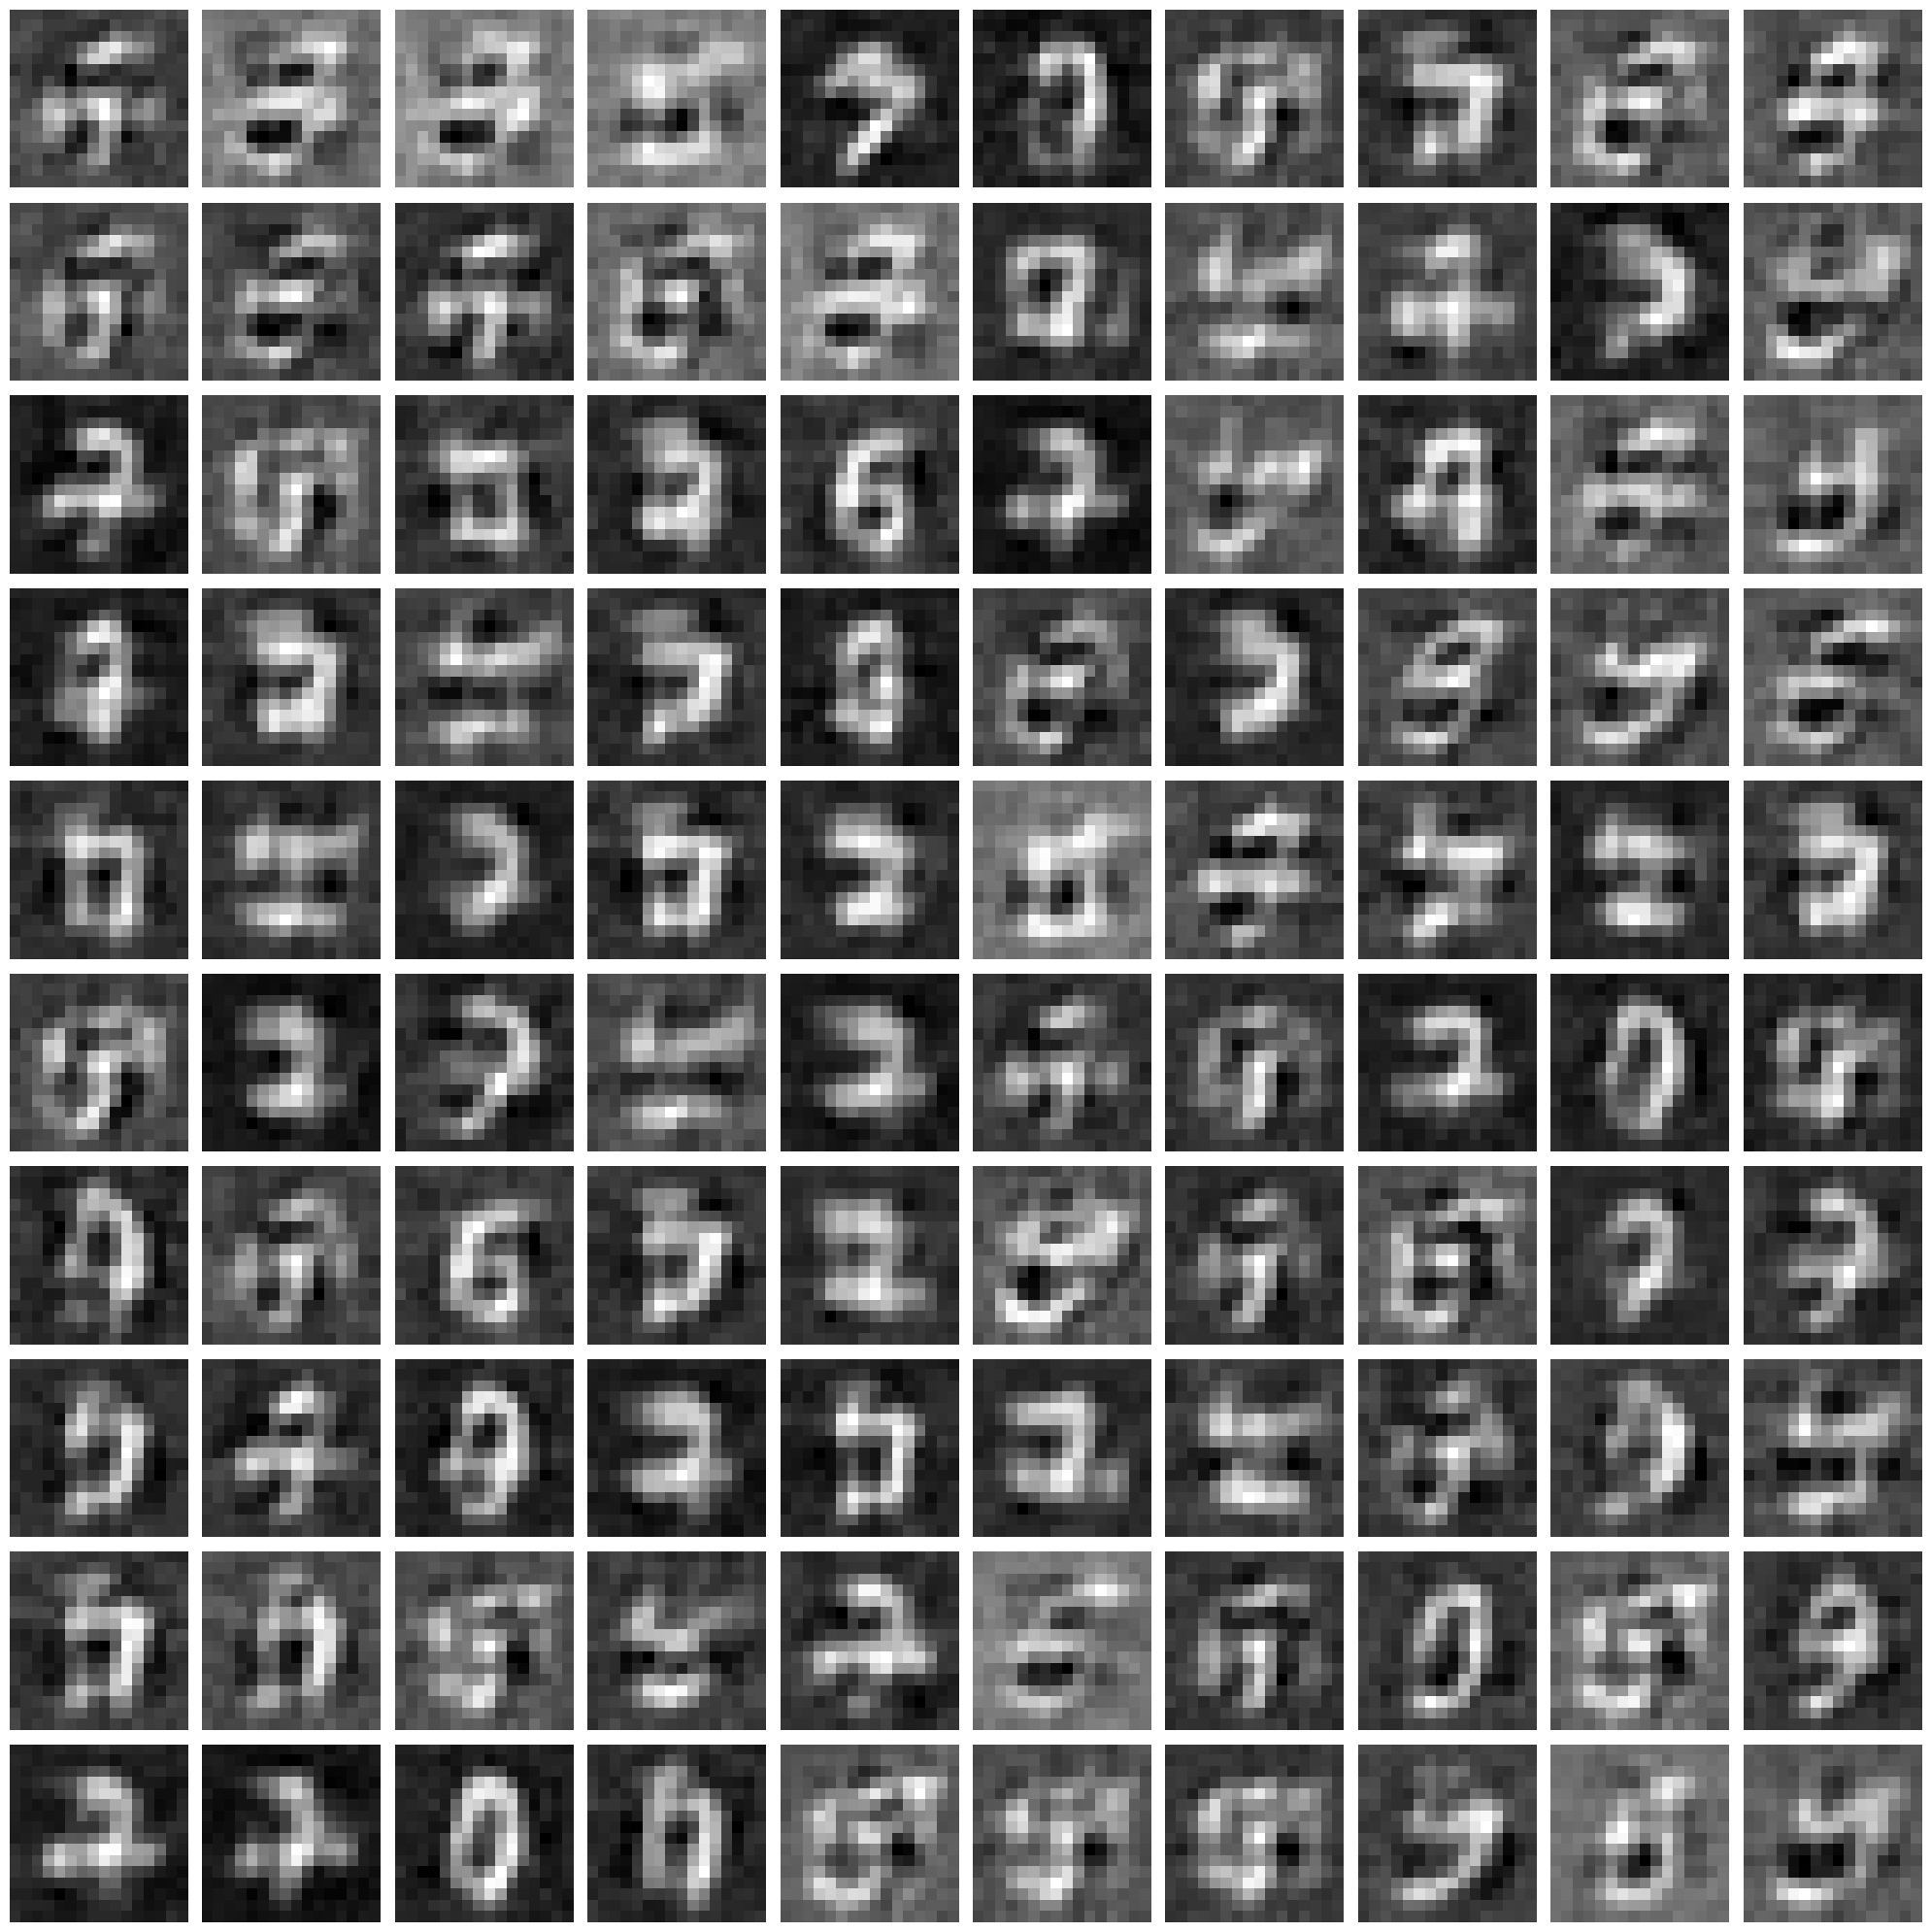

In [15]:
# compute eig train embeddings normalized covariance
Lambda, U = torch.linalg.eigh(train_embeddings_centered.T @ train_embeddings_centered / train_embeddings_centered.shape[0])

with torch.no_grad():
    latent_samples = torch.randn(100, latent_dim) @ U * Lambda.sqrt()  # sample from standard normal in latent space
    phi_x_samples = torch.zeros(100, size * size)  # placeholder for conditioning variable, not used in this case
    phi_x_samples[:,:latent_dim] = latent_samples  # set the first two dimensions to the sampled latent variables
    samples = diffeo_decoder_trainer.phi.inverse(phi_x_samples.reshape(100, 1, size, size).to(device)).cpu()  # decode the samples through the learned diffeomorphism

# plot samples
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten()
for i in range(100):
    axes[i].imshow(samples[i,0], cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,f"stage_2_samples_post_training.png"))
plt.show()

In [16]:
# construct manifold from learned diffeomorphism
phi_manifold = StandardPullbackImageEuclidean(phi)
# construct iso_manifold 
# iso_manifold = l2IsometrizedImageEuclidean(manifold)

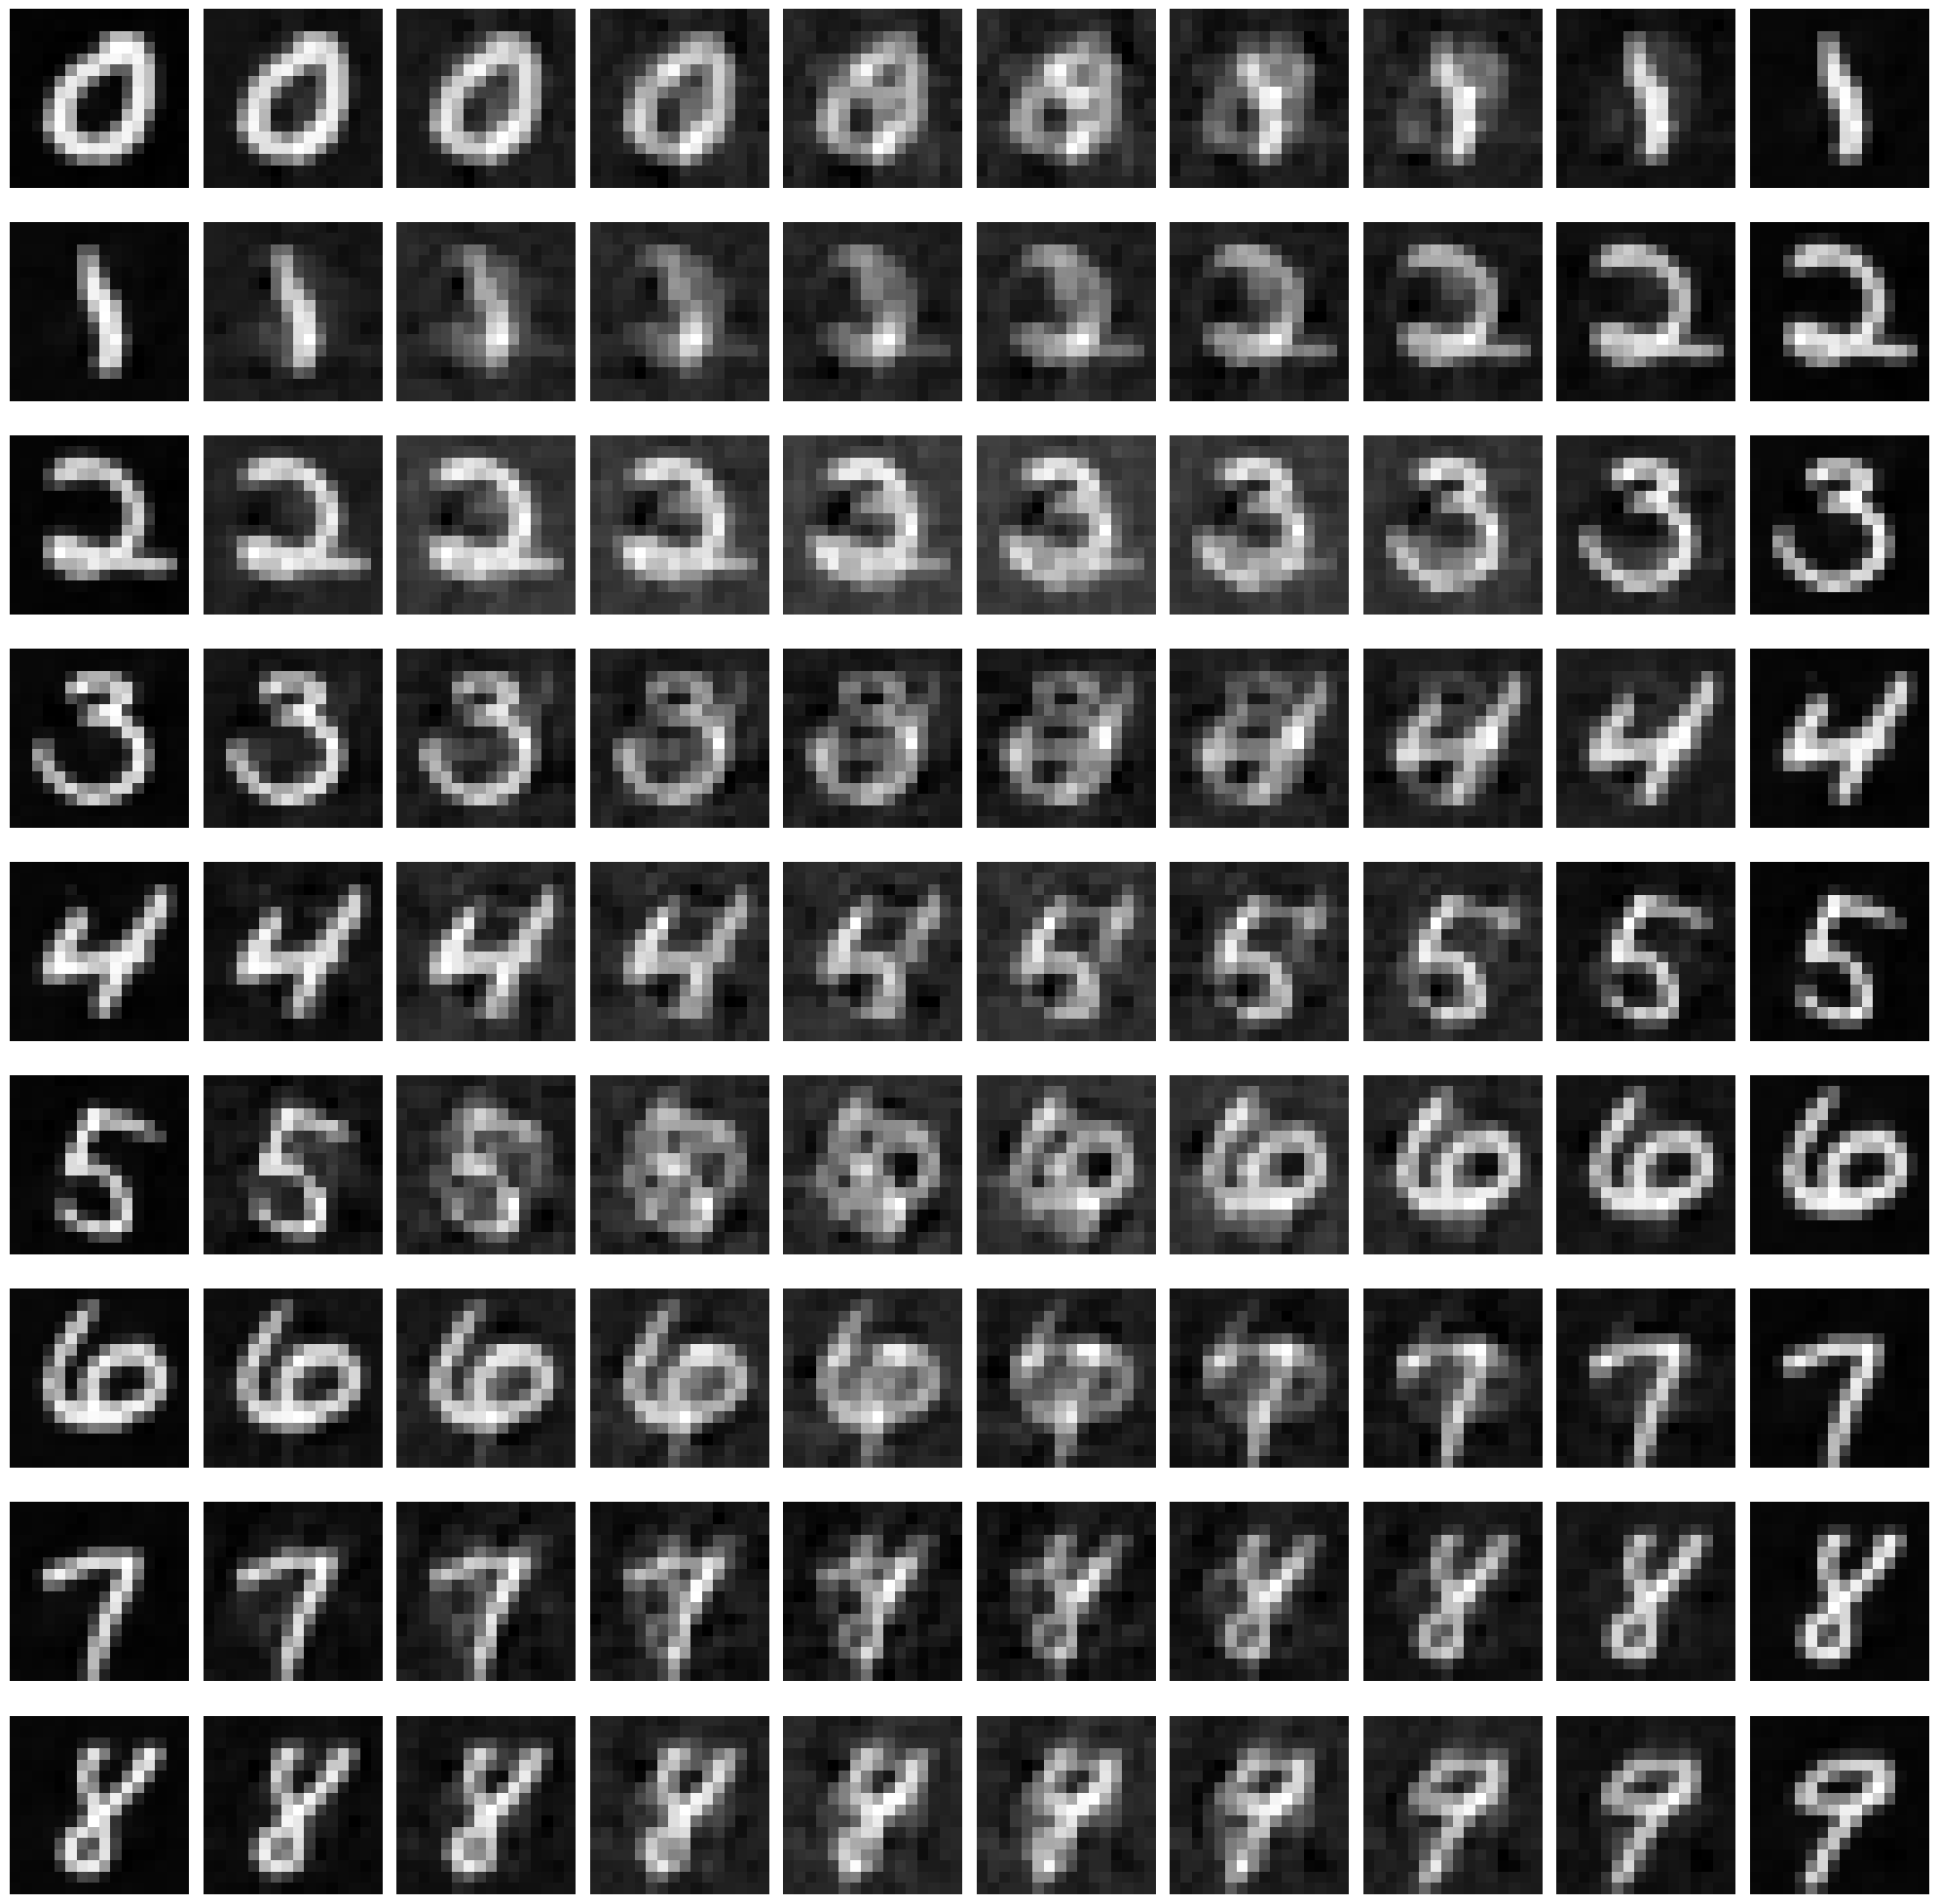

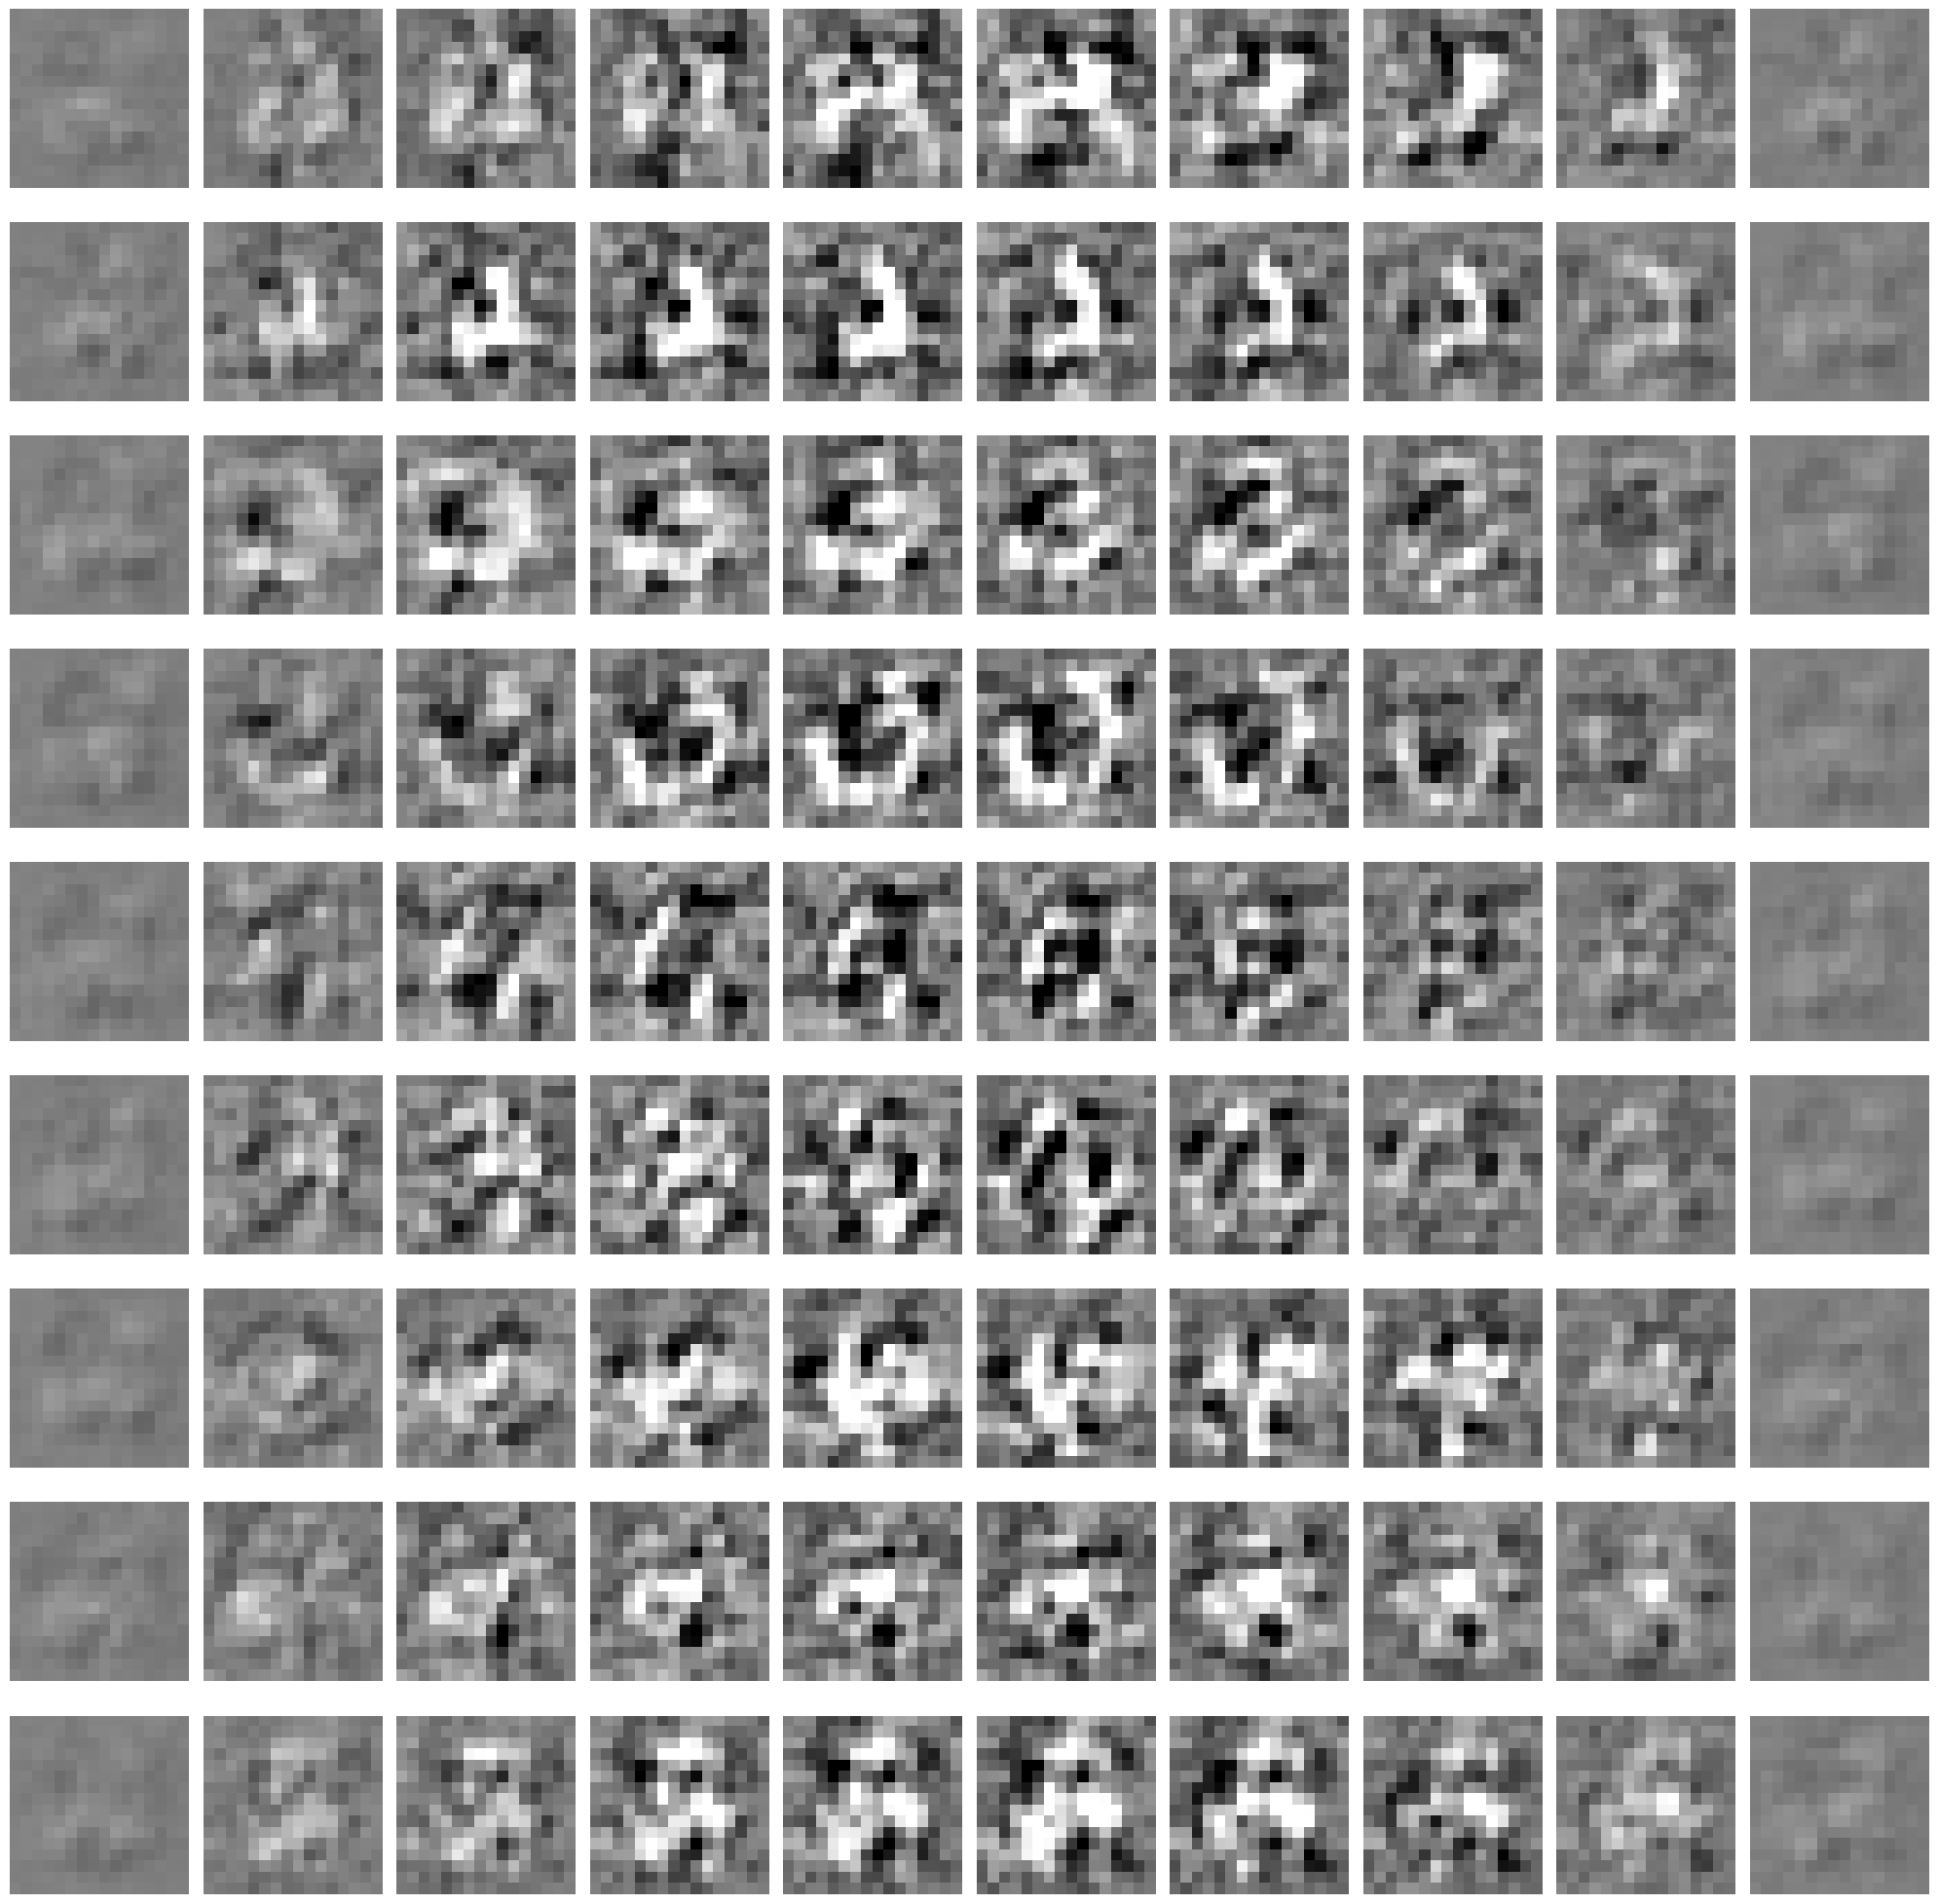

In [17]:
# compute geodesics between all pairs of points
K = 10
t = torch.linspace(0, 1, steps=K)
with torch.no_grad():
    phi_geodesics = phi_manifold.geodesic(cluster_images[None].to(device), cluster_images[None].to(device), t.to(device)).cpu()  # shape: [1, 9, 10, K, 1, H, W]

# linear interpolation in pixel space for comparison
interpolations = []
for i in range(10-1):
    start = cluster_images[i]
    end = cluster_images[i+1]
    interp = torch.stack([start * (1 - alpha) + end * alpha for alpha in t], dim=0)
    interpolations.append(interp)
interpolations = torch.stack(interpolations, dim=0)  # shape: [9, K, 1, H, W]

# plot geodesics
# plot cluster images
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K):
        axes[i*K + k].imshow(phi_geodesics[0, i, i+1, k, 0], cmap='gray')
        axes[i*K + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_2_data_geodesics.png"))
plt.show()

# plot difference with interpolations
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K): # have same color scale for all plots
        axes[i*K + k].imshow(phi_geodesics[0, i, i+1, k, 0] - interpolations[i, k, 0], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[i*K + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_2_data_interpolation_difference.png"))
plt.show()

### Stage 3: Learn a Star Gaussian Distribution ###

In [18]:
# construct bimodal Star Gaussian 
num_radials = phase_3_cfg["num_radials"]
star_gaussian_trainer = LatentStarGaussianTraining(
    emb, 
    MultiInverseLinearStarNormGaussianDistribution(
        latent_dim, 
        num_radials=num_radials
        ).to(device), 
    lr=phase_3_cfg["learning_rate"],
    )

In [19]:
# construct train loop
def phase_3_train(trainer, train_loader, save_dir, n_epochs, start_epoch=0, best_loss=float('inf')):
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        for (x, _), _ in tqdm(train_loader):
            x = x.to(device, non_blocking=True)
            loss = trainer.train_step(x)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(train_pair_dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': trainer.star.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_loss,
        }
        
        torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [20]:
# train or load model for phase 3
phase_3_extension = f"lr_{phase_3_cfg['learning_rate']}_radials_{phase_3_cfg['num_radials']}"
checkpoint_dir = os.path.join(results_folder, phase_3_cfg["checkpoint_subdir"], phase_3_extension)
os.makedirs(checkpoint_dir, exist_ok=True)

if phase_3_training:
    start_epoch = 0
    best_loss = float('inf')
    latest_checkpoint = max(
        glob.glob(os.path.join(checkpoint_dir, "epoch_*_model.pth")),
        default=None,
        key=os.path.getctime,
    )

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        star_gaussian_trainer.star.load_state_dict(checkpoint["model_state_dict"])
        star_gaussian_trainer.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        best_loss = checkpoint["best_loss"]

    phase_3_train(
        star_gaussian_trainer,
        train_loader,
        save_dir=checkpoint_dir,
        n_epochs=phase_3_cfg["num_epochs"],
        start_epoch=start_epoch,
        best_loss=best_loss,
    )
else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    checkpoint = torch.load(best_model_path, map_location=device)
    star_gaussian_trainer.star.load_state_dict(checkpoint["model_state_dict"])

psi = star_gaussian_trainer.psi(in_channels * height * width)
to_vec = ToVecImageDiffeomorphism(in_channels, height, width)
to_img = ToImgVectorDiffeomorphism(in_channels, height, width)
phi_psi = ImageCompositionDiffeomorphism([phi, to_vec, psi, to_img], in_channels, height, width) 

star_gaussian = star_gaussian_trainer.star

/tmp/ipykernel_61314/4011934132.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location=device)


FileNotFoundError: [Errno 2] No such file or directory: 'results/mnist/four_phases/16x16/latent_20/checkpoints_phase_3/lr_0.01_radials_10/best_model.pth'

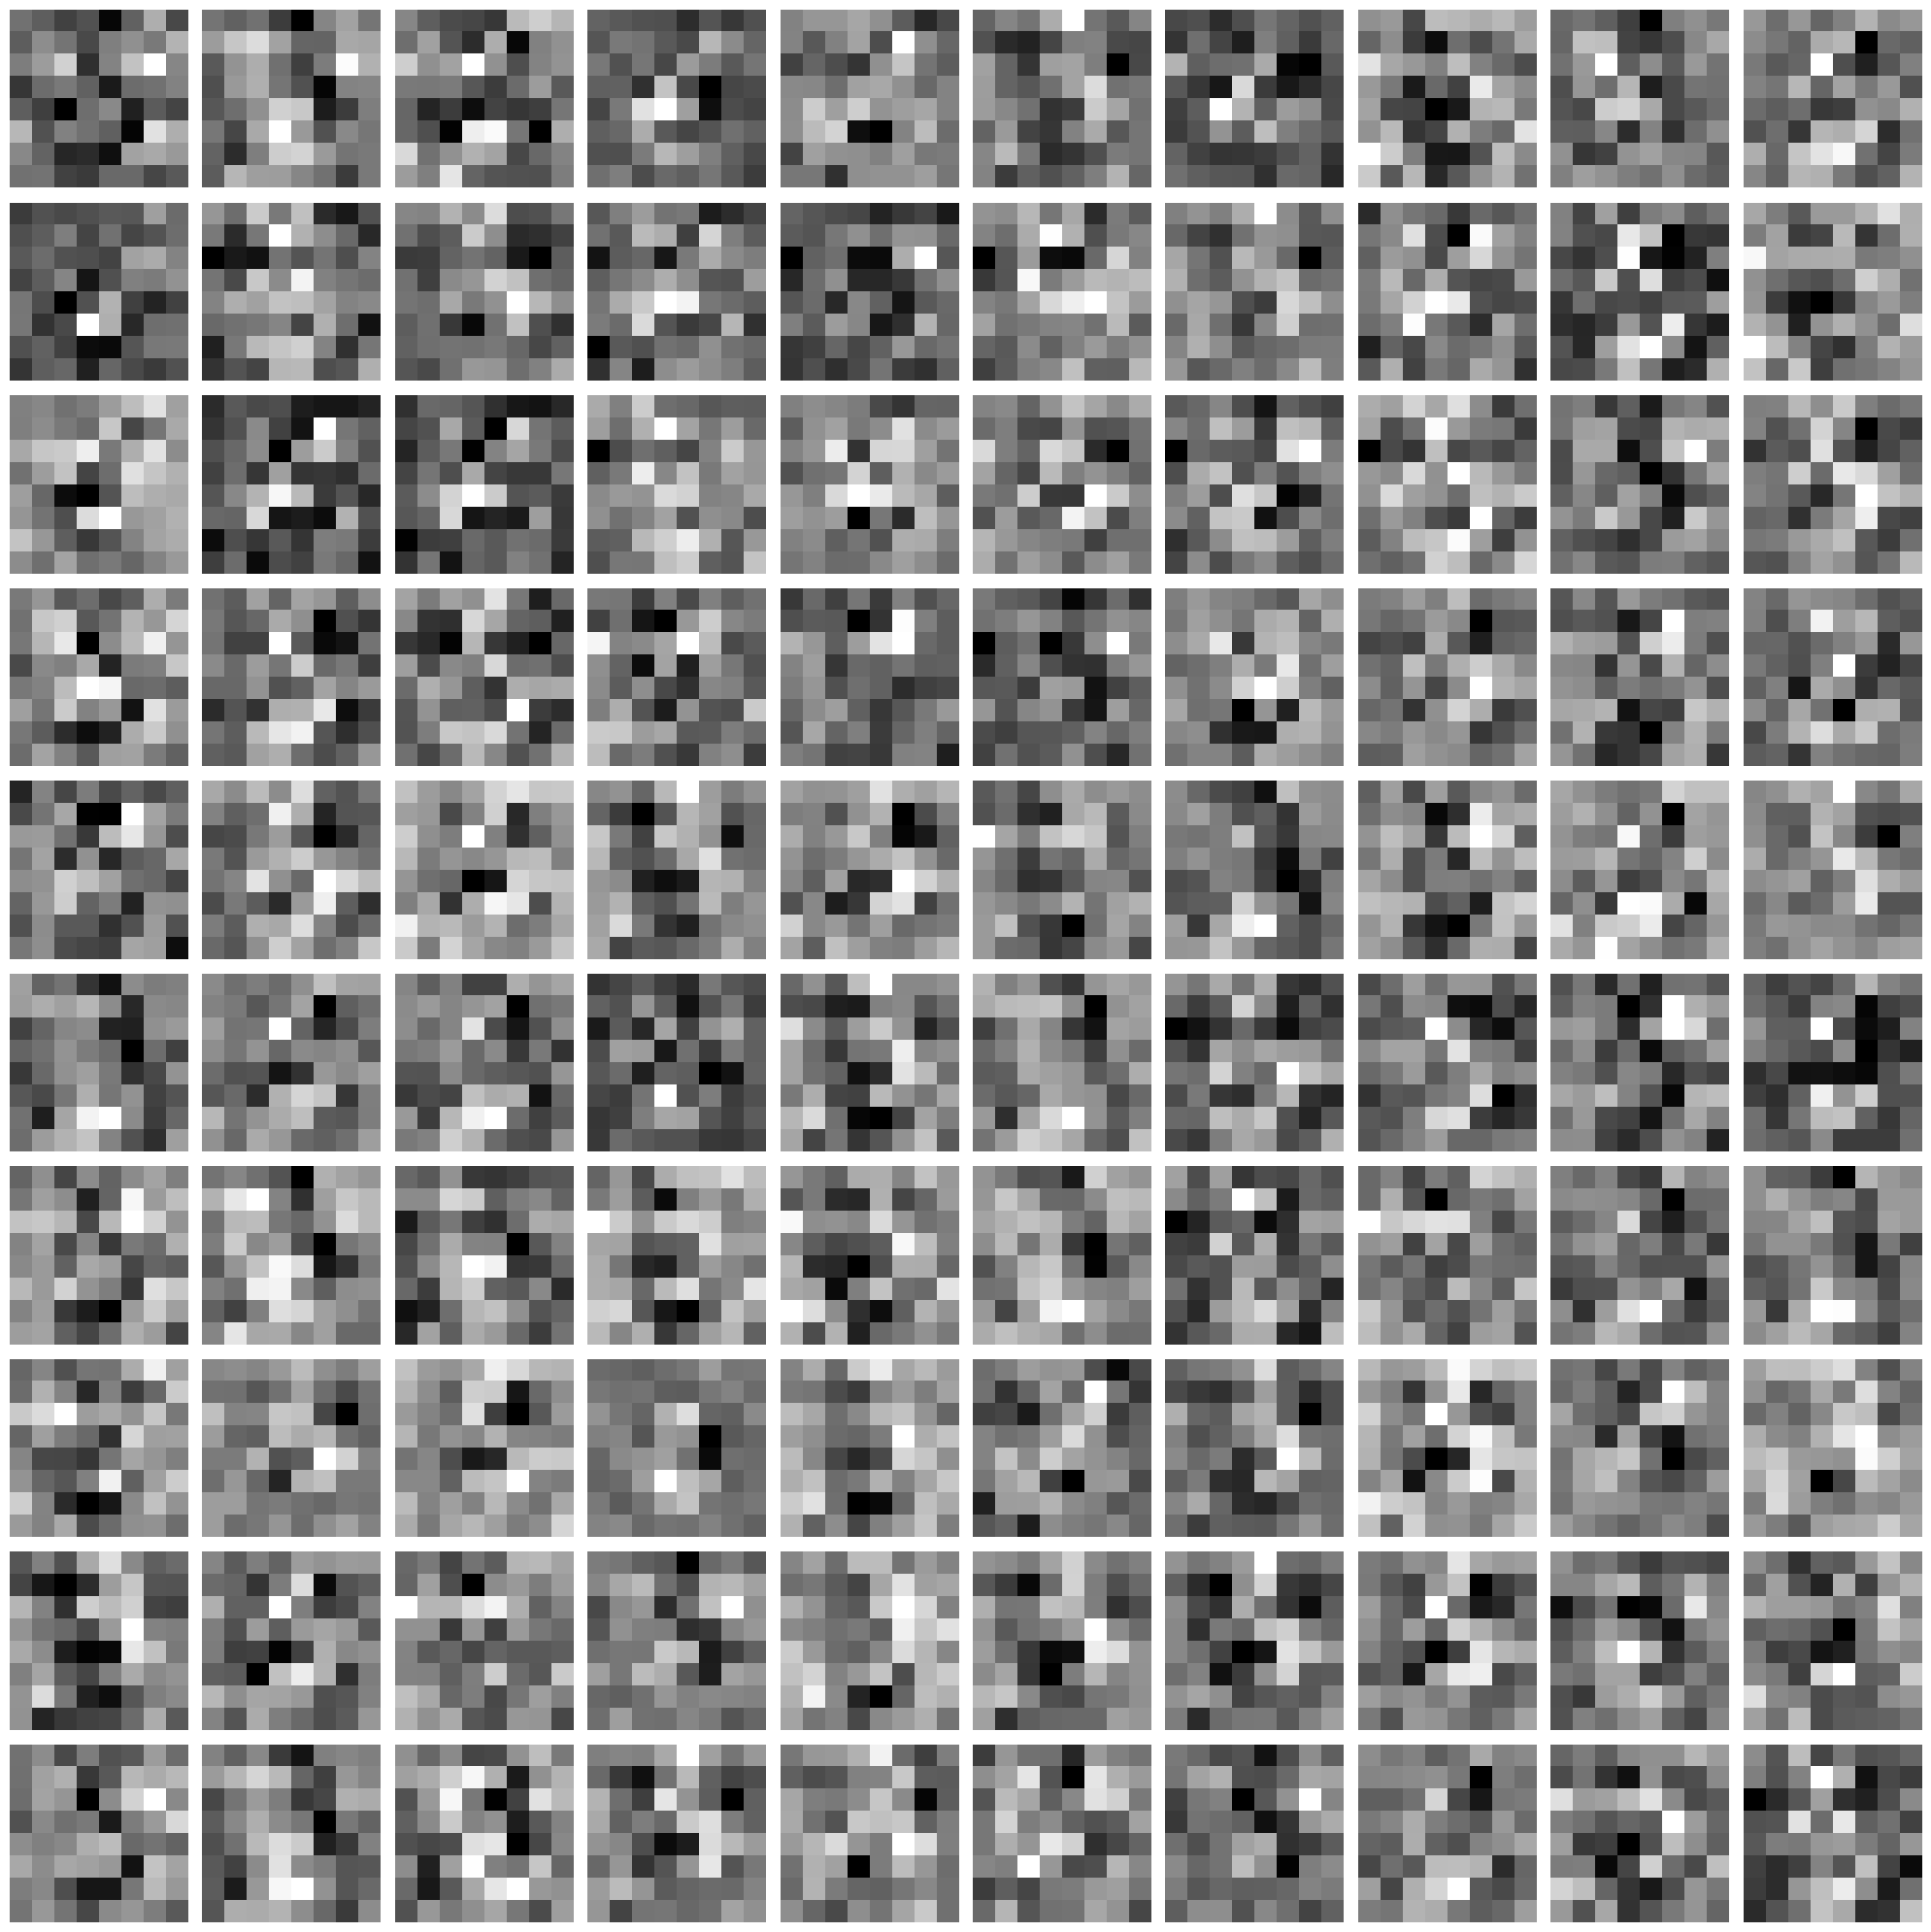

In [ ]:
with torch.no_grad():
    latent_samples = star_gaussian_trainer.star.sample(100)
    phi_x_samples = torch.zeros(100, size * size)  # placeholder for conditioning variable, not used in this case
    phi_x_samples[:,:latent_dim] = latent_samples  # set the first two dimensions to the sampled latent variables
    samples = phi.inverse(phi_x_samples.reshape(100, 1, size, size).to(device)).cpu()  # decode the samples through the learned diffeomorphism

# plot samples
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten()
for i in range(100):
    axes[i].imshow(samples[i,0], cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,f"stage_3_samples_post_training.png"))
plt.show()

In [ ]:
# construct manifold from learned flow
phi_psi_manifold = StandardPullbackImageEuclidean(phi_psi)
# construct iso_manifold 
# iso_phi_psi_manifold = l2IsometrizedImageEuclidean(phi_psi_manifold)

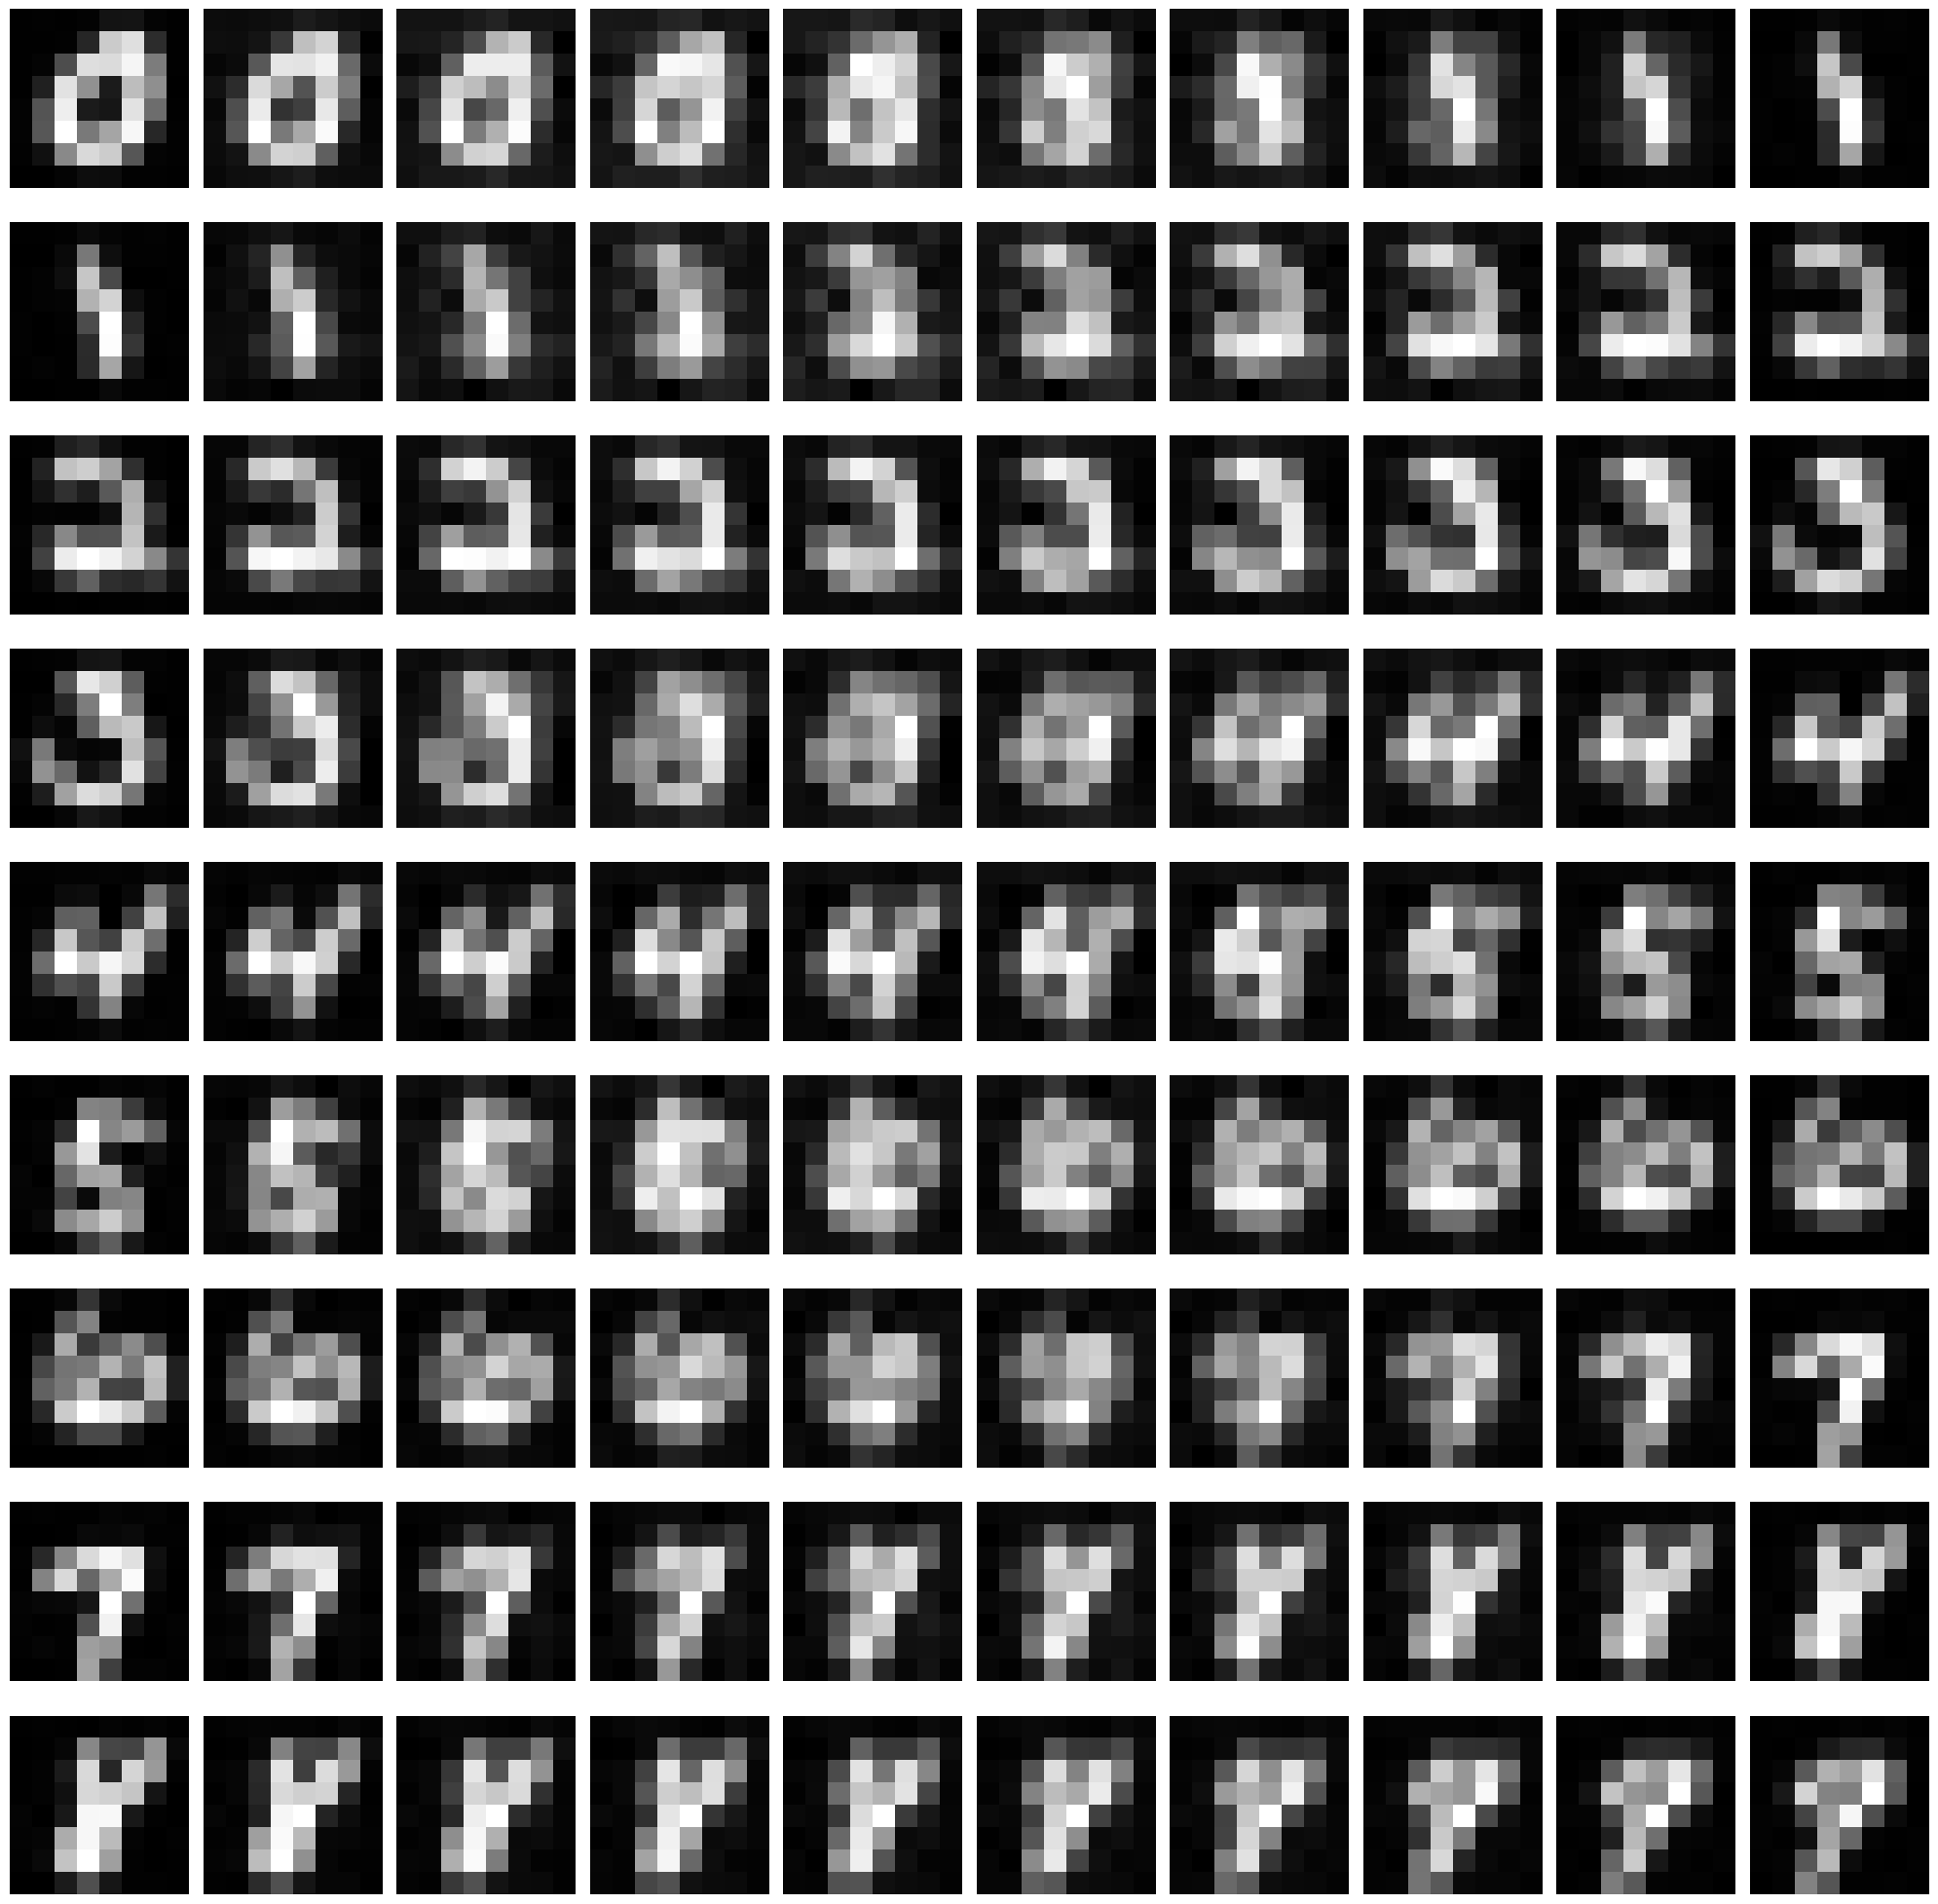

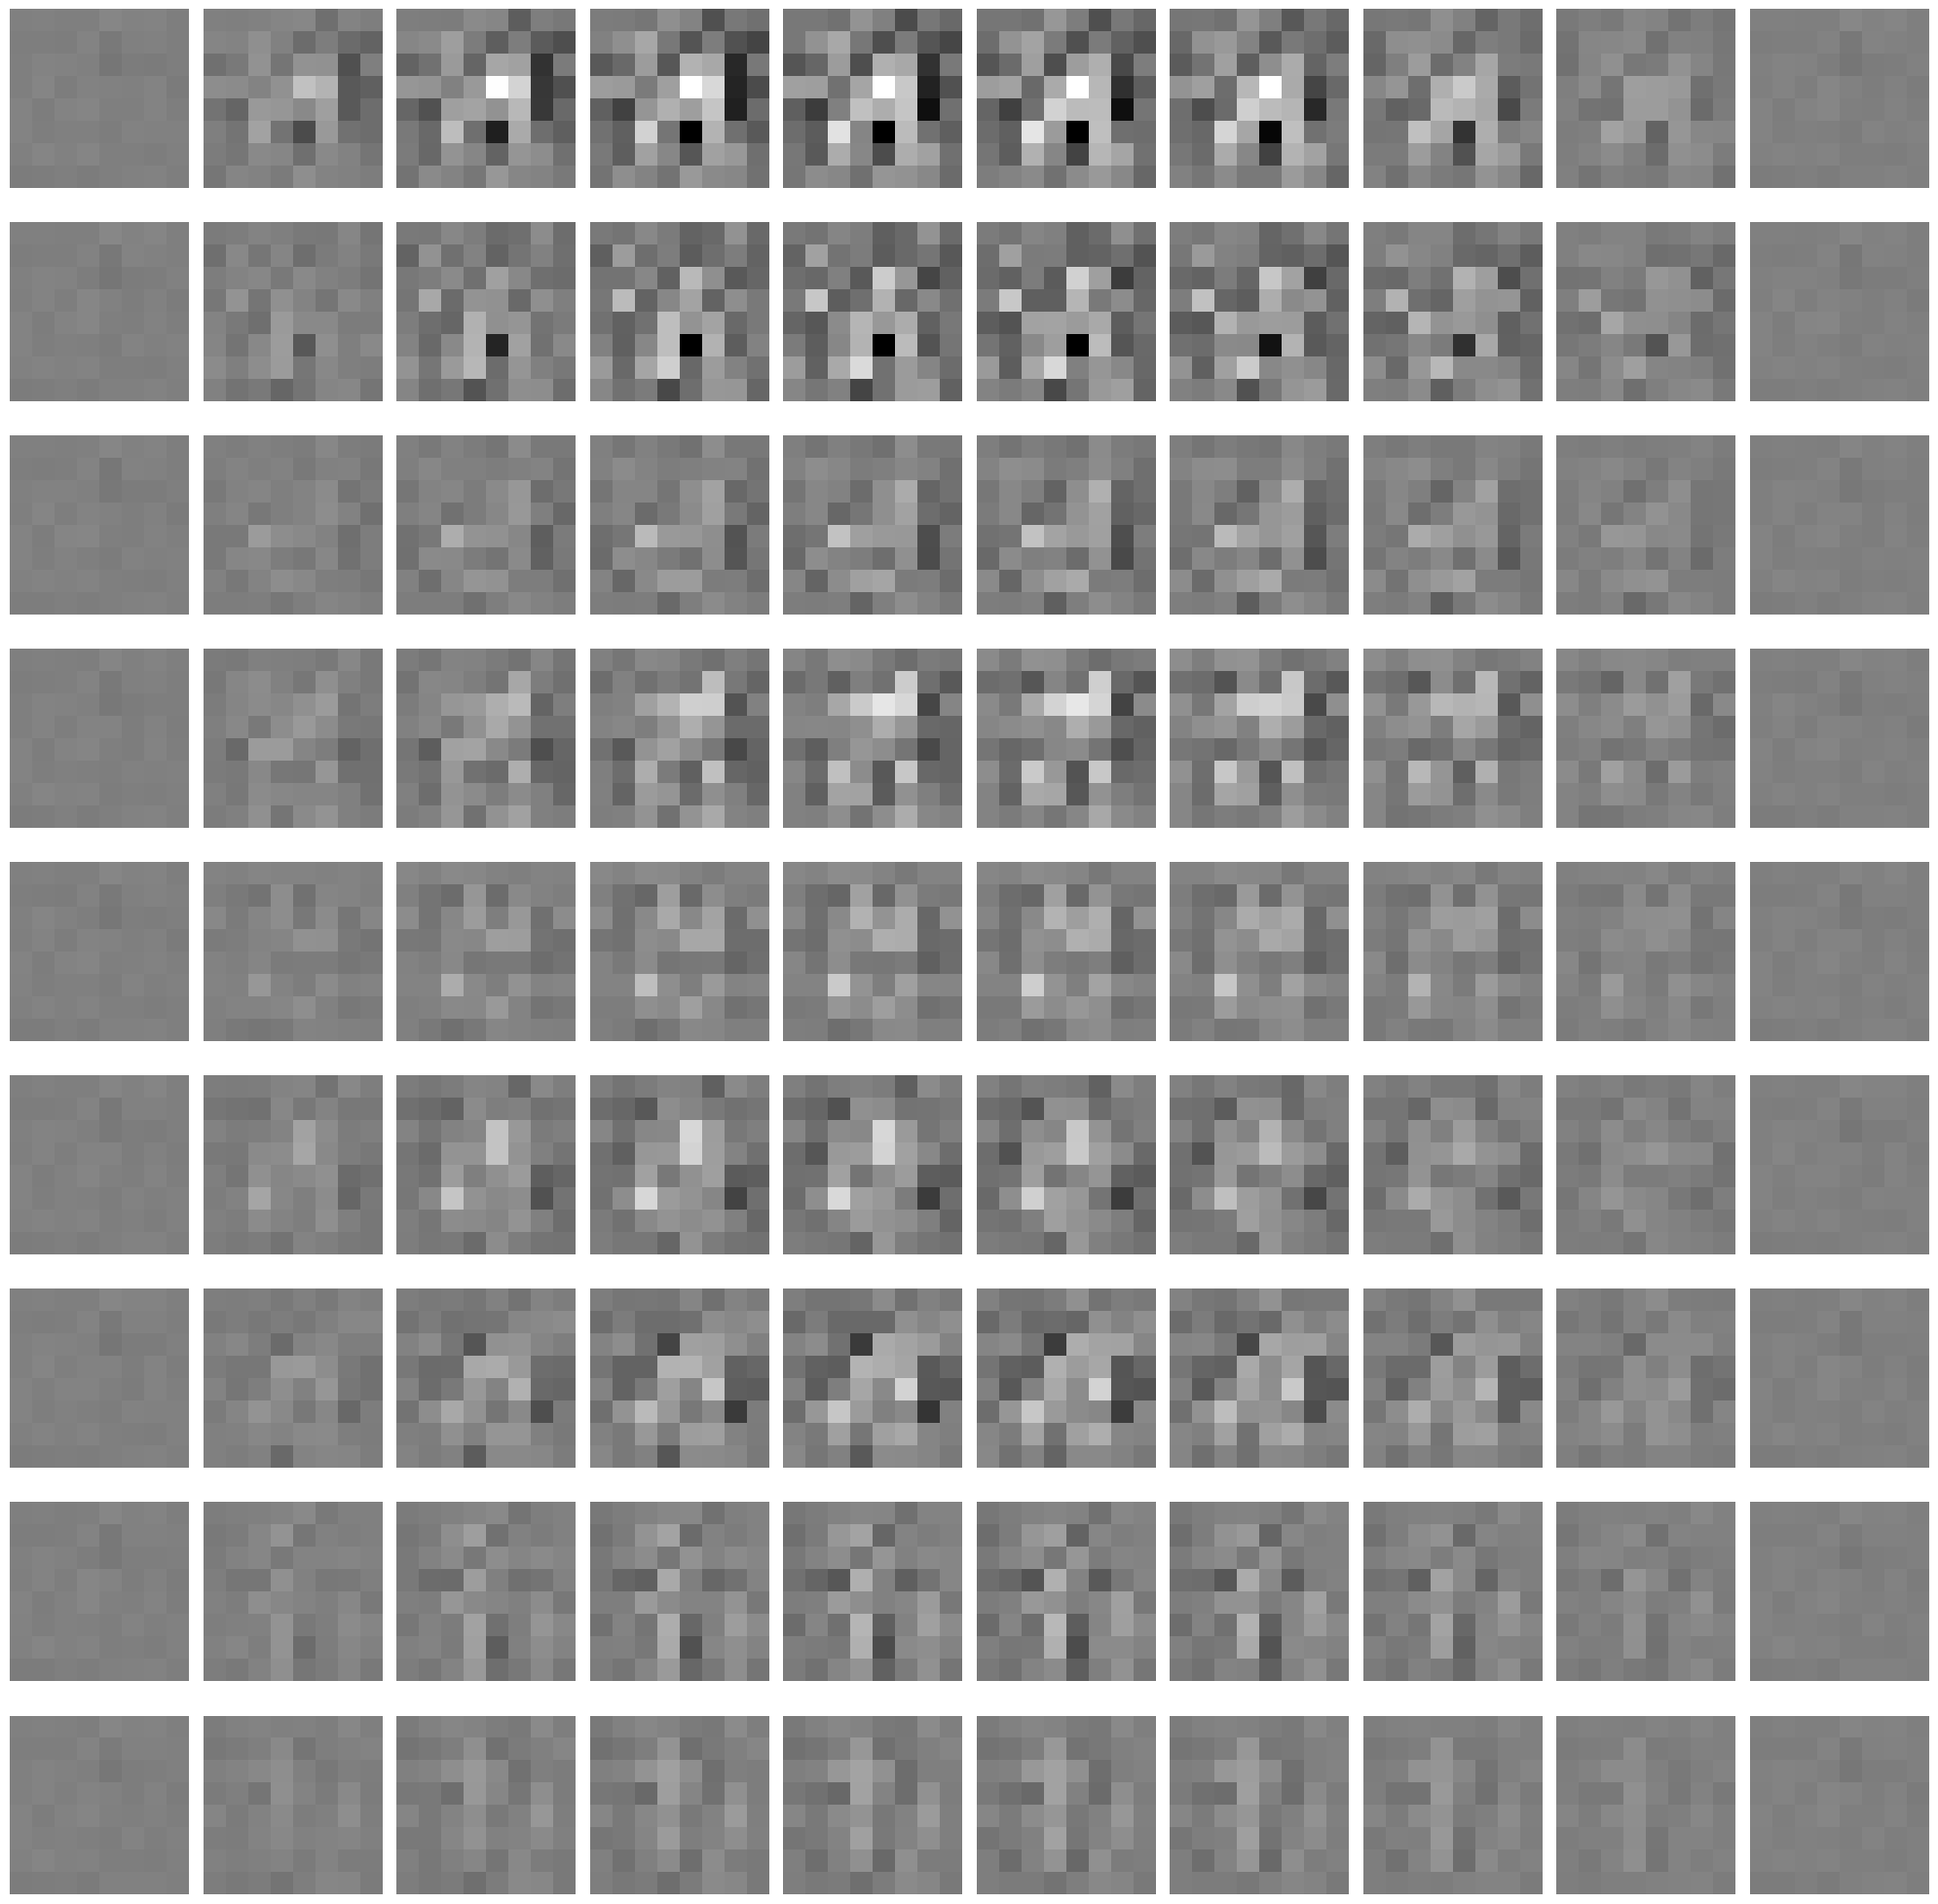

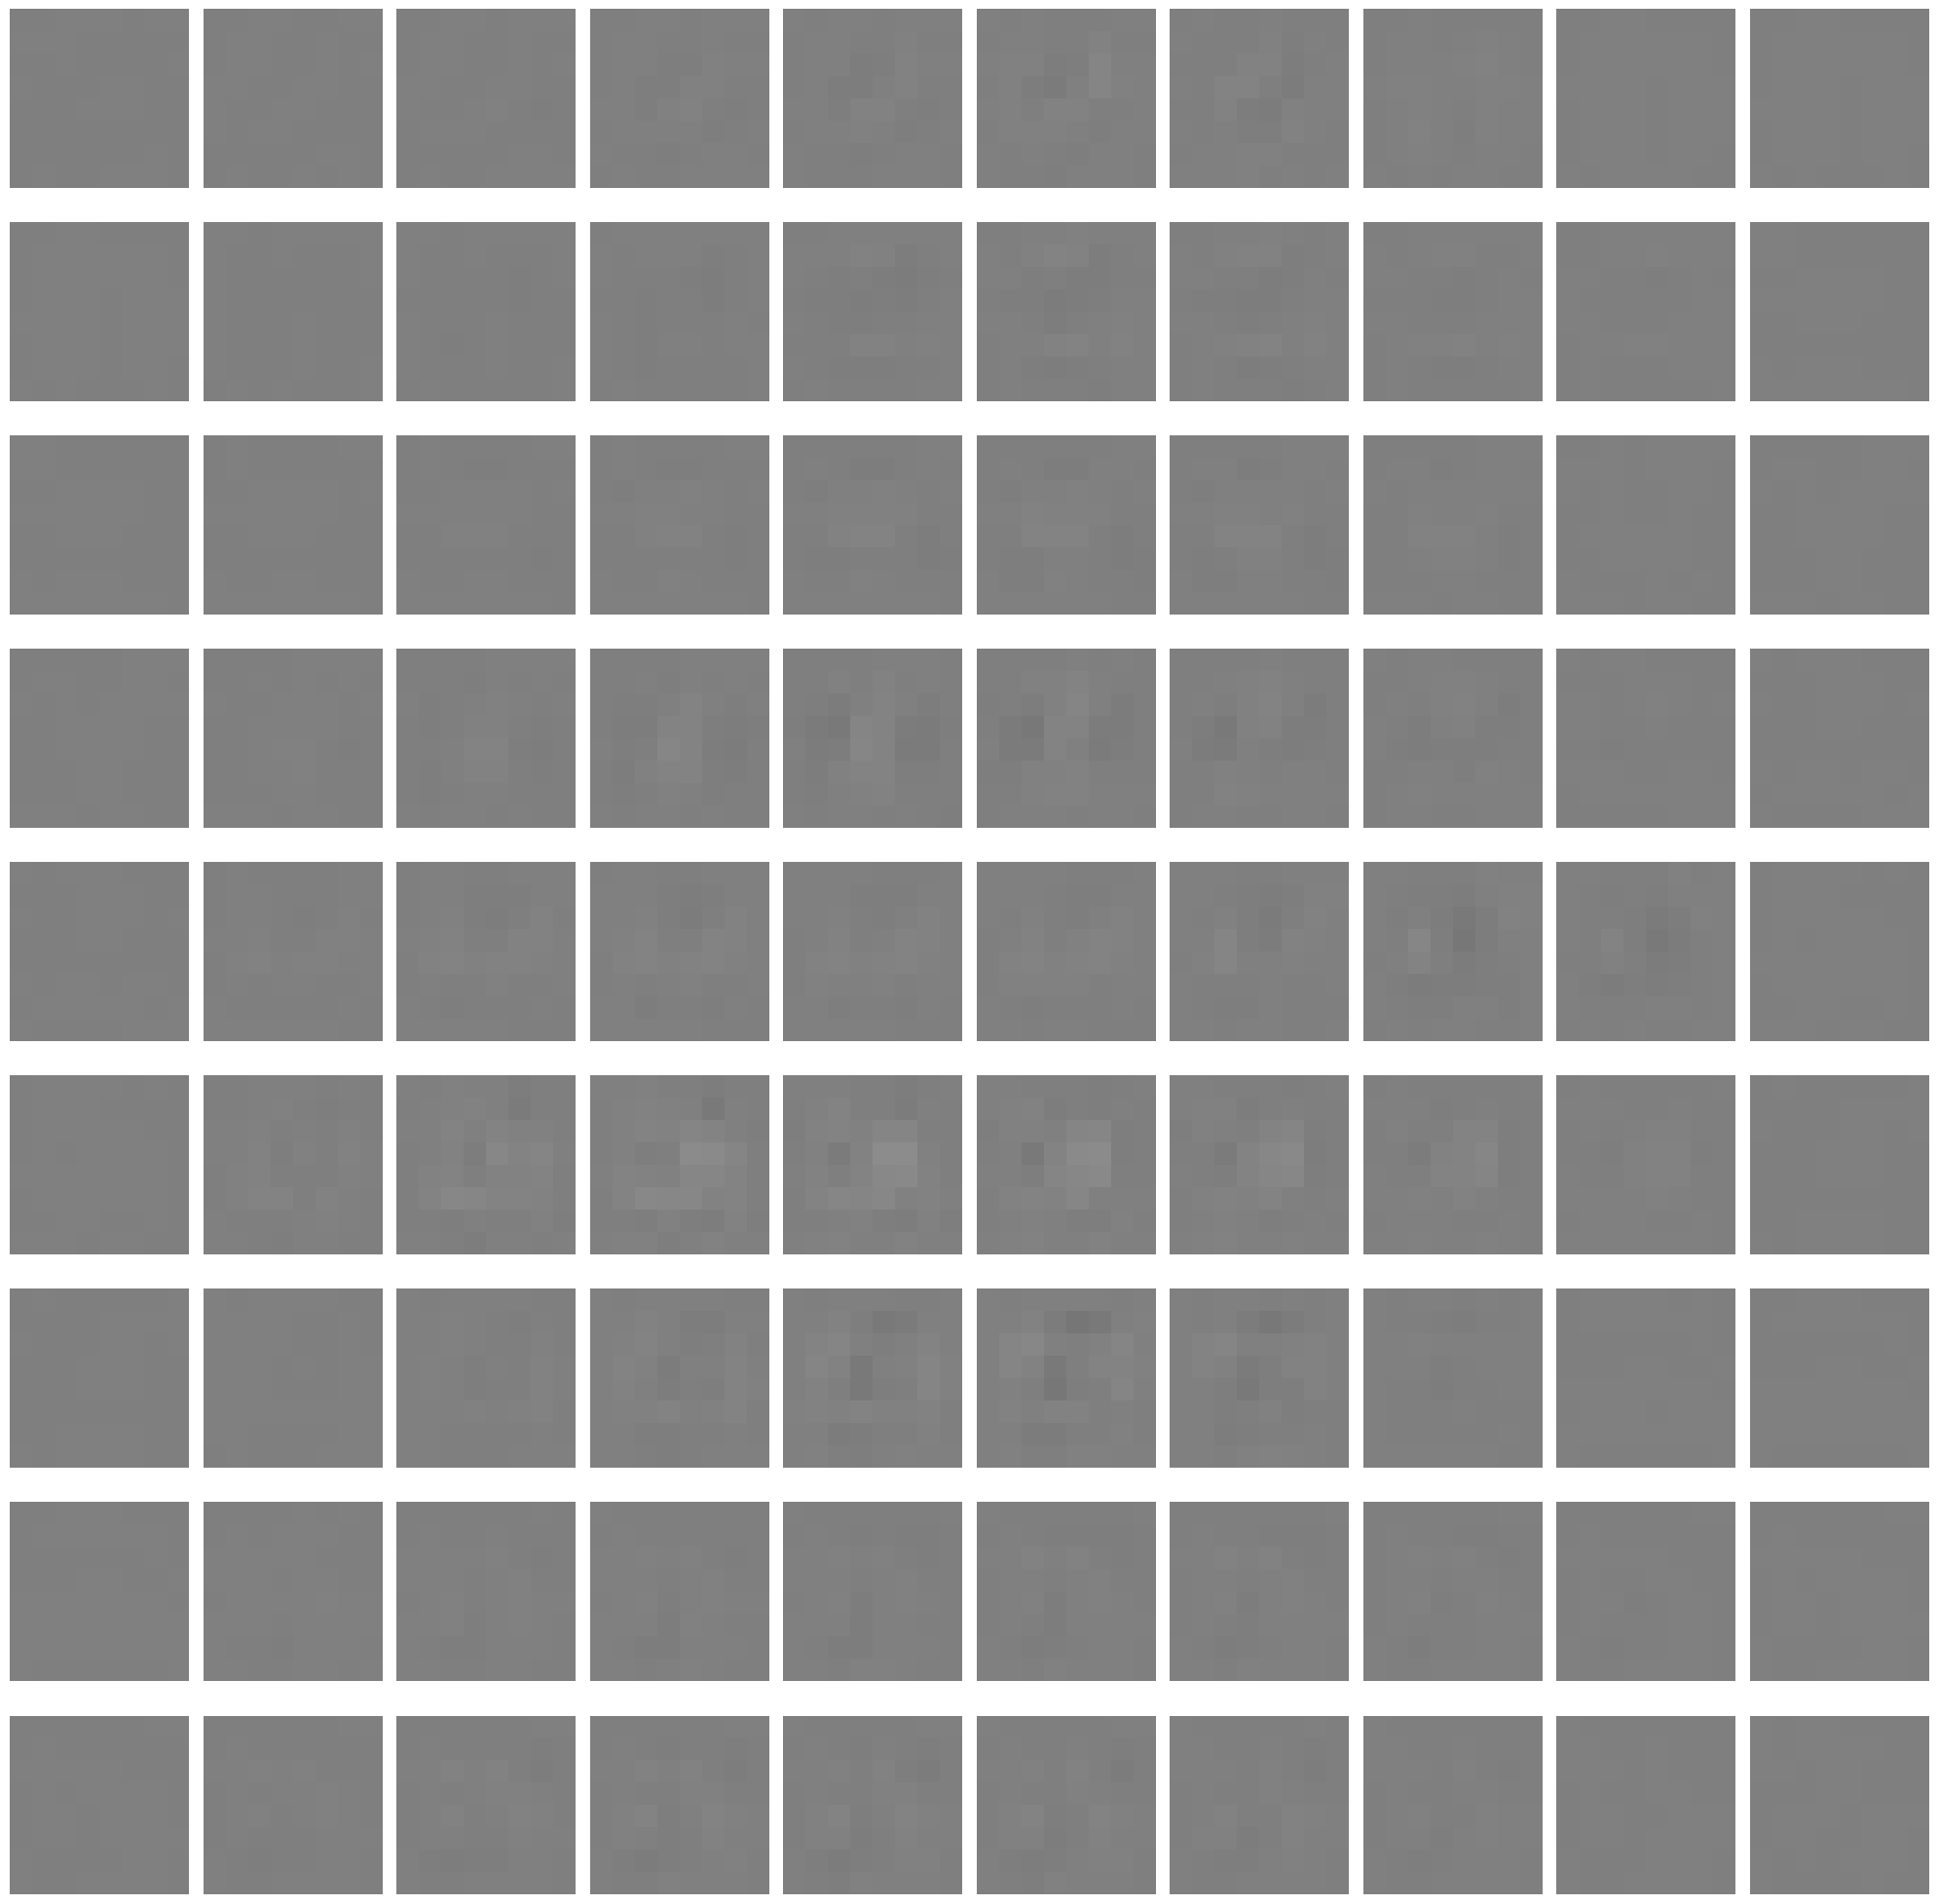

In [ ]:
# compute geodesics between all pairs of points
K = 10
t = torch.linspace(0, 1, steps=K)
with torch.no_grad():
    phi_psi_geodesics = phi_psi_manifold.geodesic(cluster_images[None].to(device), cluster_images[None].to(device), t.to(device)).cpu()

# plot geodesics
# plot cluster images
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K):
        axes[i*K + k].imshow(phi_psi_geodesics[0, i, i+1, k, 0], cmap='gray')
        axes[i*K + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_3_data_geodesics.png"))
plt.show()

# plot difference with interpolations
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K): # have same color scale for all plots
        axes[i*K + k].imshow(phi_psi_geodesics[0, i, i+1, k, 0] - interpolations[i, k, 0], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[i*K + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_3_data_interpolation_difference.png"))
plt.show()

# plot difference with phi_geodesics to see effect of learned flow
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K): # have same color scale for all plots
        axes[i*K + k].imshow(phi_psi_geodesics[0, i, i+1, k, 0] - phi_geodesics[0, i, i+1, k, 0], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[i*K + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_3_data_starflow_difference.png"))
plt.show()

### Stage 4: Learn a StarFlow ###

In [ ]:
starflow_trainer = ProductStarFlowTraining(
    StarDiagonalFlowDistribution(
        size * size, 
        phi.transform, 
        star_gaussian).to(device), 
    lr=phase_4_cfg["learning_rate"],
    )

In [ ]:
# construct train loop
def phase_4_train(trainer, train_loader, save_dir, n_epochs, start_epoch=0, best_loss=float('inf')):
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        for (x, _), _ in tqdm(train_loader):
            x = x.to(device, non_blocking=True)
            loss = trainer.train_step(x)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(train_pair_dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': trainer.starflow.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_loss,
        }
        
        torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [ ]:
# train or load model for phase 4
checkpoint_dir = os.path.join(results_folder, phase_4_cfg["checkpoint_subdir"])
os.makedirs(checkpoint_dir, exist_ok=True)

if phase_4_training:
    start_epoch = 0
    best_loss = float('inf')
    latest_checkpoint = max(
        glob.glob(os.path.join(checkpoint_dir, "epoch_*_model.pth")),
        default=None,
        key=os.path.getctime,
    )

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        starflow_trainer.starflow.load_state_dict(checkpoint["model_state_dict"])
        starflow_trainer.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        best_loss = checkpoint["best_loss"]

    phase_4_train(
        starflow_trainer,
        train_loader,
        save_dir=checkpoint_dir,
        n_epochs=phase_4_cfg["num_epochs"],
        start_epoch=start_epoch,
        best_loss=best_loss,
    )
else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    checkpoint = torch.load(best_model_path, map_location=device)
    starflow_trainer.starflow.load_state_dict(checkpoint["model_state_dict"])

starflow = ProductStarFlowImageDiffeomorphism(in_channels, height, width, starflow_trainer.starflow) # starflow_trainer.diffeo

100%|██████████| 375/375 [00:35<00:00, 10.43it/s]

Epoch 1/1, Loss: 61.489734
Training completed. Best model saved with loss: 61.48973446409709


In [ ]:
starflow = ProductStarFlowImageDiffeomorphism(in_channels, height, width, starflow_trainer.starflow) 

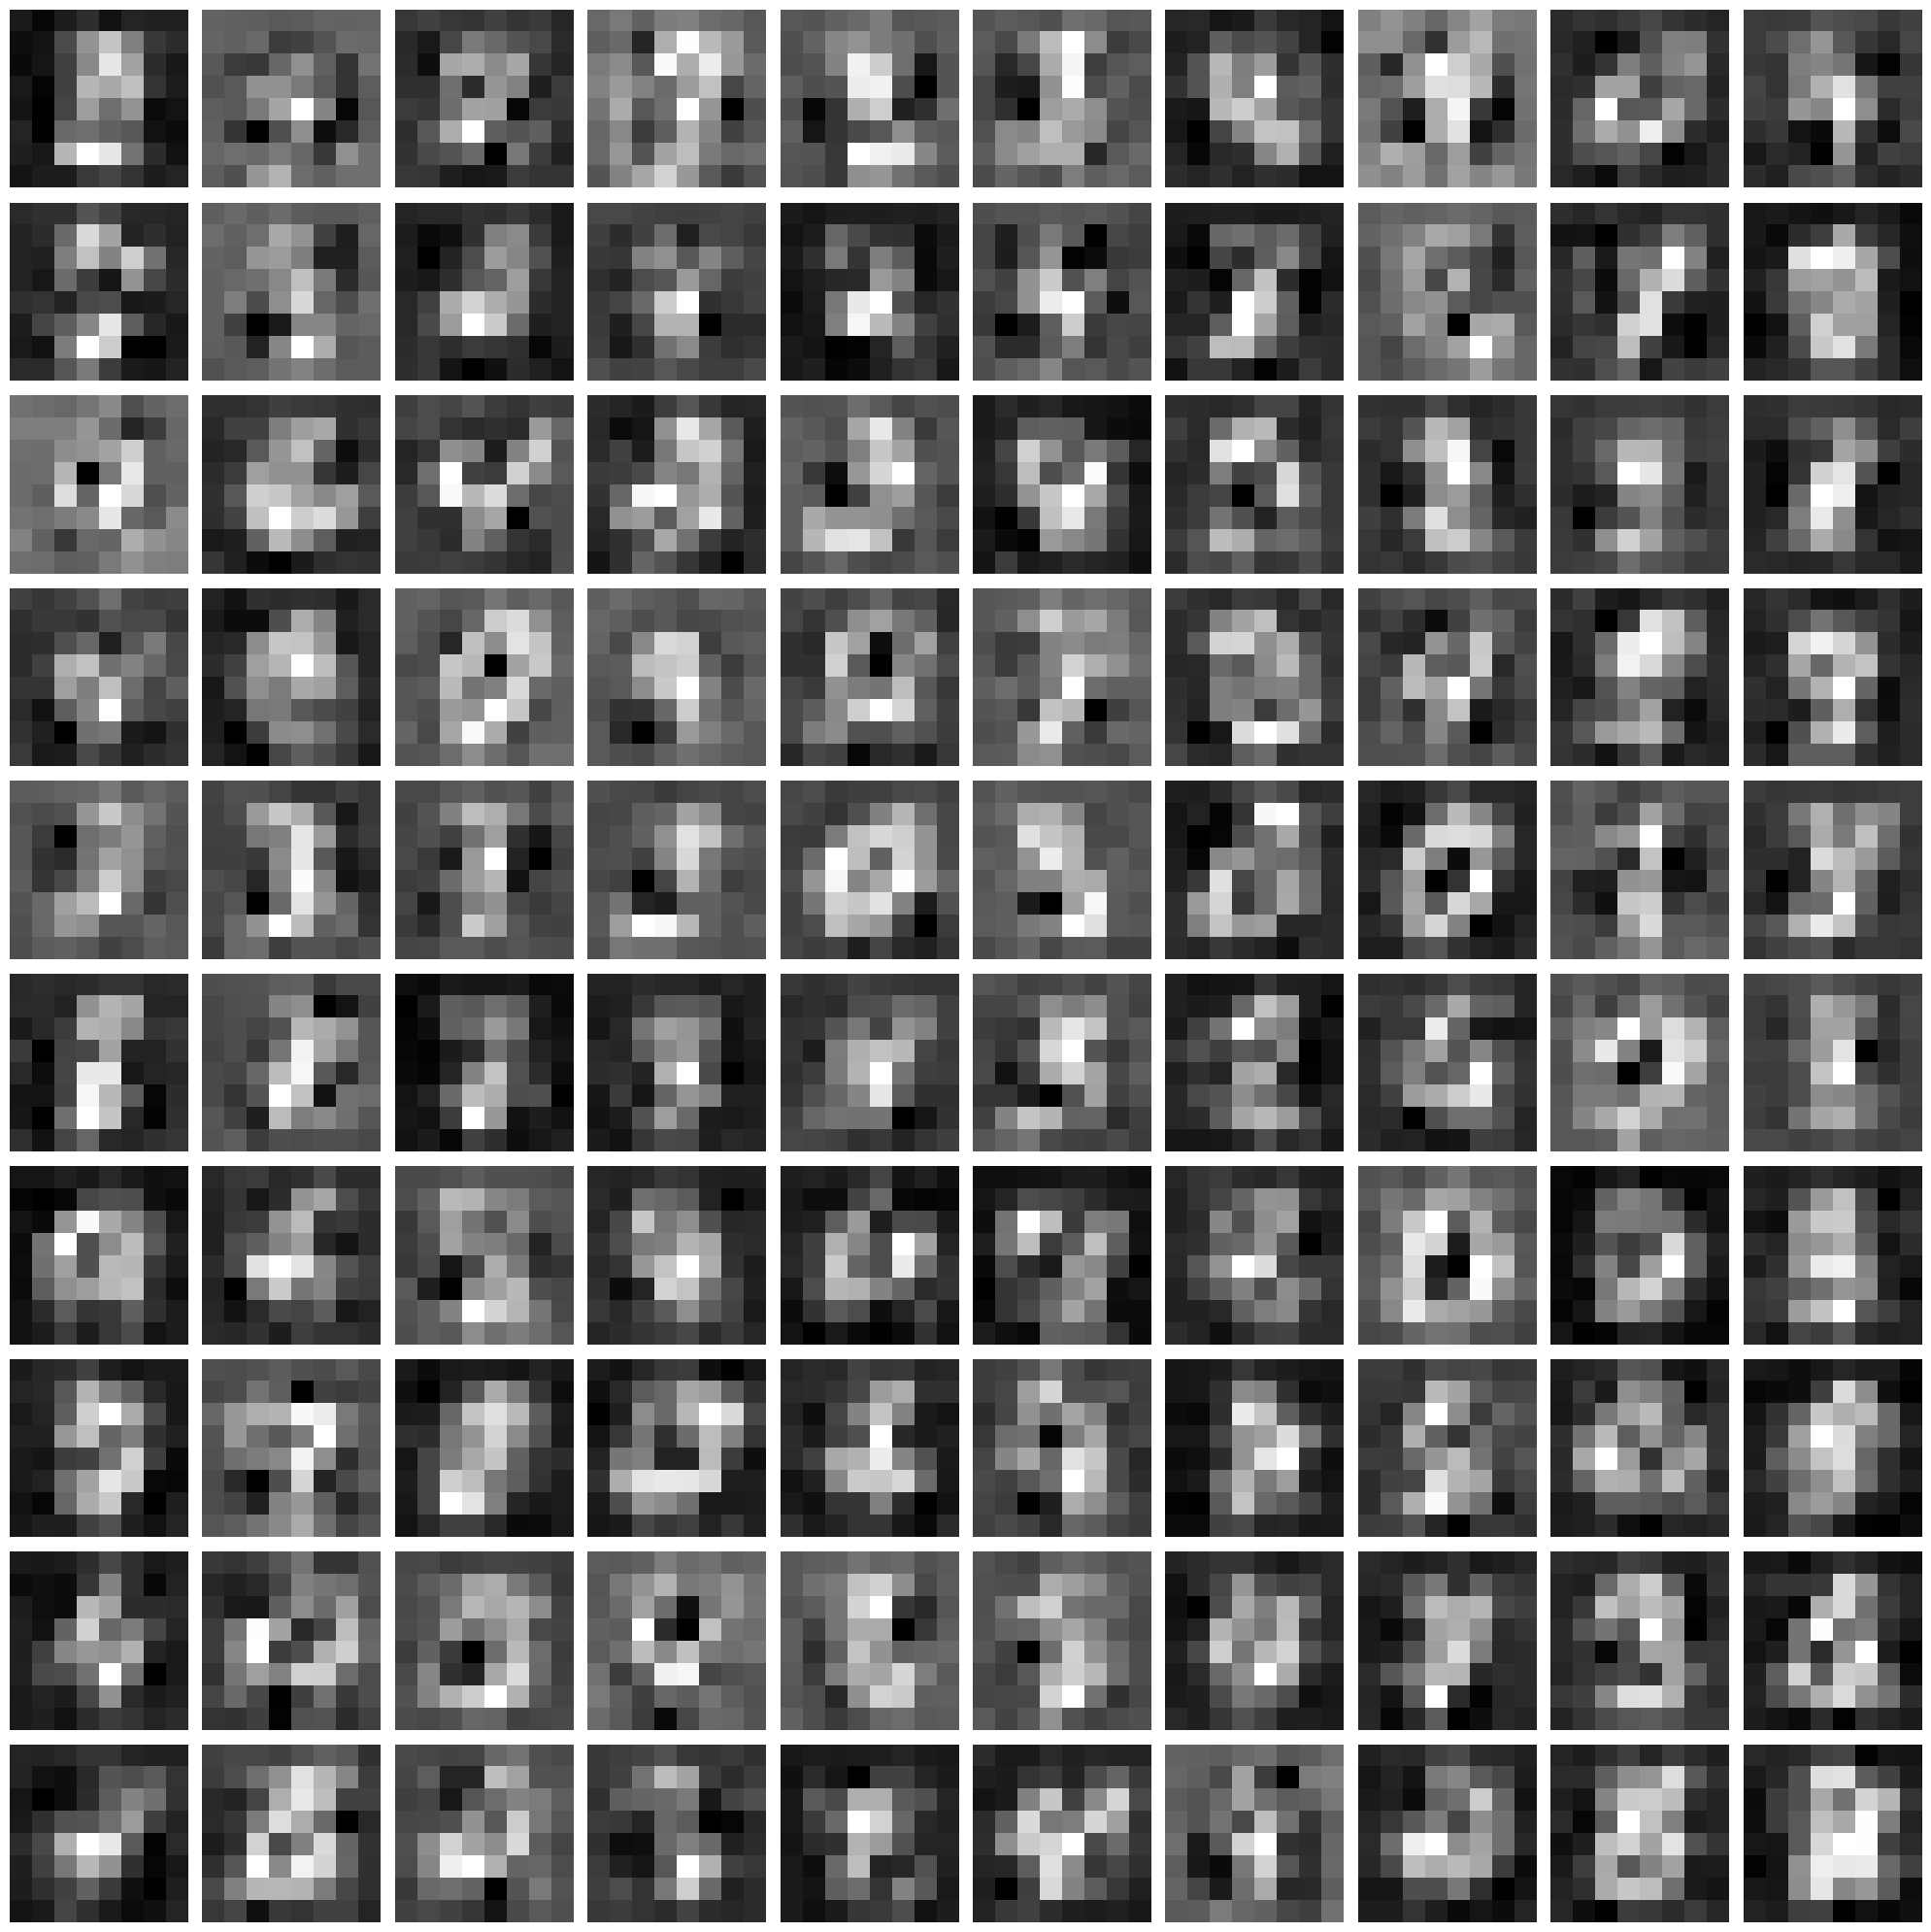

In [ ]:
with torch.no_grad():
    samples = starflow_trainer.starflow.sample(1000).cpu()

# plot samples
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten()
for i in range(100):
    axes[i].imshow(samples[i,0], cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,f"stage_4_samples_post_training.png"))
plt.show()

In [ ]:
# construct manifold from learned flow
starflow_manifold = StandardPullbackImageEuclidean(starflow)
# construct iso_manifold 
# iso_starflow_manifold = l2IsometrizedImageEuclidean(starflow_manifold)

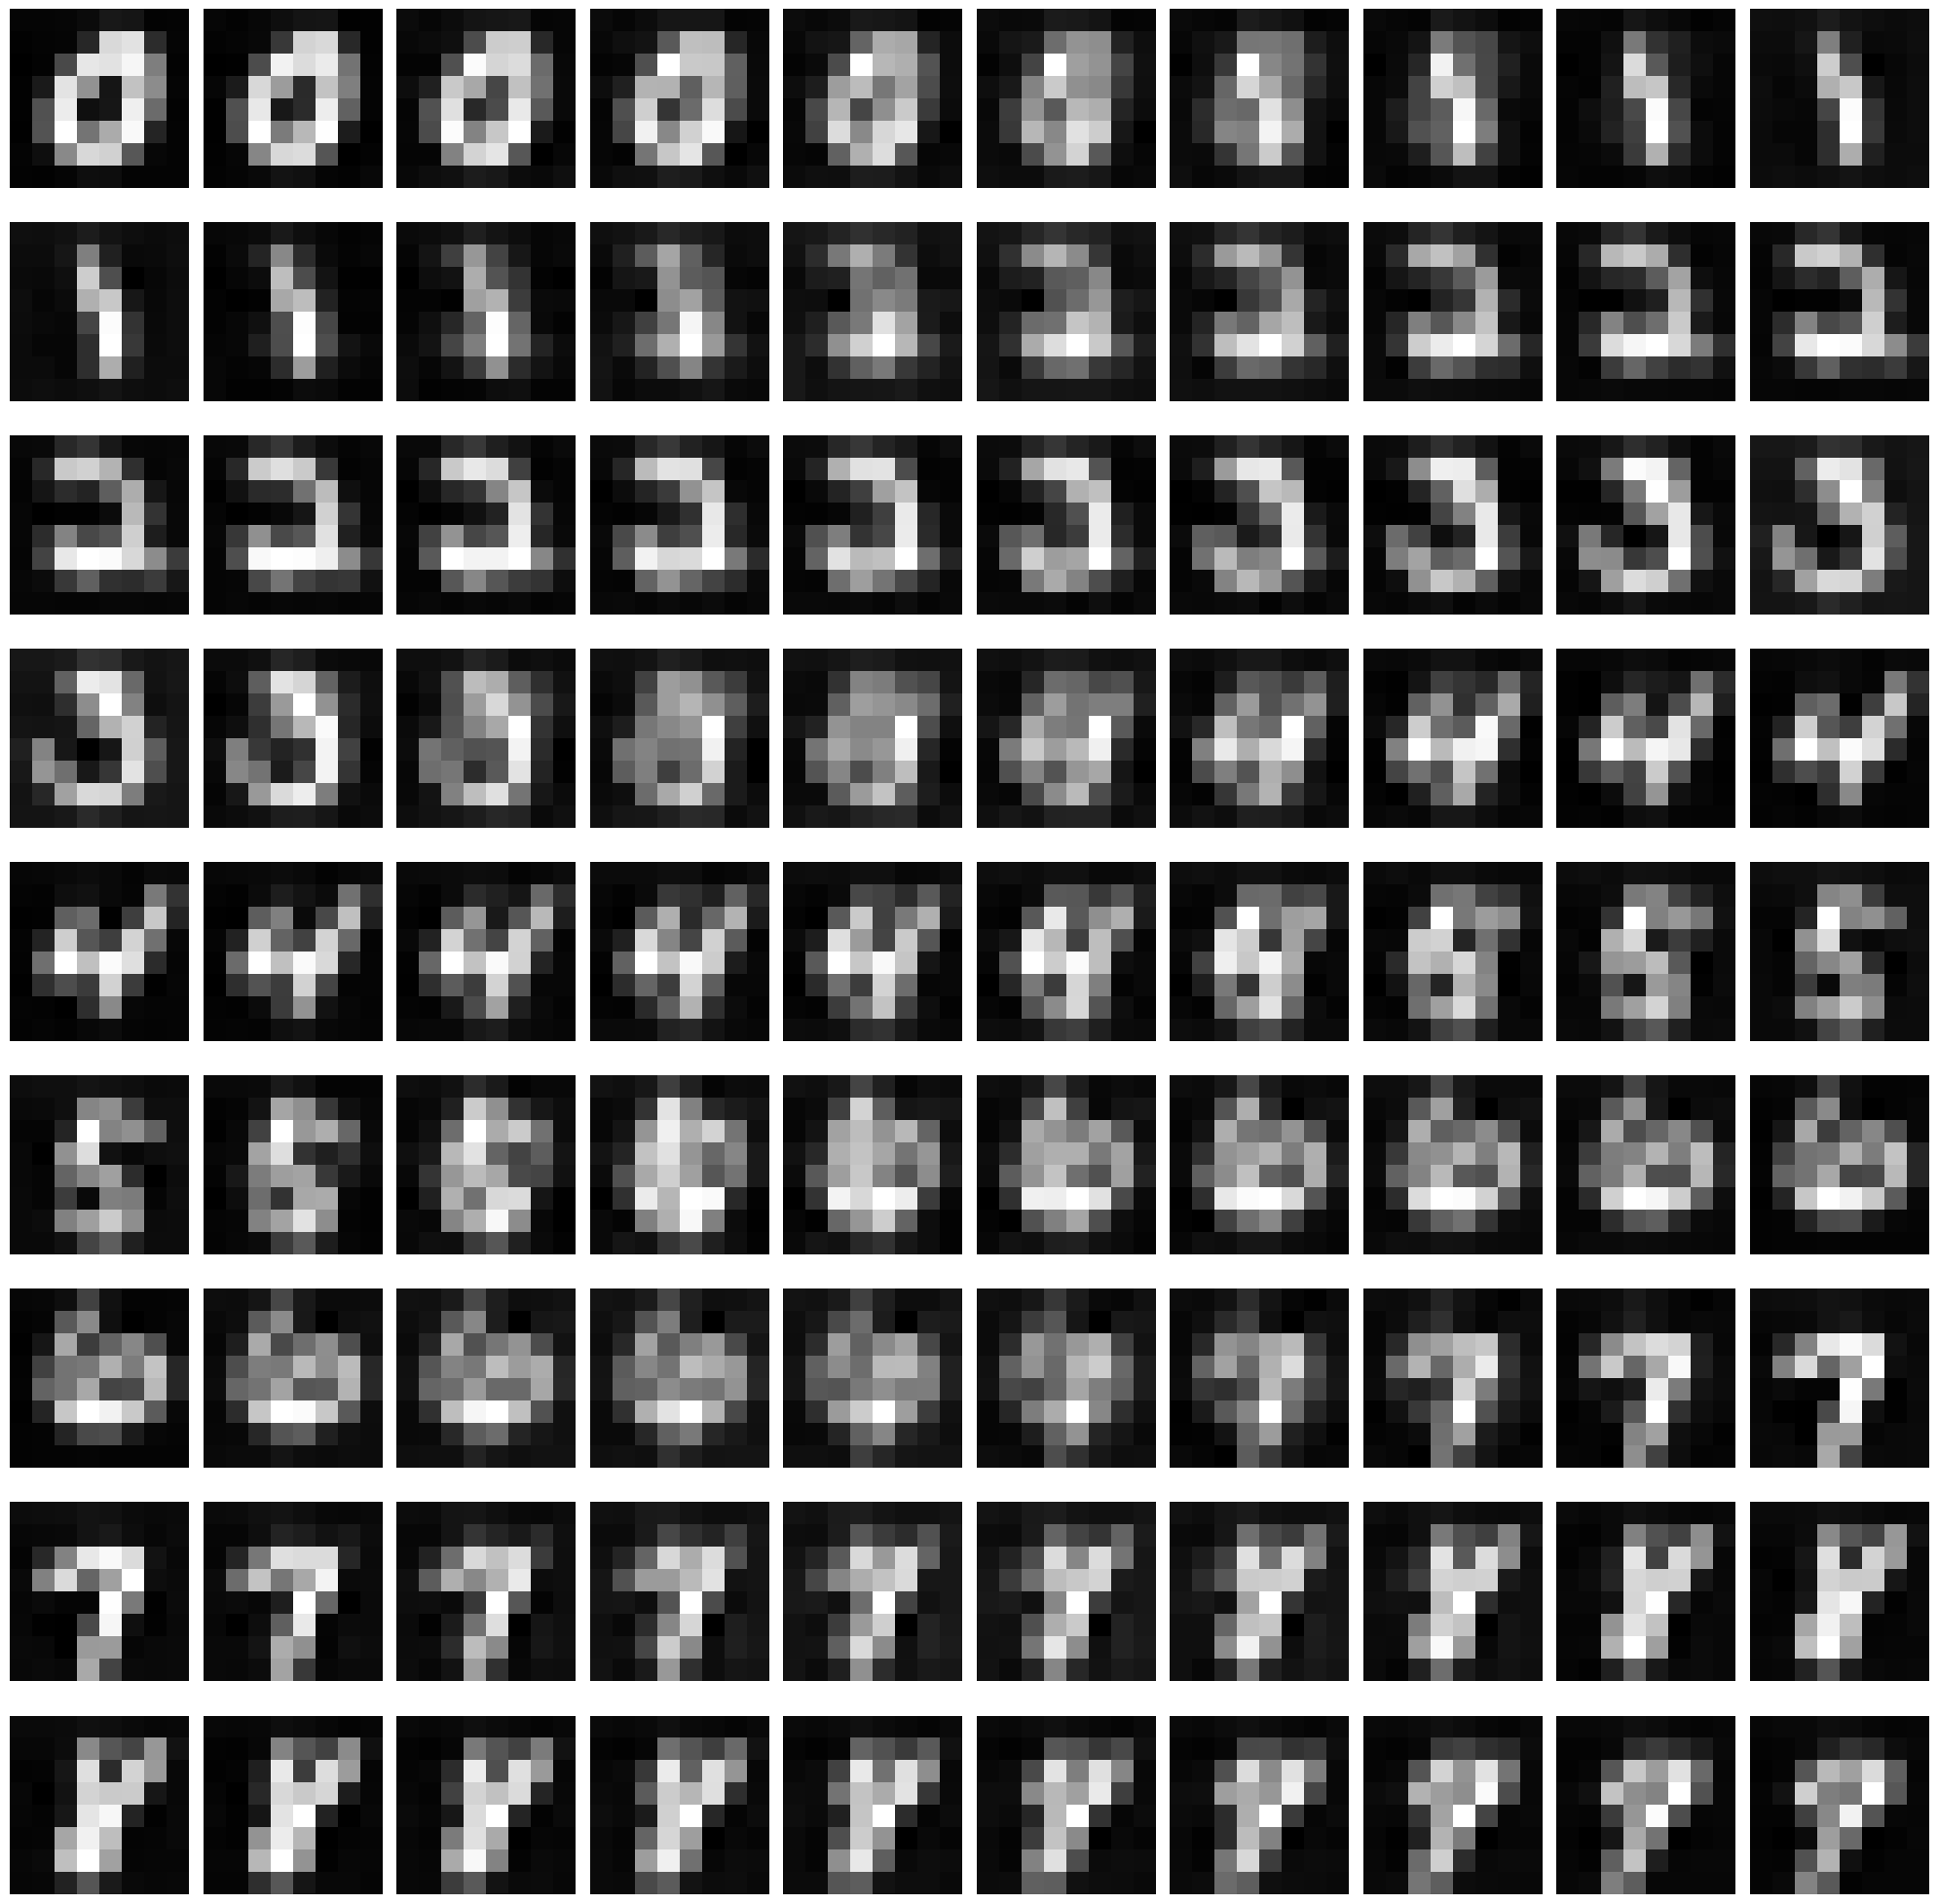

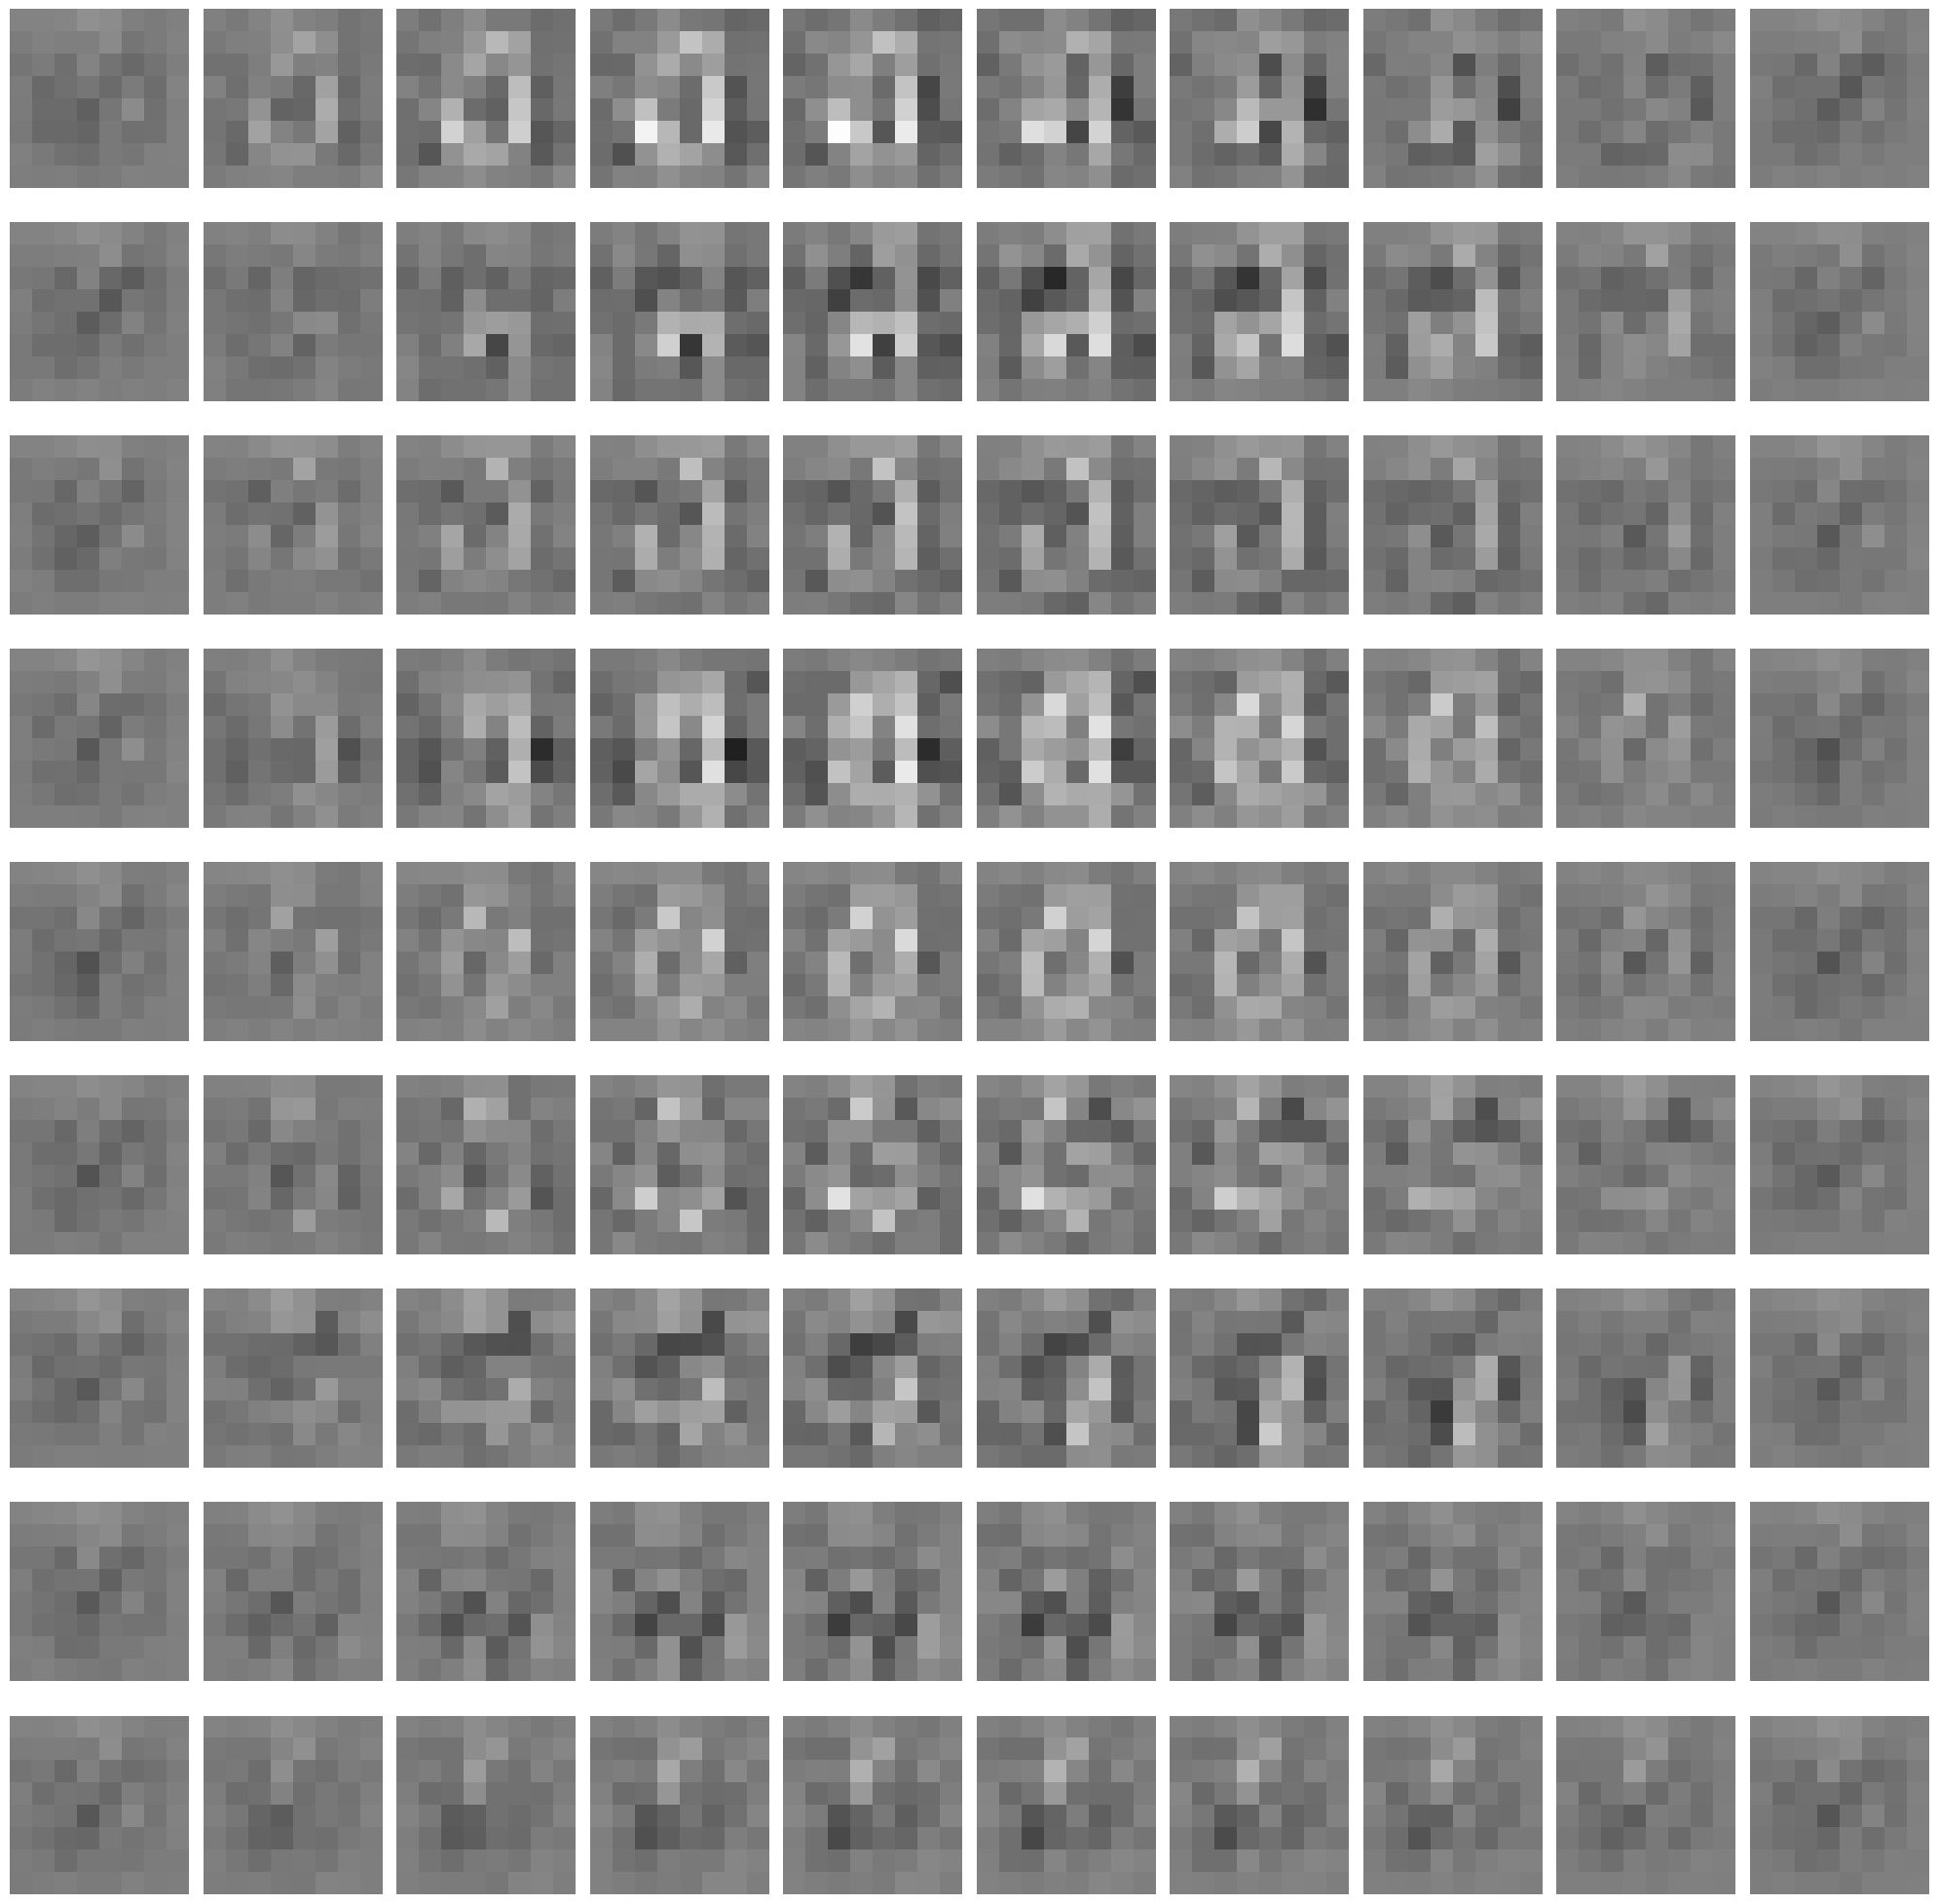

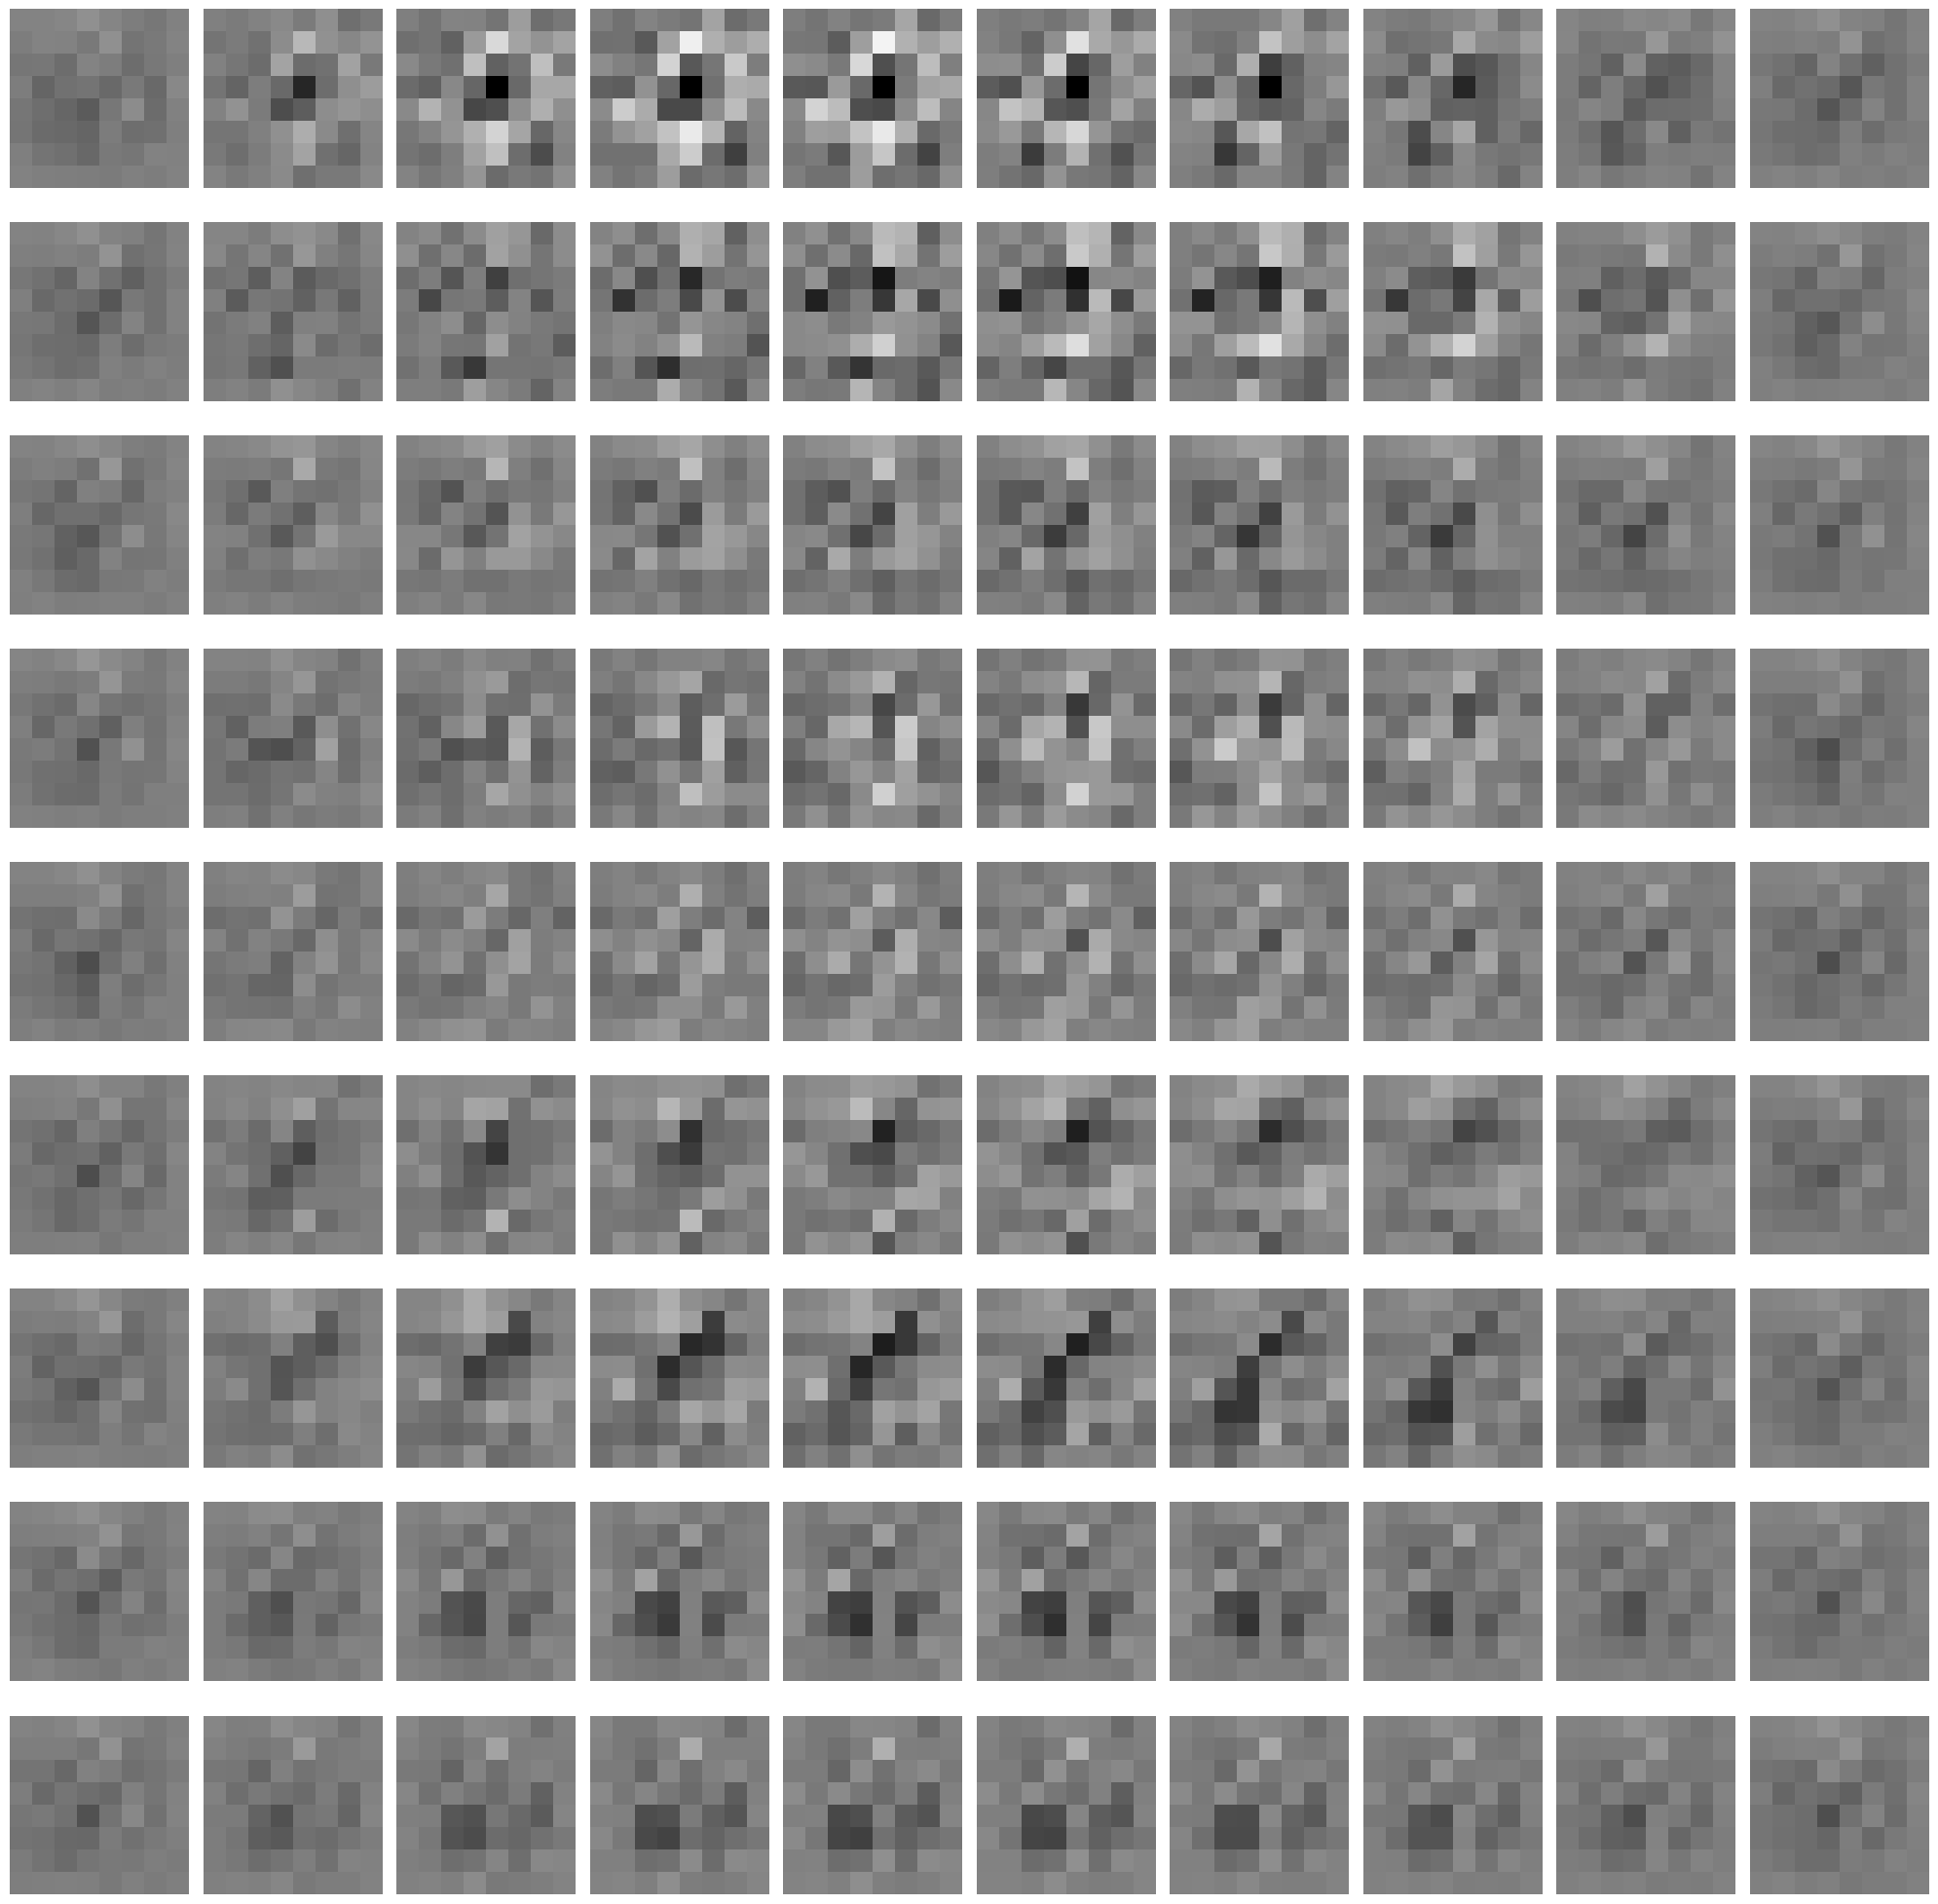

In [ ]:
# compute geodesics between all pairs of points
K = 10
t = torch.linspace(0, 1, steps=K)
with torch.no_grad():
    starflow_geodesics = phi_psi_manifold.geodesic(cluster_images[None].to(device), cluster_images[None].to(device), t.to(device)).cpu()

# plot geodesics
# plot cluster images
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K):
        axes[i*K + k].imshow(starflow_geodesics[0, i, i+1, k, 0], cmap='gray')
        axes[i*K + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_4_data_geodesics.png"))
plt.show()

# plot difference with interpolations
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K): # have same color scale for all plots
        axes[i*K + k].imshow(starflow_geodesics[0, i, i+1, k, 0] - interpolations[i, k, 0], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[i*K + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_4_data_interpolation_difference.png"))
plt.show()

# plot difference with phi_geodesics to see effect of learned flow
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K): # have same color scale for all plots
        axes[i*K + k].imshow(starflow_geodesics[0, i, i+1, k, 0] - phi_psi_geodesics[0, i, i+1, k, 0], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[i*K + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_4_data_starflow_difference.png"))
plt.show()